In [1]:
## mirtud_env (R kernel)
## This notebook plots all figs from the saved data frames

In [1]:
suppressWarnings(library(Seurat))
suppressWarnings(library(ggplot2))
suppressWarnings(library(ggpubr))
suppressWarnings(library(ggrepel))
suppressWarnings(library(dplyr))
suppressWarnings(library(tidyr))
suppressWarnings(library(ComplexHeatmap))
suppressWarnings(library(gridExtra))
suppressWarnings(library(circlize))
suppressWarnings(library(ggtree))
suppressWarnings(library(cowplot))
suppressWarnings(library(aplot))
suppressWarnings(library(patchwork))
suppressWarnings(library(stringr))
suppressWarnings(library(igraph))
suppressWarnings(library(rstatix))


## add libPath for Volcano plot package
.libPaths(c('/home/ssobti/projects/mir_tud/mirtud_conda_extras', '/home/ssobti/projects/mir_tud/packages/gsea_R_pkgs'))
suppressWarnings(library(EnhancedVolcano))
suppressWarnings(library(ggbreak))
suppressWarnings(library(ggforce))

major_text_size = 8
minor_text_size = 6.5
lnwidth = 0.694
path = '/home/ssobti/projects/mir_tud/'

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effo

In [3]:
## function for getting rid of messy suffixes in tRF names
condense_tRF_names = function(char_vector){
  out = vector('character', length(char_vector))
  
  for (i in 1:length(char_vector)){
    strg = char_vector[i]
    out_waiting = ''
    ## ex: 'tRF_Asp_GTC_2' -> 'tRF_Asp_GTC'
    if (stringr::str_count(strg, '_') > 2 & !startsWith(strg, 'random') & stringr::str_count(strg, '\\.') == 0){
      out_waiting = paste(stringr::str_split(unique(strg), pattern = '_', n = 4)[[1]][1:3], collapse = '-')
      out[i] = ifelse(nchar(out_waiting) > 1, out_waiting, paste('NOT', strg, sep = '!'))
    }
    else if (stringr::str_count(strg, '-') == 0 & !startsWith(strg, 'random') & stringr::str_count(strg, '\\.') == 0){
      out_waiting = paste(stringr::str_split(unique(strg), pattern = '-', n = 4)[[1]][1:3], collapse = '-')
      out[i] = ifelse(nchar(out_waiting) > 1, out_waiting, paste('NOT', strg, sep = '!'))
    }
    ## ex: 'tRNA-Ala-TGC-2-1.rh' -> 'tRNA-Ala-TGC'
    else if (stringr::str_count(strg, '-') > 2 & !startsWith(strg, 'random') & stringr::str_count(strg, '\\.') > 0){
      out_waiting = paste(stringr::str_split(unique(strg), pattern = '-', n = 4)[[1]][1:3], collapse = '-')
      out[i] = ifelse(nchar(out_waiting) > 1, out_waiting, paste('NOT', strg, sep = '!'))
    }
    else if (stringr::str_count(strg, '_') > 2 & !startsWith(strg, 'random') & stringr::str_count(strg, '\\.') > 0){
      out_waiting = paste(stringr::str_split(unique(strg), pattern = '_', n = 4)[[1]][1:3], collapse = '-')
      out[i] = ifelse(nchar(out_waiting) > 1, out_waiting, paste('NOT', strg, sep = '!'))
    }
    else if (stringr::str_count(strg, '_') == 1 & !startsWith(strg, 'random') & stringr::str_count(strg, '\\.') == 0){
    out_waiting = paste(stringr::str_split(unique(strg), pattern = '_')[[1]][1], collapse = '-')
    out[i] = ifelse(nchar(out_waiting) > 1, out_waiting, paste('NOT', strg, sep = '!'))
    }
    else if (stringr::str_count(strg, '_') == 1 & startsWith(strg, 'random') & stringr::str_count(strg, '\\.') == 0 & str_sub(strg, -2, -2) == '_'){
      out_waiting = stringr::str_split(strg, pattern = '_')[[1]][1]
      out[i] = ifelse(nchar(out_waiting) > 1, out_waiting, paste('NOT', strg, sep = '!'))
    }
    else if (stringr::str_count(strg, '_') == 1 & startsWith(strg, 'random') & stringr::str_count(strg, '\\.') == 0 & str_sub(strg, 7, 7) == '_'){
      out_waiting = stringr::str_split(strg, pattern = '_')[[1]][2]
      out[i] = ifelse(nchar(out_waiting) > 1, out_waiting, paste('NOT', strg, sep = '!'))
    }
    ## ex: 
    else if (stringr::str_count(strg, '_') > 3 & startsWith(strg, 'random') & stringr::str_count(strg, '\\.') == 0){
      out_waiting = paste(stringr::str_split(unique(strg), pattern = '_', n = 4)[[1]][1:4], collapse = '-')
      out[i] = ifelse(nchar(out_waiting) > 1, out_waiting, paste('NOT', strg, sep = '!'))
    }
    else if (stringr::str_count(strg, '-') > 2 & startsWith(strg, 'random') & stringr::str_count(strg, '\\.') > 0){
      out_waiting = paste(stringr::str_split(unique(strg), pattern = '-', n = 4)[[1]][1:3], collapse = '-')
      out[i] = ifelse(nchar(out_waiting) > 1, out_waiting, paste('NOT', strg, sep = '!'))
    }
    #ex: 'random_tRF_Gly_GCC.CCC_4' -> 'random_tRF_Gly_GCC.CCC'
    else if (stringr::str_count(strg, '_') > 3 & startsWith(strg, 'random') & stringr::str_count(strg, '\\.') > 0){
      out_waiting = paste(stringr::str_split(unique(strg), pattern = '_', n = 5)[[1]][1:4], collapse = '-')
      out[i] = ifelse(nchar(out_waiting) > 1, out_waiting, paste('NOT', strg, sep = '!'))
    }
    else {
      out[i] = strg
    }
  }
  out = ifelse(stringi::stri_sub(out,-2,-2) == '_', stringi::stri_sub(out,1,-3), out)
  return(out)
}



## Fig 1 miRNA and QC ##

### Target mRNA expression ###

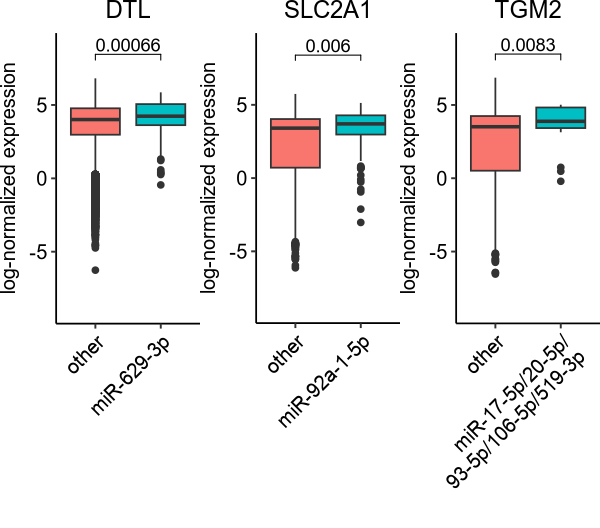

In [85]:
wfix = 5
hfix = 4.4
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

DTL = read.csv('/home/ssobti/projects/mir_tud/fig_output/data/fig1/DTL.txt', sep = '\t', header = T, row.names = 1)
SLC2A1 = read.csv('/home/ssobti/projects/mir_tud/fig_output/data/fig1/SLC2A1.txt', sep = '\t', header = T, row.names = 1)
TGM2 = read.csv('/home/ssobti/projects/mir_tud/fig_output/data/fig1/TGM2.txt', sep = '\t', header = T, row.names = 1)
TGM2$perturbation[TGM2$perturbation == 'miR-17-5p/20-5p/93-5p/106-5p/519-3p'] = 'miR-17-5p/20-5p/\n93-5p/106-5p/519-3p'

DTL$perturbation = factor(DTL$perturbation, levels = c('other', 'miR-629-3p'))
SLC2A1$perturbation = factor(SLC2A1$perturbation, levels = c('other', 'miR-92a-1-5p'))
TGM2$perturbation = factor(TGM2$perturbation, levels = c('other', 'miR-17-5p/20-5p/\n93-5p/106-5p/519-3p'))

comparisons = list(c('other', 'miR-629-3p'))
DTL_plot = DTL %>% ggplot(aes(x = perturbation, y = norm_expression, fill = perturbation)) + xlab('') + geom_boxplot(show.legend = FALSE) + 
ggpubr::theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + stat_compare_means(comparisons = comparisons, method = 't.test', label.y = 7.8) +
scale_fill_discrete() + ylab('log-normalized expression') + ylim(c(-9, 9)) + ggtitle('DTL') +
theme(plot.margin = unit(c(0, 0, 0.64, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

comparisons = list(c('other', 'miR-92a-1-5p'))
SLC2A1_plot = SLC2A1 %>% ggplot(aes(x = perturbation, y = norm_expression, fill = perturbation)) + xlab('') + geom_boxplot(show.legend = FALSE) + 
ggpubr::theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + stat_compare_means(comparisons = comparisons, method = 't.test', label.y = 7.8) +
scale_fill_discrete() + ylab('log-normalized expression') + ylim(c(-9, 9)) + ggtitle('SLC2A1') +
theme(plot.margin = unit(c(0, 0, 0.51, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

comparisons = list(c('other', 'miR-17-5p/20-5p/\n93-5p/106-5p/519-3p'))
TGM2_plot = TGM2 %>% ggplot(aes(x = perturbation, y = norm_expression, fill = perturbation)) + xlab('') + geom_boxplot(show.legend = FALSE) + 
ggpubr::theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + stat_compare_means(comparisons = comparisons, method = 't.test', label.y = 7.8) +
scale_fill_discrete() + ylab('log-normalized expression') + ylim(c(-9, 9)) + ggtitle('TGM2') +
theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggarrange(DTL_plot, SLC2A1_plot, TGM2_plot, ncol = 3, nrow = 1)
ggsave(paste0(path, 'fig_output/data/fig1/miR_target_mRNA_expression.pdf'), width = wfix, height = hfix)

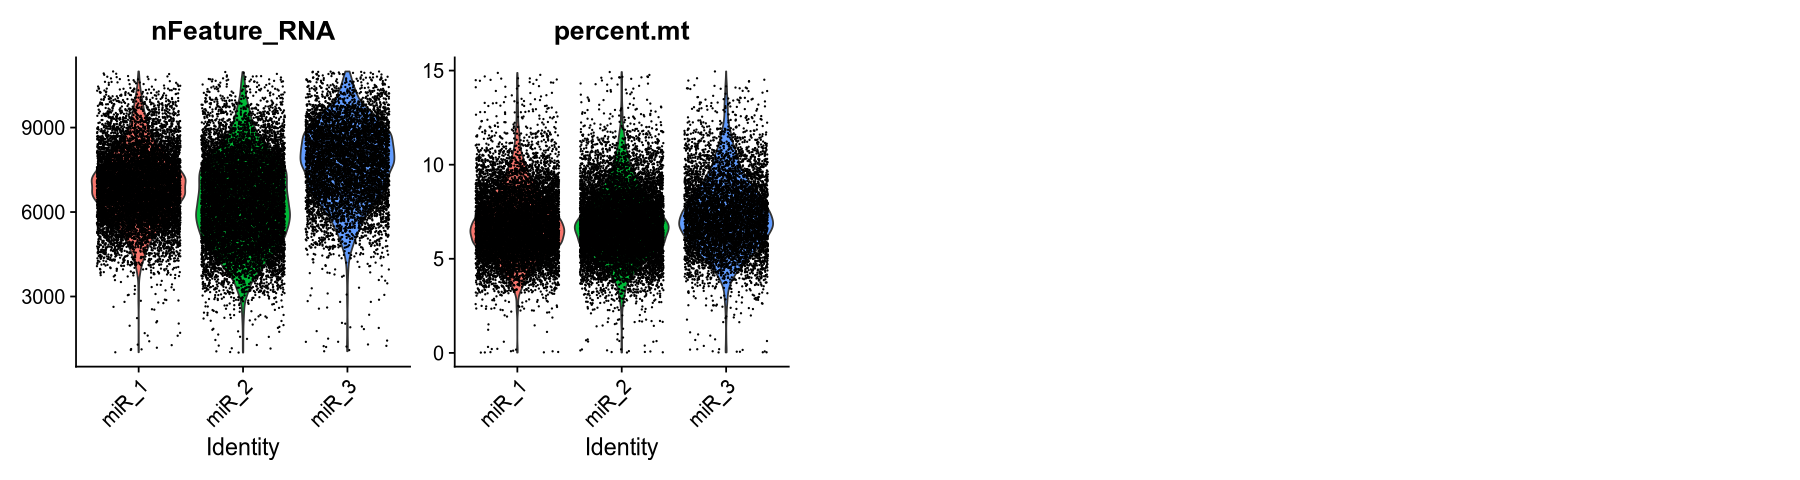

In [ ]:
wfix = 15
hfix = 4
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

suppressWarnings(suppressMessages(library(Seurat)))
adata.miR = readRDS('/home/ssobti/projects/mir_tud/010523_filtered_data/miR_normalized_integrated_seurat.rds')
miR_cell_quality = adata.miR@meta.data[,c('sample', 'nFeature_RNA', 'percent.mt')]
write.csv(miR_cell_quality, paste0(path, 'fig_output/data/fig1/miR_cell_quality.csv'))
feats <- c("nFeature_RNA", "percent.mt")
VlnPlot(adata.miR, group.by = "sample", features = feats, pt.size = 0.01, ncol = 5) + theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))
ggsave(paste0(path, 'fig_output/data/fig1/miR_cell_quality.pdf'), width = wfix, height = hfix)

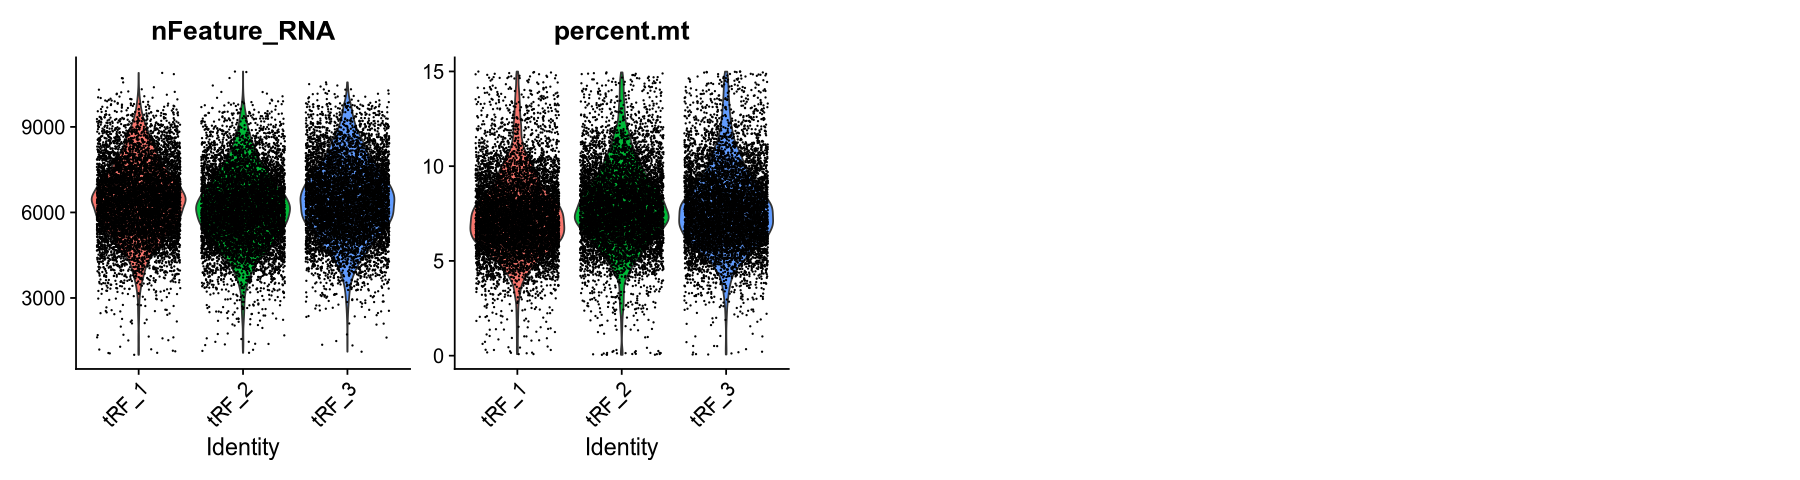

In [12]:
wfix = 15
hfix = 4
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

suppressWarnings(suppressMessages(library(Seurat)))
adata.tRF = readRDS('/home/ssobti/projects/mir_tud/010523_filtered_data/tRF_normalized_integrated_seurat.rds')
tRF_cell_quality = adata.tRF@meta.data[,c('sample', 'nFeature_RNA', 'percent.mt')]
write.csv(tRF_cell_quality, paste0(path, 'fig_output/data/fig1/tRF_cell_quality.csv'))
feats <- c("nFeature_RNA", "percent.mt")
VlnPlot(adata.tRF, group.by = "sample", features = feats, pt.size = 0.01, ncol = 5) + theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))
ggsave(paste0(path, 'fig_output/data/fig1/tRF_cell_quality.pdf'), width = wfix, height = hfix)

In [10]:
adata.miR = readRDS('/home/ssobti/projects/mir_tud/010523_filtered_data/miR_normalized_integrated_seurat.rds')
meta = adata.miR@meta.data
print(paste('Total cells:', dim(meta)[1]))
print(paste('Total perturbations', length(unique(meta$miR.family))))
print(paste('Number of miR families perturbed:', sum(stringr::str_count(unique(meta$miR.family), "/") > 0)))
print(paste('Number of unique miR perturbed:', length(unique(meta$miR.family)) - 1 - sum(stringr::str_count(unique(meta$miR.family), "/") > 0)))
print(paste('Number of cells per perturbation (median):', median(table(meta$miR.family))))
print(paste('Number of genes per cell (median):', median(meta$nFeature_RNA)))

[1] "Total cells: 29348"
[1] "Total perturbations 336"
[1] "Number of miR families perturbed: 58"
[1] "Number of unique miR perturbed: 277"
[1] "Number of cells per perturbation (median): 74"
[1] "Number of genes per cell (median): 6919"


In [2]:
adata.tRF = readRDS('/home/ssobti/projects/mir_tud/010523_filtered_data/tRF_normalized_integrated_seurat.rds')
meta = adata.tRF@meta.data
meta$guide[stringr::str_sub(meta$guide, 1, 3) == 'TuD'] <- 'TuD_NC'
print(paste('Total cells:', dim(meta)[1]))
print(paste('Total perturbations', length(unique(meta$guide))))
print(paste('Number of tRF clusters perturbed:', sum(stringr::str_count(unique(meta$guide), "_") > 2)))
print(paste('Number of unique tRFs perturbed:', length(unique(meta$guide)) - 1 - sum(stringr::str_count(unique(meta$guide), "_") > 2)))
print(paste('Number of cells per perturbation (median):', median(table(meta$guide))))
print(paste('Number of genes per cell (median):', median(meta$nFeature_RNA)))

[1] "Total cells: 23540"
[1] "Total perturbations 196"
[1] "Number of tRF clusters perturbed: 62"
[1] "Number of unique tRFs perturbed: 133"
[1] "Number of cells per perturbation (median): 43"
[1] "Number of genes per cell (median): 6308.5"


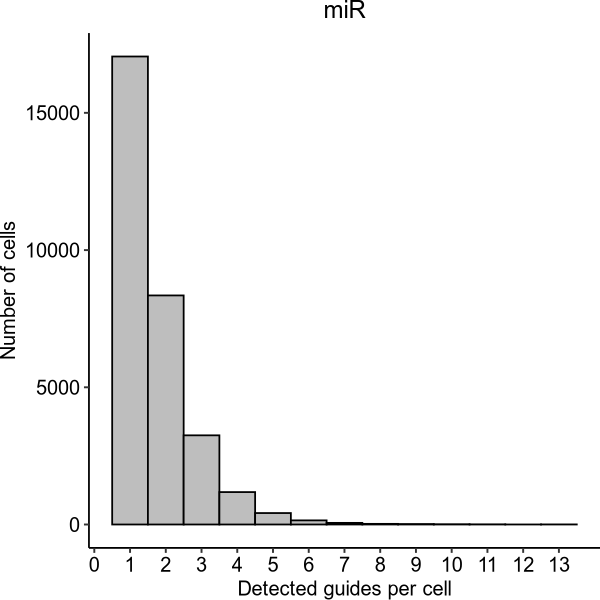

In [30]:
wfix = 5
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

guides_per_cell_miR = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig1/guides_per_cell_miR.rds')
ggplot(guides_per_cell_miR, aes(x = counts)) + geom_histogram(binwidth = 1, color="black", fill="grey") + theme_pubr() + 
scale_x_continuous(breaks = seq(0, max(guides_per_cell_miR$counts), by = 1)) + ggtitle('miR') + xlab('Detected guides per cell') + ylab('Number of cells') +
theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig1/miR_guides_per_cell.pdf'), width = wfix, height = hfix)

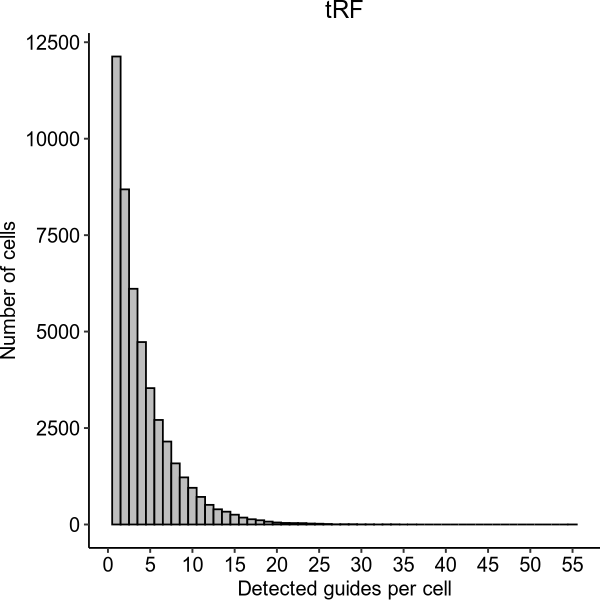

In [31]:
wfix = 5
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

guides_per_cell_tRF = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig1/guides_per_cell_tRF.rds')
ggplot(guides_per_cell_tRF, aes(x = counts)) + geom_histogram(binwidth = 1, color="black", fill="grey") + theme_pubr() + 
scale_x_continuous(breaks = seq(0, max(guides_per_cell_tRF$counts), by = 5)) + ggtitle('tRF') + xlab('Detected guides per cell') + ylab('Number of cells') +
theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig1/tRFguides_per_cell.pdf'), width = wfix, height = hfix)

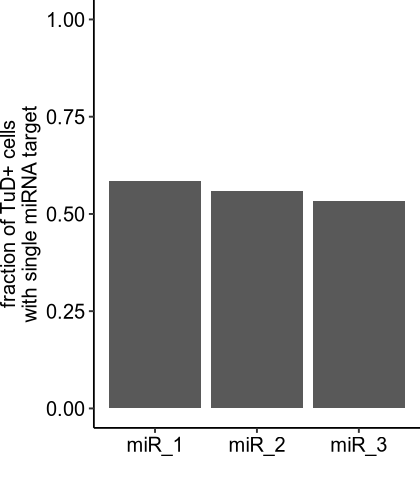

In [5]:
wfix = 3.5
hfix = 4
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

ratio_df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig1/miR_tud_positive_ratio_df.rds')
ratio_df %>% ggplot(aes(x = well, y = ratio)) + geom_bar(stat="identity") + theme_pubr() + ylim(c(0, 1)) + xlab('') + ylab('fraction of TuD+ cells\nwith single miRNA target') +
theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))
ggsave(paste0(path, 'fig_output/data/fig1/miR_tud_positive_fraction.pdf'), width = wfix, height = hfix)

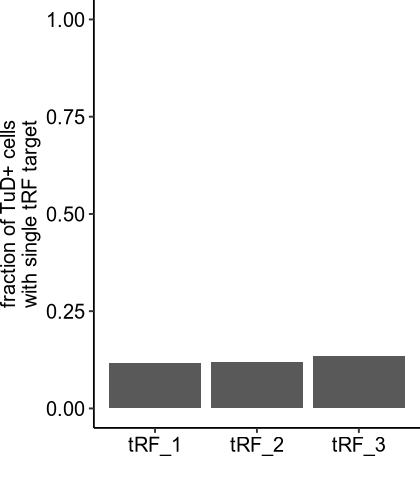

In [7]:
wfix = 3.5
hfix = 4
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

ratio_df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig1/tRF_tud_positive_ratio_df.rds')
ratio_df %>% ggplot(aes(x = well, y = ratio)) + geom_bar(stat="identity") + theme_pubr() + ylim(c(0, 1)) + xlab('') + ylab('fraction of TuD+ cells\nwith single tRF target') +
theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))
ggsave(paste0(path, 'fig_output/data/fig1/tRF_tud_positive_fraction.pdf'), width = wfix, height = hfix)

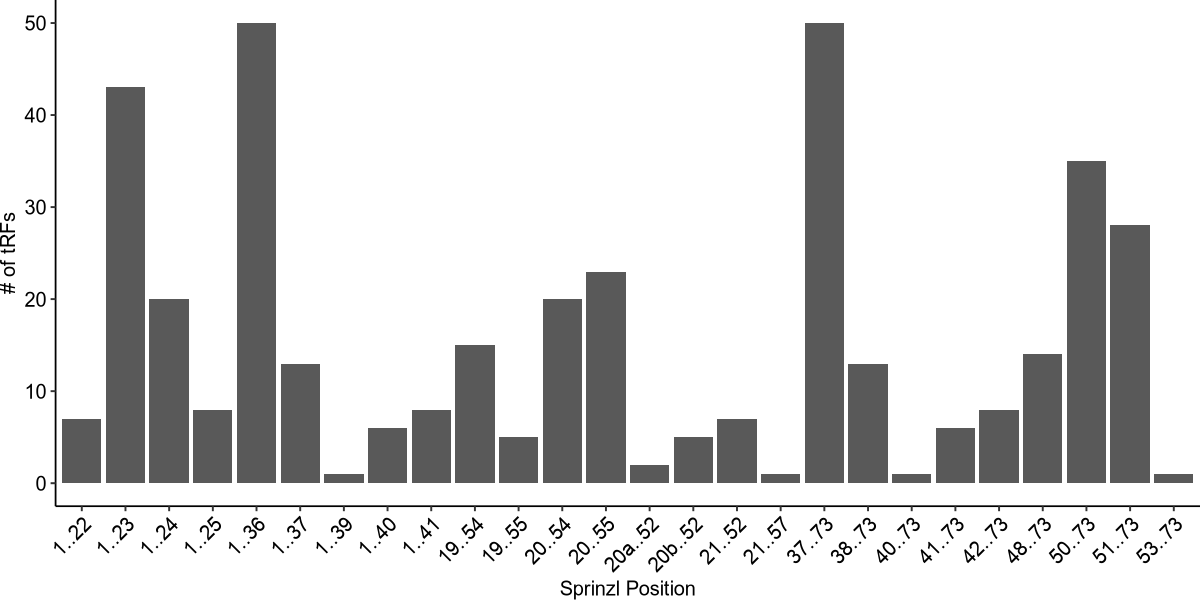

In [ ]:
wfix = 10
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

sprinzl_positions_counts = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig1/sprinzl_positions_counts.rds')

sprinzl_positions_counts %>% 
    ggplot(aes(x = sprinzl_positions, y = Freq)) + geom_bar(stat = "identity") + theme_pubr() + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) + xlab('Sprinzl Position') + ylab('# of tRFs') +
    theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))
ggsave(paste0(path, 'fig_output/data/fig1/sprinzl_positions_counts.pdf'), width = wfix, height = hfix)

### VEGFA single cell expression ###

Warning message in grid.Call.graphics(C_points, x$x, x$y, x$pch, x$size):
“conversion failure on '—' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_points, x$x, x$y, x$pch, x$size):
“conversion failure on '—' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call.graphics(C_points, x$x, x$y, x$pch, x$size):
“conversion failure on '—' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_points, x$x, x$y, x$pch, x$size):
“font metrics unknown for Unicode character U+2014”
Warning message in grid.Call.graphics(C_points, x$x, x$y, x$pch, x$size):
“conversion failure on '—' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_points, x$x, x$y, x$pch, x$size):
“conversion failure on '—' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call.graphics(C_points, x$x, x$y, x$pch, x$size):
“conversion failure on '—' in 'mbcsToSbcs': dot substituted for <94>”
Warning me

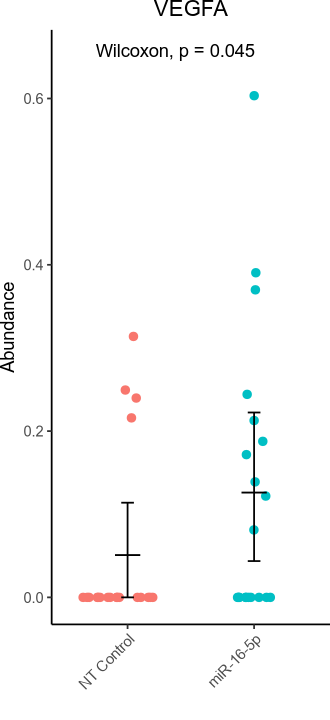

In [15]:
wfix = 2.75
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

## n = 20 cells per condition ##
df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig1/VEGFA_miR16_control_single_cell.rds')
df$guide[df$guide == 'control'] = 'NT Control'
df$guide = factor(df$guide, levels = c('NT Control', 'miR-16-5p'))

df %>%
  ggplot(aes(guide, exp, color = guide)) + geom_sina(size = 2, maxwidth = 0.75) + theme_classic() + scale_shape_manual(values=c(19, 15)) +
  stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.1, fun.args=list(conf.int = 0.99), color = 'black') + stat_summary(fun.y = mean, geom = "point", size = 5, shape = '\U2014', color = 'black') + #scale_y_continuous(trans='log10', breaks = c(1, 10^0.5, 10),labels = scales::trans_format("log10", scales::math_format(10^.x))) +
  theme(legend.position = 'none', plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + ylab('Abundance') + xlab('') + stat_compare_means(label.y = 0.65, method.args = list(alternative = "greater")) + ggtitle('VEGFA') + #theme_pubr() +
  theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig1/miR_VEGFA_expression.pdf'), width = wfix, height = hfix)

### miR cell guide count ###

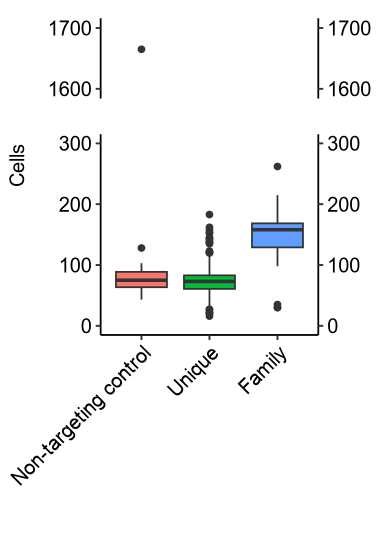

In [2]:
wfix = 3.25
hfix = 4.5
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

miR_df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig1/miR_qc_cell_guide_counts.rds')

miR_df %>% ggplot(aes(x = family_status, y = count, fill = family_status)) + xlab('') + geom_boxplot(show.legend = FALSE) + 
theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1), axis.title.y = element_text(hjust = 0.7)) + scale_y_break(c(300, 1590), ticklabels = c(300, 1600, 1700), space = 0.65) + ylim(c(0, 1710)) +
scale_fill_discrete() + ylab('Cells') + theme(axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig1/miR_cell_guide_count.pdf'), width = wfix, height = hfix)

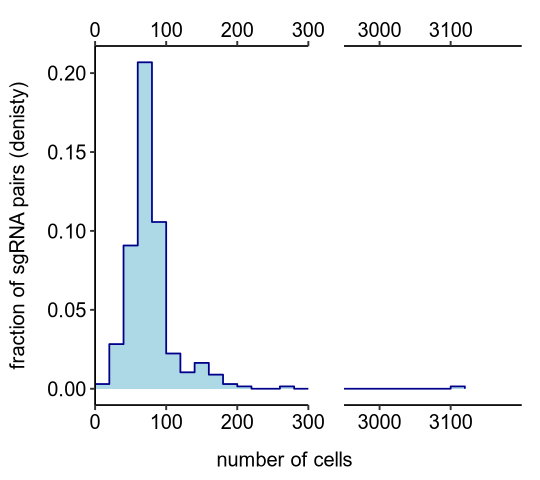

In [ ]:
wfix = 4.5
hfix = 4
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

adata.miR = readRDS('/home/ssobti/projects/mir_tud/010523_filtered_data/miR_normalized_integrated_seurat.rds')
meta = adata.miR@meta.data
cell_counts = table(meta$miR.family)

set.seed(1)
x = hist(cell_counts, 200, plot = FALSE)
df = data.frame(
  x = rep(x$breaks, each=2), 
  y = c(0, rep(x$counts, each = 2), 0))
df$y = df$y/sum(df$y) 

ggplot(df, aes(x, y)) + 
  geom_polygon(fill = 'lightblue') + 
  geom_line(color = 'darkblue') + theme_pubr() + ylab('fraction of sgRNA pairs (density)') + xlab('number of cells') +
  scale_x_break(c(300, 2950), ticklabels = c(300, 3000, 3100), space = 0.65, expand = c(0, 0)) + xlim(c(0, 3200)) + theme(axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig1/miR_cell_guide_count_density.pdf'), width = wfix, height = hfix)

### miR counts by family status ###

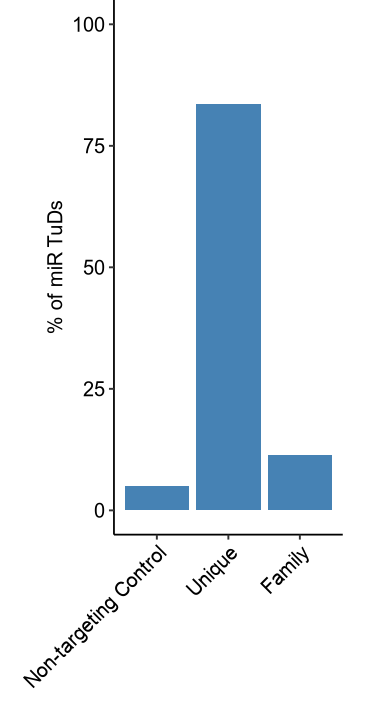

In [3]:
wfix = 3.25
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

miR_family_df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig1/miR_qc_family_counts.rds')

miR_family_df %>% ggplot(aes(x = family_status, y = percent)) +
  geom_bar(stat = "identity", fill = "steelblue") + theme_pubr() + ylab('% of miR TuDs') + xlab('') + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1), plot.margin = unit(c(0,1,0,1), "cm")) + ylim(c(0, 100)) +
  theme(axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig1/miR_guide_family_status.pdf'), width = wfix, height = hfix)

### tRF cell guide count ###

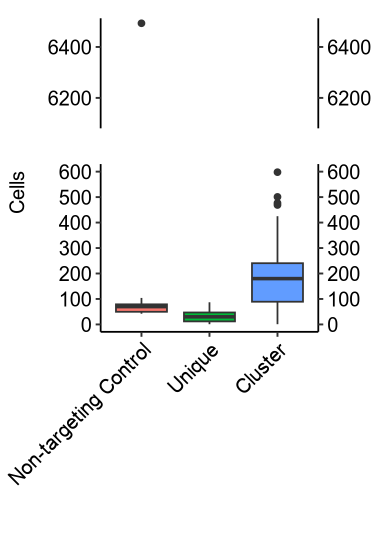

In [26]:
wfix = 3.25
hfix = 4.5
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

tRF_df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig1/tRF_qc_cell_guide_counts.rds')

tRF_df %>% ggplot(aes(x = cluster_status, y = count, fill = cluster_status)) + xlab('') + geom_boxplot(show.legend = FALSE) + 
theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1), axis.title.y = element_text(hjust = 0.64)) + scale_y_continuous(breaks = scales::pretty_breaks(n = 8)) + scale_y_break(c(600, 6100), ticklabels = c(600, 6200, 6400), space = 0.65) +
scale_fill_discrete() + ylab('Cells') + theme(axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig1/tRF_cell_guide_count.pdf'), width = wfix, height = hfix)

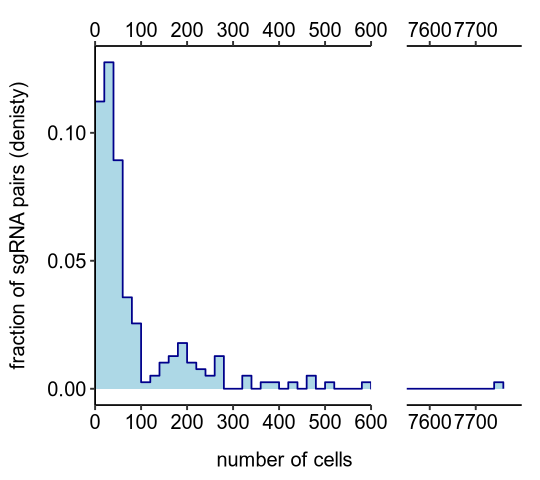

In [ ]:
wfix = 4.5
hfix = 4
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

adata.tRF = readRDS('/home/ssobti/projects/mir_tud/010523_filtered_data/tRF_normalized_integrated_seurat.rds')
meta = adata.tRF@meta.data
meta$guide[stringr::str_sub(meta$guide, 1, 3) == 'TuD'] <- 'TuD_NC'
cell_counts = table(meta$guide)

set.seed(1)
x = hist(cell_counts, 329, plot = FALSE)
df = data.frame(
  x = rep(x$breaks, each=2), 
  y = c(0, rep(x$counts, each = 2), 0))
df$y = df$y/sum(df$y) 

ggplot(df, aes(x, y)) + 
  geom_polygon(fill = 'lightblue') + 
  geom_line(color = 'darkblue') + theme_pubr() + ylab('fraction of sgRNA pairs (density)') + xlab('number of cells') +
  scale_x_break(c(600, 7550), ticklabels = c(600, 7600, 7700), space = 0.65, expand = c(0, 0)) + xlim(c(0, 7800)) + theme(axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig1/tRF_cell_guide_count_density.pdf'), width = wfix, height = hfix)

### tRF counts by cluster status ###

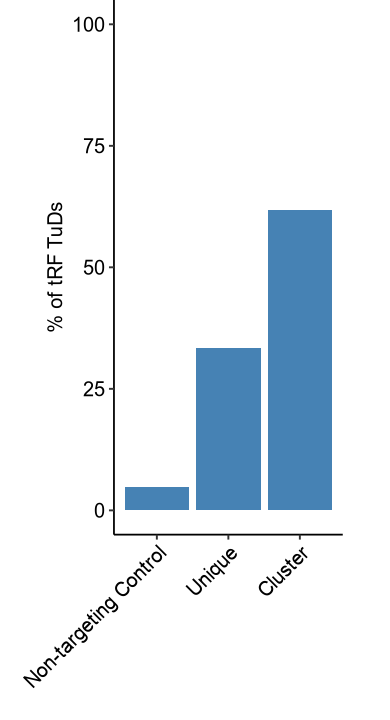

In [27]:
wfix = 3.25
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

tRF_cluster_df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig1/tRF_qc_cluster_counts.rds')

tRF_cluster_df %>% ggplot(aes(x = cluster_status, y = percent)) +
  geom_bar(stat = "identity", fill = "steelblue") + theme_pubr() + ylab('% of tRF TuDs') + xlab('') + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1), plot.margin = unit(c(0,1,0,1), "cm")) + ylim(c(0, 100)) +
  theme(axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig1/tRF_guide_cluster_status.pdf'), width = wfix, height = hfix)

## Fig 2-3 broad scale patterns ##

### Variable gene heatmaps ###

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

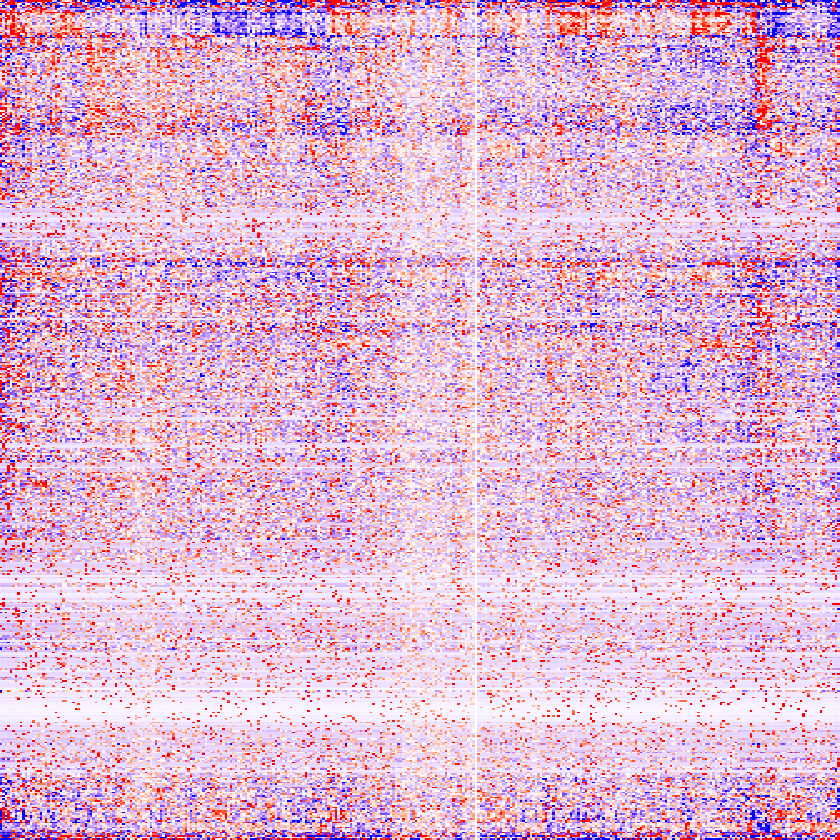

In [3]:
## miR ##
## rows are 3000 var genes, columns are perturbations
Pseudo_bulk_exp = readRDS(paste0(path, 'fig_output/data/fig2/miR_perturbation_pseudo_bulk_exp.rds'))

avg = mean(Pseudo_bulk_exp)
lower_bound = mean(Pseudo_bulk_exp) - 2*sd(Pseudo_bulk_exp)
upper_bound = mean(Pseudo_bulk_exp) + 2*sd(Pseudo_bulk_exp)
coloring_map <- circlize::colorRamp2(c(lower_bound, avg, upper_bound), c("blue", "white", "red"))

perturb_htmp <- function(matrix, title) {
  draw(Heatmap(matrix, name = title, show_column_names = FALSE, show_row_names = FALSE, show_column_dend = FALSE,
               col = coloring_map, show_row_dend = FALSE, use_raster = TRUE, row_title = NULL, 
               column_title = NULL, row_title_side = 'left', column_title_side = 'top', 
               column_names_gp = gpar(fontsize = 2), row_names_gp = gpar(fontsize = 1), show_heatmap_legend = FALSE), padding = unit(c(0, 0, 0, 0), "mm"))
}

perturb_htmp(Pseudo_bulk_exp, 'Pseudo-bulk')

options(repr.plot.width = 16, repr.plot.height = 14)
pdf(paste0(path, 'fig_output/data/fig2/miR_avg_genexp_htmap.pdf'), width = 1.378, height = 1.2631)
perturb_htmp(Pseudo_bulk_exp, 'Pseudo-bulk')
dev.off()

In [4]:
options(repr.plot.width = 16, repr.plot.height = 14)
pdf('/home/ssobti/projects/mir_tud/fig_output/miR_avg_genexp_htmap_legend.pdf', width = 1.378, height = 1.2631)
draw(Legend(col_fun = coloring_map))
dev.off()

pdf 
  2

In [5]:
## tRF ##
## rows are 3000 var genes, columns are perturbations
Pseudo_bulk_exp = readRDS(paste0(path, 'fig_output/data/fig2/tRF_pseudo_bulk_exp.rds'))
avg = mean(Pseudo_bulk_exp)
lower_bound = mean(Pseudo_bulk_exp) - 2*sd(Pseudo_bulk_exp)
upper_bound = mean(Pseudo_bulk_exp) + 2*sd(Pseudo_bulk_exp)
coloring_map <- circlize::colorRamp2(c(lower_bound, avg, upper_bound), c("blue", "white", "red"))

perturb_htmp <- function(matrix, title) {
  draw(Heatmap(matrix, name = title, show_column_names = FALSE, show_row_names = FALSE, show_column_dend = FALSE,
               col = coloring_map, show_row_dend = FALSE, use_raster = TRUE, row_title = NULL, 
               column_title = NULL, row_title_side = 'left', column_title_side = 'top', 
               column_names_gp = gpar(fontsize = 2), row_names_gp = gpar(fontsize = 1), show_heatmap_legend = FALSE), padding = unit(c(0, 0, 0, 0), "mm"))
}


options(repr.plot.width = 16, repr.plot.height = 14)
pdf(paste0(path, 'fig_output/data/fig2/tRF_avg_genexp_htmap.pdf'), width = 1.378, height = 1.2631)
perturb_htmp(Pseudo_bulk_exp, 'Pseudo-bulk')
dev.off()

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

In [6]:
options(repr.plot.width = 16, repr.plot.height = 14)
pdf('/home/ssobti/projects/mir_tud/fig_output/tRF_avg_genexp_htmap_legend.pdf', width = 1.378, height = 1.2631)
draw(Legend(col_fun = coloring_map))
dev.off()

pdf 
  2

### Pertubation-perturbation correlation heatmaps ###

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

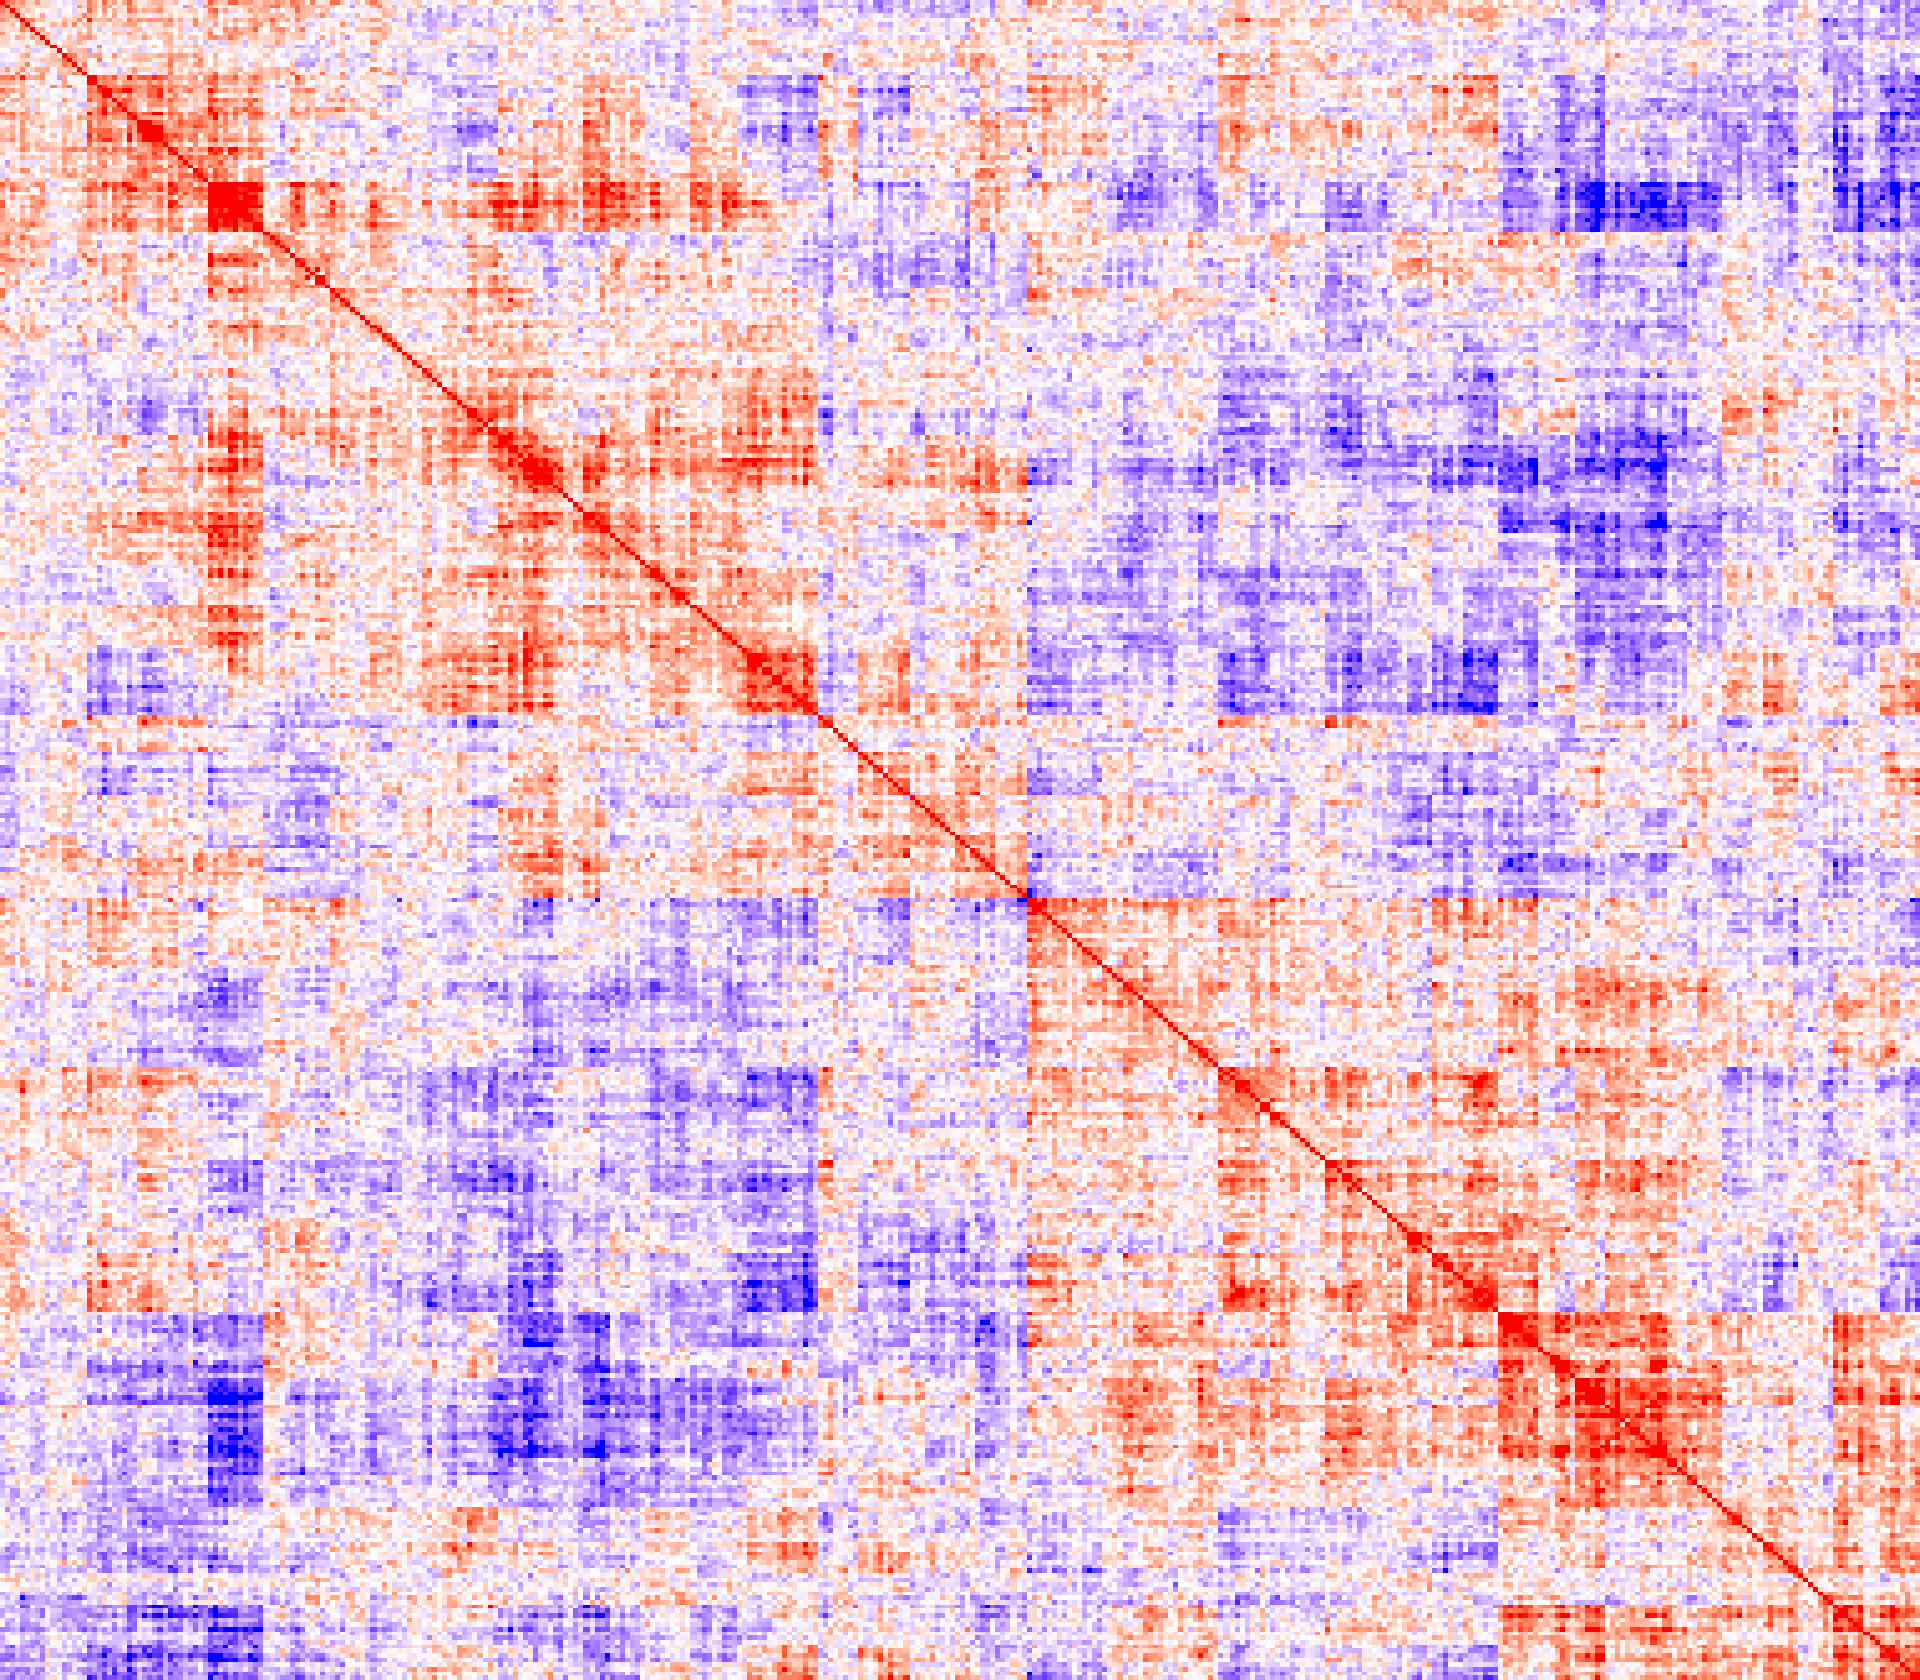

In [26]:
## miR ##
perturb_perturb_corr_mtx = readRDS(paste0(path, 'fig_output/data/fig2/miR_perturbation_perturb_perturb_corr_mtx.rds'))
set.seed(20)
avg = mean(perturb_perturb_corr_mtx)
lower_bound = mean(perturb_perturb_corr_mtx) - 2*sd(perturb_perturb_corr_mtx)
upper_bound = mean(perturb_perturb_corr_mtx) + 2*sd(perturb_perturb_corr_mtx)
coloring_map <- circlize::colorRamp2(c(-upper_bound, avg, upper_bound), c("blue", "white", "red"))

annot = rowAnnotation(perturb = runif(nrow(perturb_perturb_corr_mtx)), show_legend = FALSE, show_annotation_name = FALSE)

perturb_perturb_corr_mtx_htmp <- function(matrix, title, annotation) {
  draw(Heatmap(matrix, name = title, show_column_names = FALSE, show_row_names = FALSE, show_column_dend = FALSE,
               col = coloring_map, show_row_dend = FALSE, use_raster = TRUE, row_title = NULL, 
               column_title = NULL, row_title_side = 'left', column_title_side = 'top', 
               column_names_gp = gpar(fontsize = 2), row_names_gp = gpar(fontsize = 1),
               left_annotation = NULL, show_heatmap_legend = FALSE), padding = unit(c(0, 0, 0, 0), "mm"))
}

perturb_perturb_corr_mtx_htmp(perturb_perturb_corr_mtx, 'Pb-Pb Corr Matrix', annot)

options(repr.plot.width = 16, repr.plot.height = 14)
pdf(paste0(path, 'fig_output/data/fig2/miR_avg_genexp_corr_htmap.pdf'), width = 1.378, height = 1.2631)
perturb_perturb_corr_mtx_htmp(perturb_perturb_corr_mtx, 'Pb-Pb Corr Matrix', annot)
dev.off()


In [27]:
options(repr.plot.width = 16, repr.plot.height = 14)
pdf('/home/ssobti/projects/mir_tud/fig_output/miR_avg_genexp_corr_htmap_legend.pdf', width = 1.378, height = 1.2631)
draw(Legend(col_fun = coloring_map))
dev.off()

pdf 
  2

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

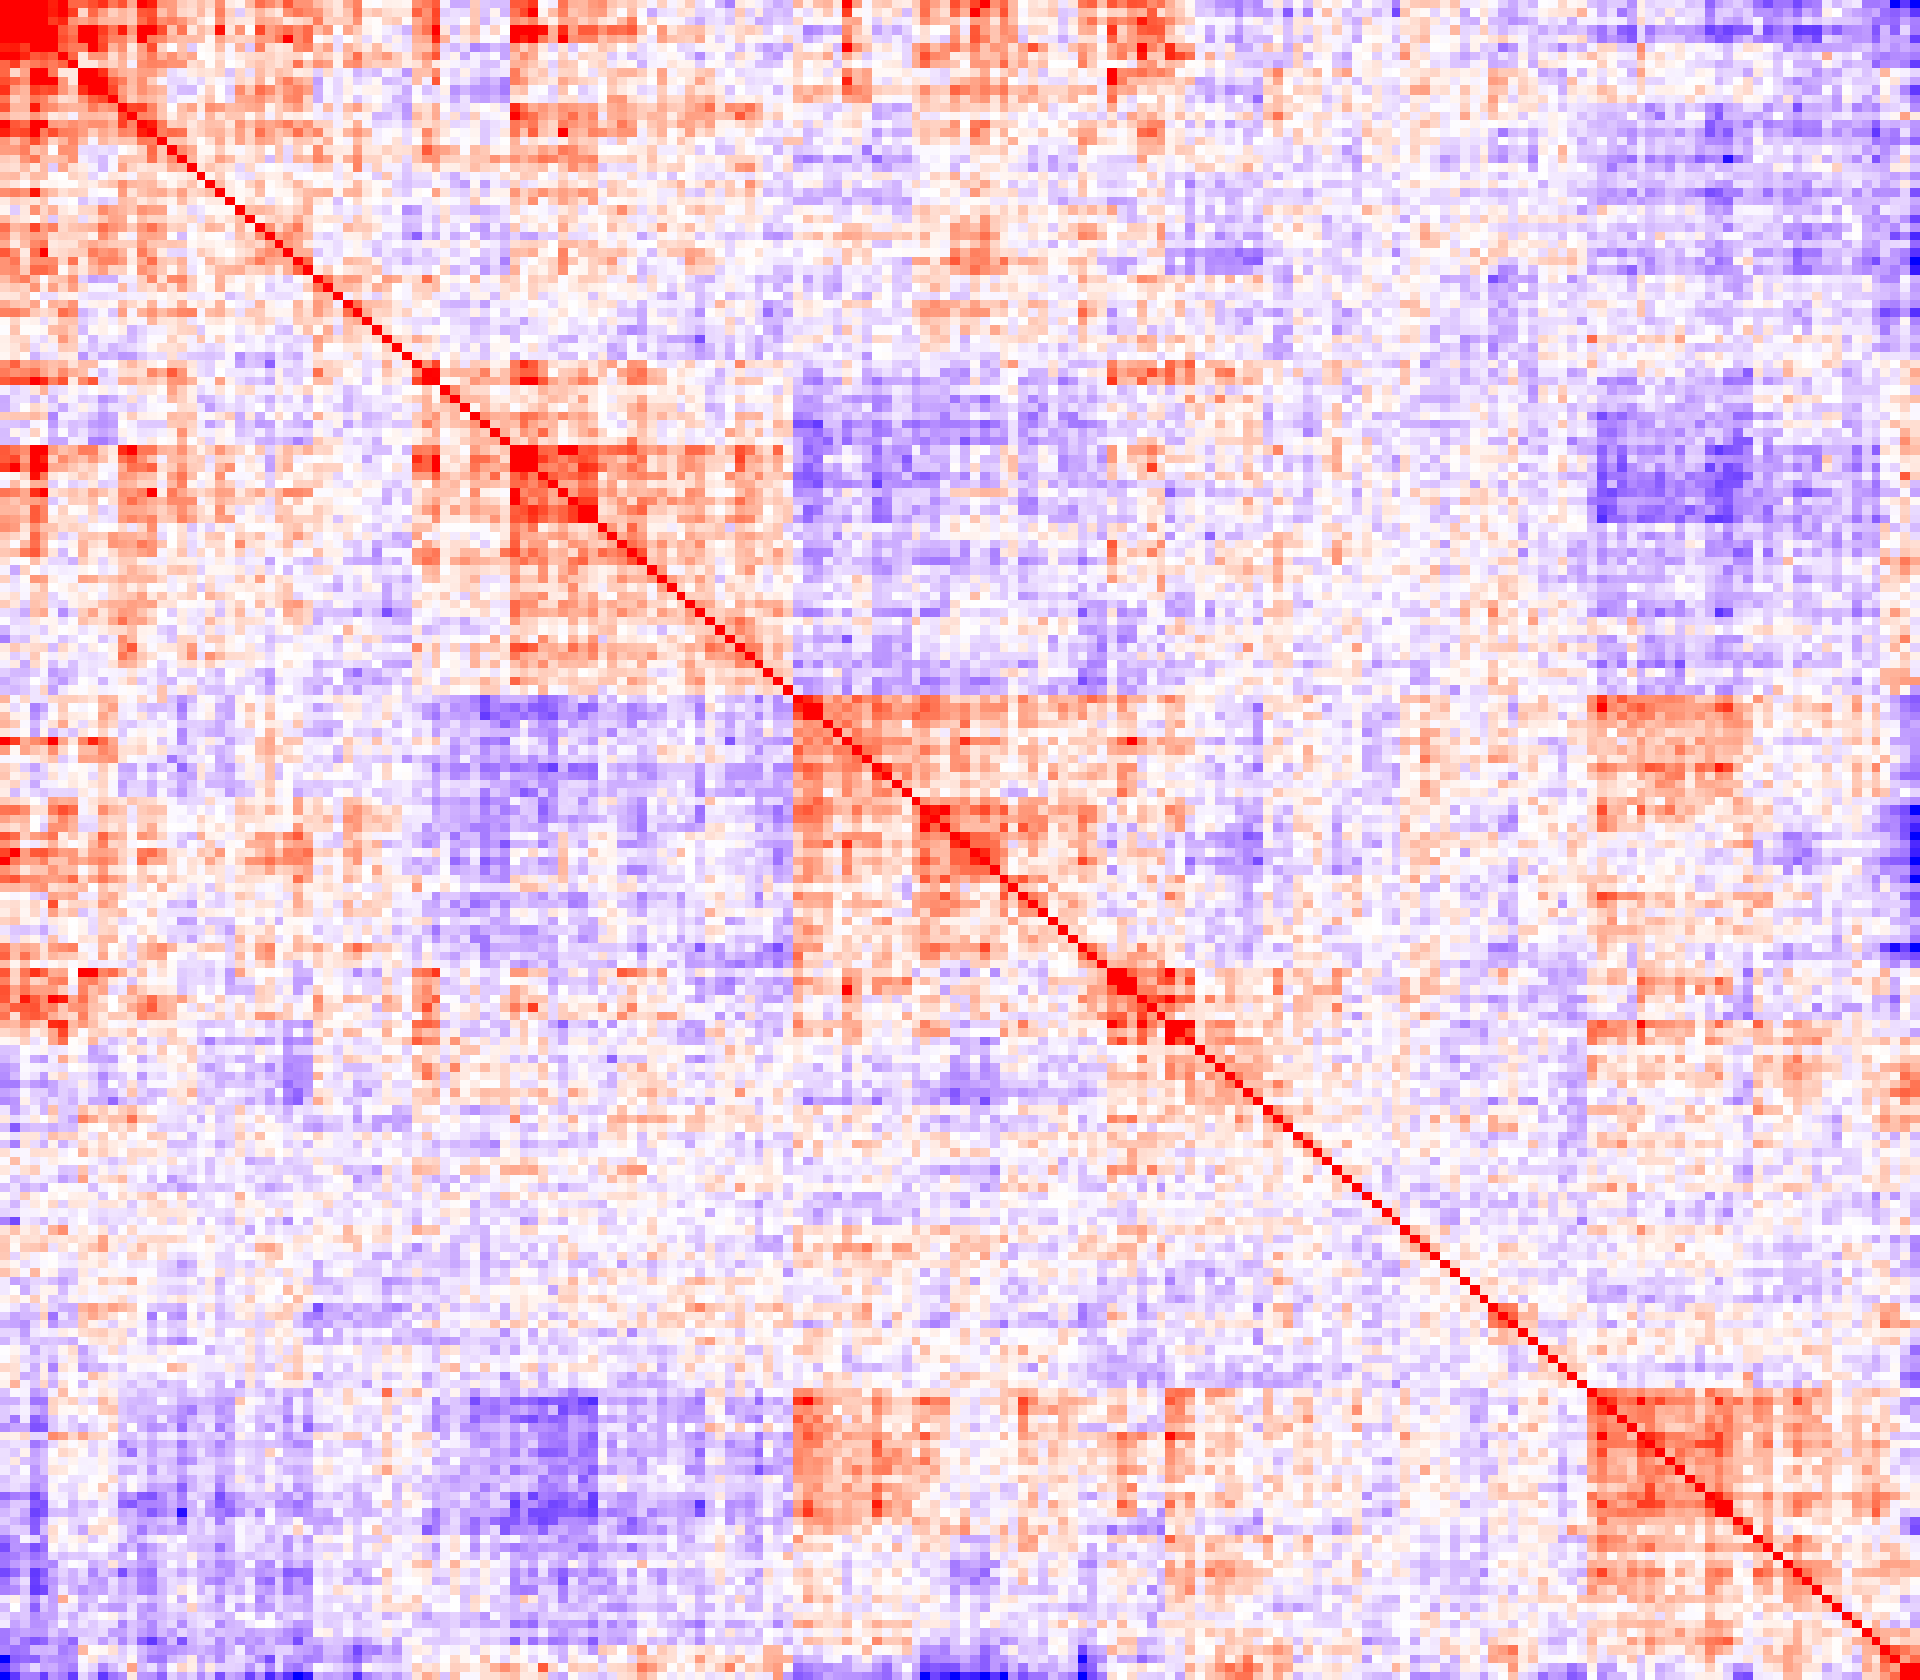

In [28]:
## tRF ##
perturb_perturb_corr_mtx = readRDS(paste0(path, 'fig_output/data/fig2/tRF_perturb_perturb_corr_mtx.rds'))
set.seed(20)
avg = mean(perturb_perturb_corr_mtx)
lower_bound = mean(perturb_perturb_corr_mtx) - 2*sd(perturb_perturb_corr_mtx)
upper_bound = mean(perturb_perturb_corr_mtx) + 2*sd(perturb_perturb_corr_mtx)
coloring_map <- circlize::colorRamp2(c(-upper_bound, avg, upper_bound), c("blue", "white", "red"))

annot = rowAnnotation(perturb = runif(nrow(perturb_perturb_corr_mtx)), show_legend = FALSE, show_annotation_name = FALSE)

perturb_perturb_corr_mtx_htmp <- function(matrix, title, annotation) {
  draw(Heatmap(matrix, name = title, show_column_names = FALSE, show_row_names = FALSE, show_column_dend = FALSE,
               col = coloring_map, show_row_dend = FALSE, use_raster = TRUE, row_title = NULL, 
               column_title = NULL, row_title_side = 'left', column_title_side = 'top', 
               column_names_gp = gpar(fontsize = 2), row_names_gp = gpar(fontsize = 1),
               left_annotation = NULL, show_heatmap_legend = FALSE), padding = unit(c(0, 0, 0, 0), "mm"))
}

perturb_perturb_corr_mtx_htmp(perturb_perturb_corr_mtx, 'Pb-Pb Corr Matrix', annot)

options(repr.plot.width = 16, repr.plot.height = 14)
pdf(paste0(path, 'fig_output/data/fig2/tRF_avg_genexp_corr_htmap.pdf'), width = 1.378, height = 1.2631)
perturb_perturb_corr_mtx_htmp(perturb_perturb_corr_mtx, 'Pb-Pb Corr Matrix', annot)
dev.off()

In [29]:
options(repr.plot.width = 16, repr.plot.height = 14)
pdf('/home/ssobti/projects/mir_tud/fig_output/tRF_avg_genexp_corr_htmap_legend.pdf', width = 1.378, height = 1.2631)
draw(Legend(col_fun = coloring_map))
dev.off()

pdf 
  2

### Trascriptomic perturbation correlation within miR families vs random unique guide families ###

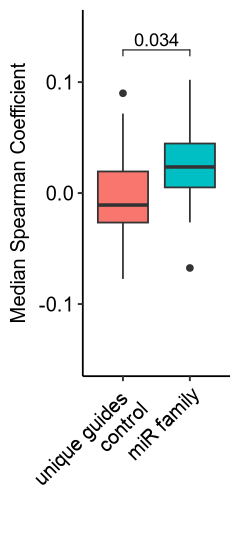

In [2]:
wfix = 2
hfix = 4.5
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig2/miR_family_vs_random_unique_guides_correlation_values.rds')
comparison = list(c('unique guides \n control', 'miR family'))
df %>% ggplot(aes(x = family_status, y = median_correlation, fill = family_status)) + xlab('') + geom_boxplot(show.legend = FALSE) + 
ggpubr::theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) +
scale_fill_discrete() + ylab('Median Spearman Coefficient') + ggpubr::stat_compare_means(comparisons = comparison,label.y = 0.12) + ylim(c(-0.15, 0.15)) +
theme(axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica")) #+ ggtitle('Intrafamily vs Intrarandom Unique miR Guides Correlation Values') + theme(legend.position = 'none')

ggsave(paste0(path, 'fig_output/data/fig2/transcriptomic_perturbation_correlation_within_miR_families_vs_random_unique_guides_families.pdf'), width = wfix, height = hfix)

### Trascriptomic perturbation correlation within tRF clusters vs random unique guide clusters ###

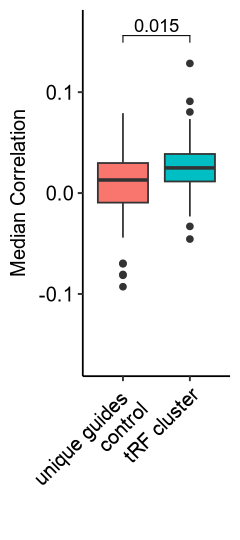

In [3]:
wfix = 2
hfix = 4.5
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig2/tRF_cluster_vs_random_unique_guides_correlation_values.rds')

comparison = list(c('unique guides \n control', 'tRF cluster'))
df %>% ggplot(aes(x = cluster_status, y = median_correlation, fill = cluster_status)) + xlab('') + geom_boxplot(show.legend = FALSE) + 
ggpubr::theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) +
scale_fill_discrete() + ylab('Median Correlation') + ggpubr::stat_compare_means(comparisons = comparison,label.y = 0.145) + ylim(c(-0.165, 0.165)) #+ ggtitle('Intracluster vs Intrarandom Unique tRF Guides Correlation Values') + theme(legend.position = 'none')

ggsave(paste0(path, 'fig_output/data/fig2/transcriptomic_perturbation_correlation_within_tRF_clusters_vs_random_unique_guides_clusters.pdf'), width = wfix, height = hfix)

### miR VAE UMAP ###


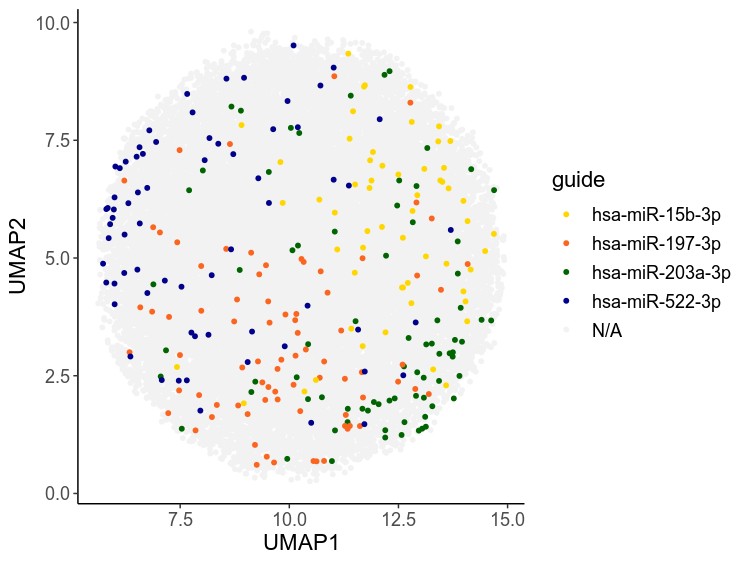

In [8]:
wfix = 6.25
hfix = 4.7
options(repr.plot.width = wfix, repr.plot.height = hfix)
## last fig saved size was 5.9 x 4.7
## fig size in illustrator is shrunk to 3.54 x 2.82
scale_factor = hfix/2.82  ## always divide height by height -- much less likely to change to make figure look better

UMAP_output_select = readRDS(paste0(path, 'fig_output/data/fig2/VAE_UMAP.rds'))
colors = c('hsa-miR-203a-3p' = 'darkgreen', 'hsa-miR-522-3p' = '#00008B', 'hsa-miR-15b-3p' = '#FFD700', 'hsa-miR-197-3p' = '#FA6520', 'N/A' = 'gray95')
ggplot(UMAP_output_select, aes(UMAP1, UMAP2, color = guide)) + geom_point(size = 1) + 
        theme_classic() + scale_color_manual(values = colors) + theme(plot.title = element_text(hjust = 0.5)) +
        xlab('UMAP1') + ylab('UMAP2') + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig2/VAE_UMAP.pdf'), width = wfix, height = hfix)

### supplemental fig miR guides e-distance to varying controls ###

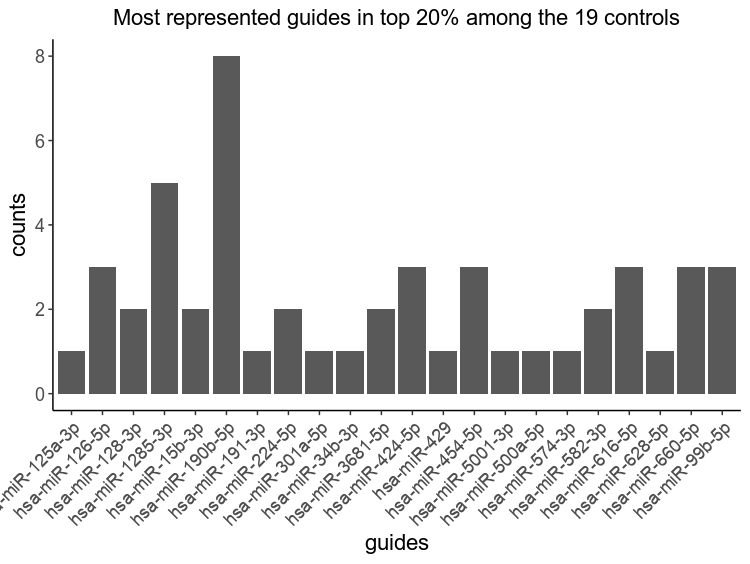

In [9]:
## bargraph of top 20% most distant miR TuDs/guides from 19 control guides in PC space 
wfix = 5.47
hfix = 4
## expected height in illustrator is 3
options(repr.plot.width = wfix, repr.plot.height = hfix)
scale_factor = hfix/3

## draw barplots showing distances of the perturbations to each of the controls
## capture top 20% furthest guides from each of the controls
estats = read.csv(paste0(path, 'fig_output/data/fig2/miR_estats_mtx_separate_controls.csv'), row.names = 1)
startsWith(colnames(estats), prefix = 'TuD') -> status
names <- rownames(estats)[status]
tp20_pct = rep(list(matrix(0,5,5)), length(names))
dotplot = rep(list(matrix(0,5,5)), length(names))
for (i in 1:length(names)){
  startsWith(colnames(estats), prefix = 'TuD') -> status
  control_status = 1:length(status)
  control_status[status] <- 'control'
  control_status[!status] <- 'perturbation'
  estats_control1 <- data.frame(comparison_to_control_NC1 = estats[,names[i]], guide = control_status, guide_nm = rownames(estats))
  estats_control1 <- estats_control1[order(estats_control1$guide, decreasing = TRUE),]
  estats_control1$guide <- factor(estats_control1$guide, levels = c('perturbation', 'control'))
  tp20_pct[[i]] <- as.character(estats_control1[order(estats_control1$comparison_to_control_NC1, decreasing = TRUE),"guide_nm"][1:ceiling(0.2*nrow(estats_control1))])
  dotplot[[i]] = ggplot(estats_control1, aes(x = 1, y=comparison_to_control_NC1, fill = guide)) + 
    geom_dotplot(binaxis='y', stackdir='center',
                 stackratio=1.5, dotsize=1.2, binwidth = 0.5) + scale_fill_viridis_d() + 
    geom_text_repel(aes(y = comparison_to_control_NC1, x = 1, label = guide_nm),
                    xlim = c(0, 0.95), 
                    direction = "y") +
    theme_classic() + ylab('E-distance to TuD_NC') + xlab('') + ggtitle(names[i])
}

names(dotplot) <- names

set.seed(44)
nms_list = replicate(10, Reduce(intersect, sample(tp20_pct, 5, replace = FALSE)))
nms = unlist(nms_list)
df = data.frame(guides = nms)
df = count(df, guides, name = 'counts')

barpl <- ggplot(df, aes(x = guides, y = counts)) + geom_col() + theme_classic() + ggtitle('Most represented guides in top 20% among the 19 controls') +
  theme(axis.text.x = element_text(angle = 45, hjust=1), plot.title = element_text(hjust = 0.5)) + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))


barpl

ggsave(paste0(path, 'fig_output/data/fig2/barplot_top20pct_most_edist_guides.pdf'), width = 5.47, height = 4)

## Fig 2-3 Phenotypes ##

### CV/heterogeneity jittered dotplot ###

Warning message:
“ggrepel: 1305 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 1305 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


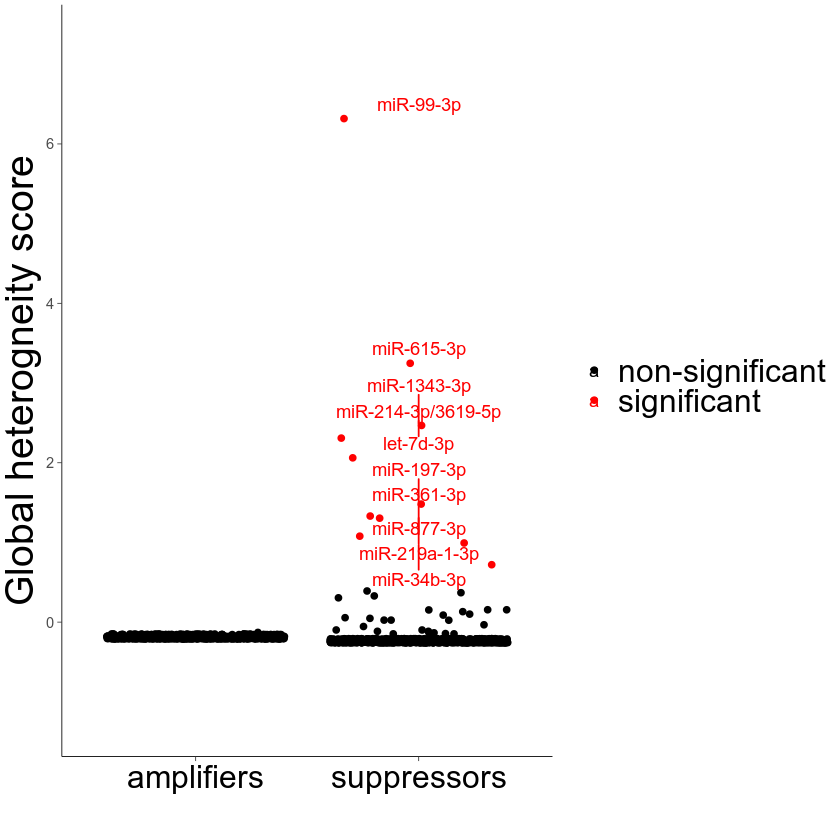

In [29]:
## miR ##
wfix = 7
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.39
scale_factor = hfix/2.39 ## always divide height by height -- much less likely to change to make figure look better

median_z_scores_long = readRDS(paste0(path, 'fig_output/data/fig3/miR_median_z_scores_long.rds'))
median_z_scores_long$type = ifelse(median_z_scores_long$type == 'z_score_increasing_genes', 'suppressors', 'amplifiers')
ggplot(median_z_scores_long, aes(x = type, y = median_z_score, color = condition)) + geom_jitter() + geom_text_repel(aes(y = median_z_score, x = type, label = guide), direction = "y") + theme_classic() + scale_color_manual(values = c('significant' = 'red', 'non-significant' = 'black')) +
ylab('Global heterogneity score') + xlab('') + coord_cartesian(clip = 'off') + ylim(min(median_z_scores_long$median_z_score) - 1, max(median_z_scores_long$median_z_score) + 1) + theme(plot.margin = margin(0.1, 0.1, 0.1, 0.1, "cm")) + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_blank(), text = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig3/miR_heterogeneity_jitter.pdf'), width = wfix, height = hfix)

Warning message:
“ggrepel: 496 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 493 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


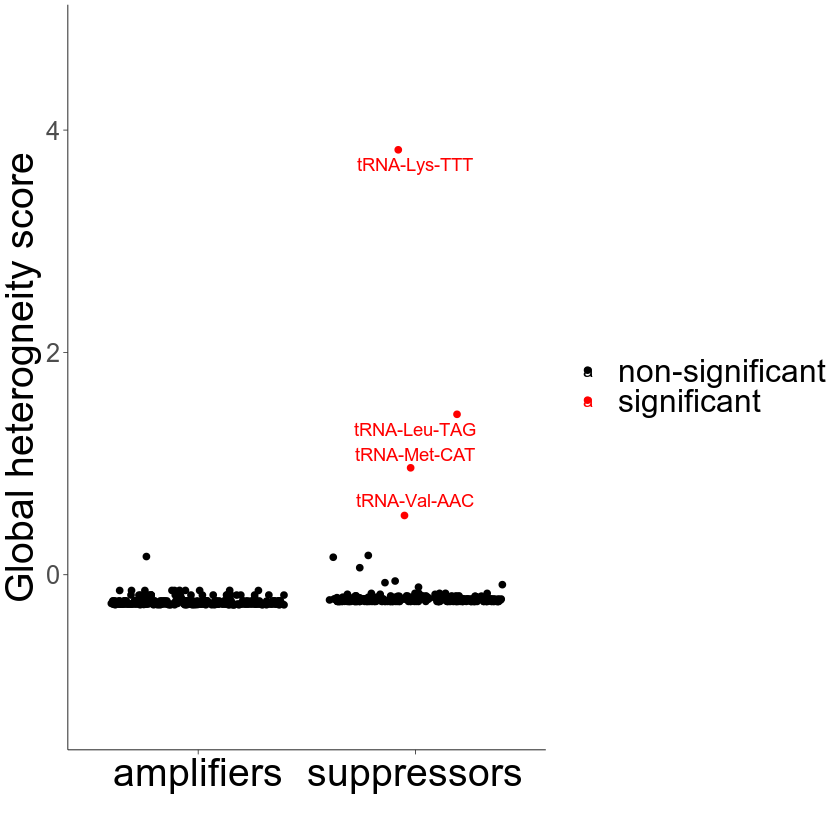

In [28]:
## tRF ##
wfix = 7
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.39
scale_factor = hfix/2.39 ## always divide height by height -- much less likely to change to make figure look better

# y-axis original label 'Median z-score across 10 seeds'
# x-axis original label z_score_decreasing_genes, z_score_increasing_genes

median_z_scores_long = readRDS(paste0(path, 'fig_output/data/fig3/tRF_median_z_scores_long.rds'))
median_z_scores_long$guide = condense_tRF_names(median_z_scores_long$guide)
median_z_scores_long$type = ifelse(median_z_scores_long$type == 'z_score_increasing_genes', 'suppressors', 'amplifiers')
ggplot(median_z_scores_long, aes(x = type, y = median_z_score, color = condition)) + geom_jitter() + geom_text_repel(aes(y = median_z_score, x = type, label = guide), direction = "y") + theme_classic() + scale_color_manual(values = c('significant' = 'red', 'non-significant' = 'black')) +
ylab('Global heterogneity score') + xlab('') + coord_cartesian(clip = 'off') + ylim(min(median_z_scores_long$median_z_score) - 1, max(median_z_scores_long$median_z_score) + 1) + theme(plot.margin = margin(0.1, 0.1, 0.1, 0.1, "cm")) + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_blank(), text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig3/tRF_heterogeneity_jitter.pdf'), width = wfix, height = hfix)

### Hallmark heatmap ###

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



png 
  2

png 
  2

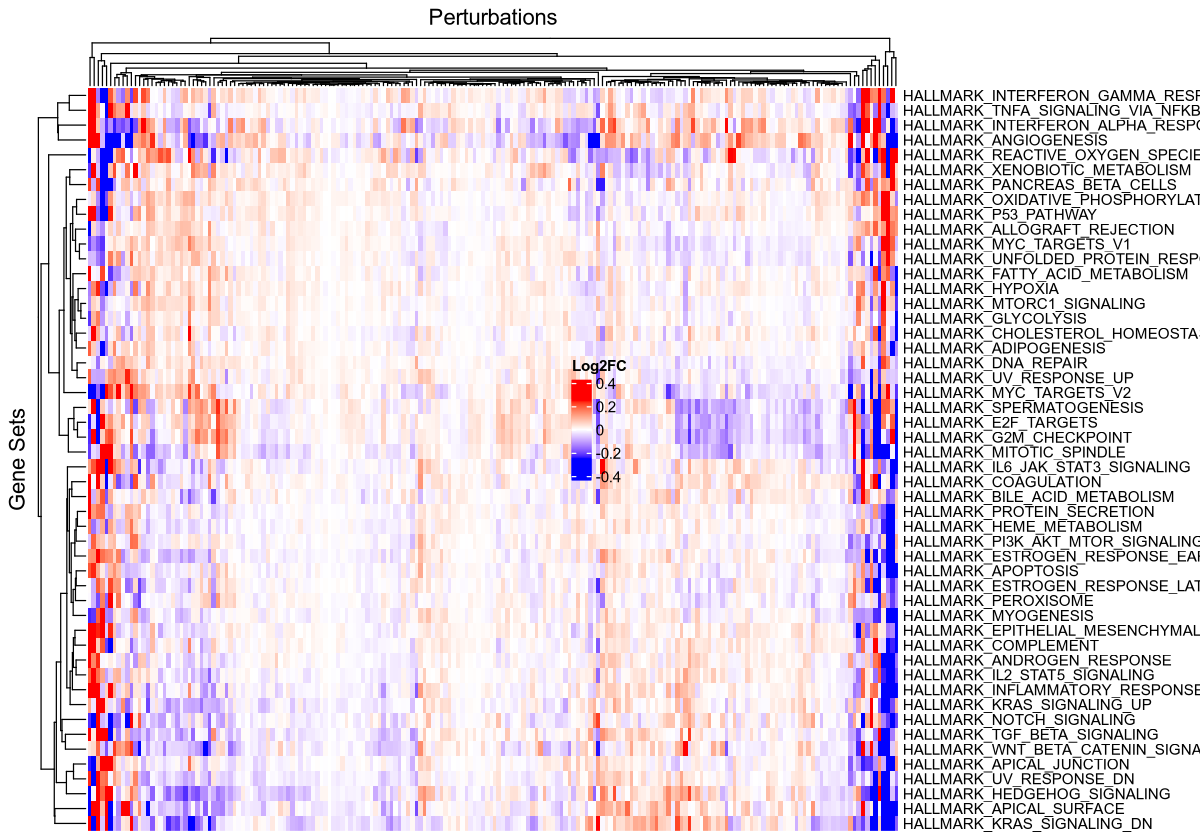

In [16]:
## tRF ##
wfix = 10
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/5 ## always divide height by height -- much less likely to change to make figure look better

genesetexp_x_guide_FC = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig3/tRF_hallmark_heatmap.rds')
genesetexp_x_guide_FC = log2(genesetexp_x_guide_FC)
avg = mean(genesetexp_x_guide_FC)
lower_bound = mean(genesetexp_x_guide_FC) - 2.5*sd(genesetexp_x_guide_FC)  ## tried 2 and 5 sd for different effects
upper_bound = mean(genesetexp_x_guide_FC) + 2.5*sd(genesetexp_x_guide_FC)

coloring_map <- circlize::colorRamp2(c(lower_bound, avg, upper_bound), c("blue", "white", "red"))

perturb_htmp <- function(matrix, title) {
  draw(Heatmap(matrix, name = title, show_column_names = FALSE, show_row_names = TRUE, show_column_dend = TRUE,
               col = coloring_map, show_row_dend = TRUE, use_raster = TRUE, row_title = 'Gene Sets', 
               column_title = 'Perturbations', row_title_side = 'left', column_title_side = 'top', show_heatmap_legend = FALSE,
               column_names_gp = gpar(fontfamily = "Helvetica", fontsize = minor_text_size*scale_factor), row_names_gp = gpar(fontfamily = "Helvetica", fontsize = minor_text_size*scale_factor)))
}

perturb_htmp(genesetexp_x_guide_FC, 'Log2FC')
pdf(paste0(path, 'fig_output/data/fig3/tRF_hallmark_heatmap_2point5sd.pdf'), width = wfix, height = hfix)
perturb_htmp(genesetexp_x_guide_FC, 'Fold Change')
dev.off()

draw(Legend(col_fun = coloring_map, title = 'Log2FC', title_gp = gpar(fontfamily = "Helvetica", fontsize = minor_text_size*scale_factor, fontface = "bold"), labels_gp = gpar(fontfamily = "Helvetica", fontsize = minor_text_size*scale_factor), legend_gp = gpar(fontfamily = "Helvetica", fontsize = minor_text_size*scale_factor)))
pdf(paste0(path, 'fig_output/data/fig3/tRF_hallmark_heatmap_legend_2point5sd.pdf'), width = wfix, height = hfix)
draw(Legend(col_fun = coloring_map, title = 'Fold Change', title_gp = gpar(fontfamily = "Helvetica", fontsize = minor_text_size*scale_factor, fontface = "bold"), labels_gp = gpar(fontfamily = "Helvetica", fontsize = minor_text_size*scale_factor), legend_gp = gpar(fontfamily = "Helvetica", fontsize = minor_text_size*scale_factor)))
dev.off()


### mitosis volcano plot ###

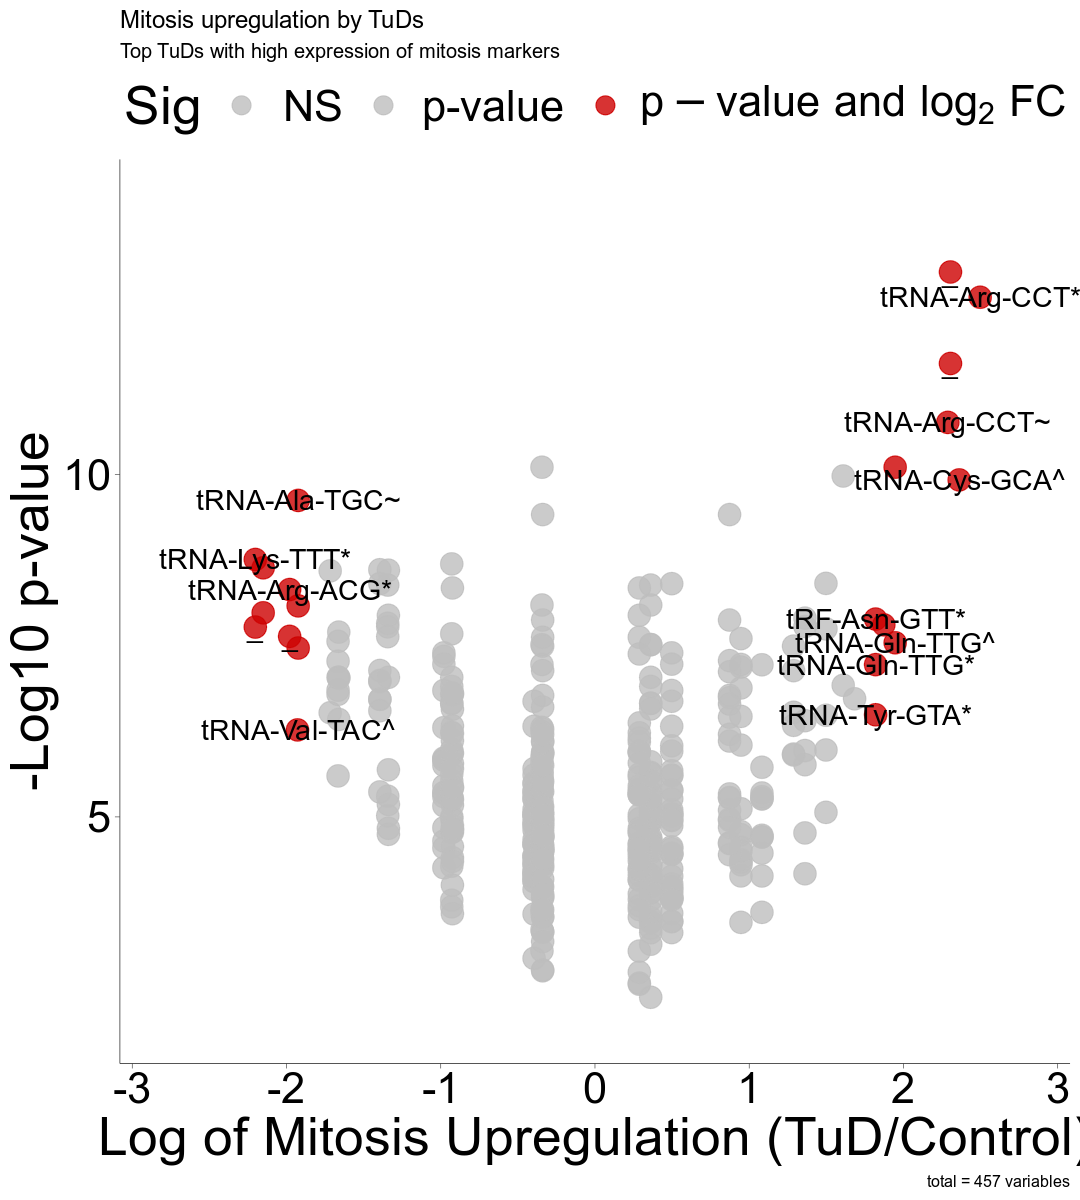

In [57]:
## tRF ##
wfix = 9
hfix = 10
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

## sample 3 sets of 10 seeds of cells for each guide
## for each seed in seed set, calculate the median mitosis seurat score for each guide
## in a given seed set, z-score the median mitosis scores (each guide will have 10 scores at this point)
## pval for a guide in a given seed is caluclated by where they fall along the z-score
## in a given seed set, only keep guides with z-score > 1.28 or < -1.28 (top 10% in each direction)
## in a given seed set, count freq of each guide in this top 10% and bottom 10% of z-scores separately (at this point only have guides with seeds that place them in top 10% or bottom 10%)
## in a given seed set, calculate fold change by dividing freq of guide in top 10% or bottom 10% by mean freq of the randomized guides in top 10% or bottom 10% respectively (this ratio is the number plotted in the volcano plot)
## in a given seed set, remove all guides with fold change < 1 as these are below noise floor
## divide 
## repeat for other two seed sets

## in this way each seed set can have duplicates of the same guides with one of the 10 possible seeds if they fall in the top 10% and the bottom 10% of the seed set
## pvals for each seed set found by multiplying pvals for all 10 seeds in a seed set (so any guide with multiple fold change values in top 10% and bottom 10% in a seed set will have the same pval)

## right now x-axis actually reflects ratio above noise floor, not mitosis upregulation
## make custom volcano plot
## transpose plot (rotate 90 degrees), now make separation on left vs right side based on _down vs _up, y-axis is pval


mitosis_scores_combined_w_pvals = readRDS(paste0(path, 'fig_output/data/fig3/tRF_mitosis_scores_combined_w_pvals.rds'))
mitosis_scores_combined_w_pvals$guide = str_remove(mitosis_scores_combined_w_pvals$guide, '_up')
mitosis_scores_combined_w_pvals$guide = str_remove(mitosis_scores_combined_w_pvals$guide, '_down')
pt1_names = stringr::str_sub(mitosis_scores_combined_w_pvals$guide, end = -3)
pt2_names = stringr::str_sub(mitosis_scores_combined_w_pvals$guide, start = -2)
pt2_names = ifelse(endsWith(pt2_names, '_1'), '*', ifelse(endsWith(pt2_names, '_2'), '^', '~')) ## replaced bootstrapped sample # with symbols for better visualization

mitosis_scores_combined_w_pvals$guide = paste0(condense_tRF_names(pt1_names), pt2_names)
mitosis_scores_combined_w_pvals$guide[grepl('NA-NA', mitosis_scores_combined_w_pvals$guide)] = '_'


keyvals.colour <- ifelse(abs(mitosis_scores_combined_w_pvals$ratio_above_noise_floor) < 1, 'grey60', 'red')
names(keyvals.colour)[keyvals.colour == 'grey60'] <- 'NS'
names(keyvals.colour)[keyvals.colour == 'red'] <- 'significant'
  
volcano_plot = EnhancedVolcano(mitosis_scores_combined_w_pvals,
 lab = mitosis_scores_combined_w_pvals$guide,
 x = 'ratio_above_noise_floor',
 xlab = 'Log of Mitosis Upregulation (TuD/Control)',
 border = 'full',
 y = 'final_pval',
 ylab = '-Log10 p-value',
 pCutoff = 0.00001,
 xlim = c(-2.8, 2.8),
 ylim = c(2, 14),
 col=c('grey', 'grey', 'grey', 'red3'),
 FCcutoff = 1.8, cutoffLineType='blank', pointSize = 6.0, colAlpha = 0.8, labSize = 6,
 title = 'Mitosis upregulation by TuDs', subtitle = 'Top TuDs with high expression of mitosis markers') + theme_pubr() + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), text = element_text(family = "Helvetica"))

volcano_plot$layers[[4]]$aes_params$family <- "Helvetica"
volcano_plot
ggsave(paste0(path, 'fig_output/data/fig3/tRF_mitosis_upregulation.pdf'), width = wfix, height = hfix)

In [6]:
## x-axis is ratio above noise floor for detection of shifts in mitosis (up or down)

mitosis_scores_combined_w_pvals = readRDS(paste0(path, 'fig_output/data/fig3/tRF_mitosis_scores_combined_w_pvals.rds'))

In [10]:
mitosis_scores_combined_w_pvals %>% filter(seed_set == 'seeds_1' & grepl('tRNA-Arg-CCT', guide))

seed_set,guide,Freq,ratio_above_noise_floor,final_pval,final_pval_adjust
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
seeds_1,tRNA-Arg-CCT-3-1.lh_1_down,1,0.6052825,2.586047e-13,6.646140e-11
seeds_1,tRNA-Arg-CCT-3-1.lh_1_up,8,2.4974997,2.586047e-13,6.193582e-11
seeds_1,random_tRNA-Arg-CCT-3-1.lh_1_up,1,-0.5025003,2.105447e-04,2.770630e-04
seeds_1,random_tRNA-Arg-CCT-4-1.rh_1_up,1,-0.5025003,5.980612e-04,6.907308e-04


In [11]:
mitosis_scores_combined_w_pvals %>% filter(seed_set == 'seeds_2' & grepl('tRNA-Ala-TGC', guide))

seed_set,guide,Freq,ratio_above_noise_floor,final_pval,final_pval_adjust
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
seeds_2,tRNA-Ala-TGC-2-1.2t_2_down,4,-1.3436529,1.488312e-08,3.187468e-07
seeds_2,random_tRNA-Ala-TGC-2-1.2t_2_down,1,0.6563471,1.160298e-04,1.565337e-04
seeds_2,tRNA-Ala-TGC-6-1.lh_2_down,1,0.6563471,3.018700e-06,1.107983e-05
seeds_2,tRNA-Ala-TGC-2-1.rh_2_up,4,1.3613995,1.660551e-08,3.458277e-07
seeds_2,tRNA-Ala-TGC-6-1.lh_2_up,2,0.3613995,3.018700e-06,1.215090e-05
seeds_2,random_tRNA-Ala-TGC-2-1.rh_2_up,1,-0.6386005,1.060313e-03,1.175671e-03
seeds_2,tRNA-Ala-TGC-2-1.2t_2_up,1,-0.6386005,1.488312e-08,3.394768e-07


In [5]:
mitosis_scores_combined_w_pvals %>% filter(guide == 'tRNA-Arg-CCT*')

seed_set,guide,Freq,ratio_above_noise_floor,final_pval,final_pval_adjust
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
seeds_1,tRNA-Arg-CCT*,1,0.6052825,2.586047e-13,6.646140e-11
seeds_1,tRNA-Arg-CCT*,8,2.4974997,2.586047e-13,6.193582e-11


In [6]:
mitosis_scores_combined_w_pvals %>% filter(guide == 'tRNA-Ala-TGC^')

seed_set,guide,Freq,ratio_above_noise_floor,final_pval,final_pval_adjust
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
seeds_2,tRNA-Ala-TGC^,4,-1.3436529,1.488312e-08,3.187468e-07
seeds_2,tRNA-Ala-TGC^,1,0.6563471,3.018700e-06,1.107983e-05
seeds_2,tRNA-Ala-TGC^,4,1.3613995,1.660551e-08,3.458277e-07
seeds_2,tRNA-Ala-TGC^,2,0.3613995,3.018700e-06,1.215090e-05
seeds_2,tRNA-Ala-TGC^,1,-0.6386005,1.488312e-08,3.394768e-07


Warning message:
“Removed 3 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 3 rows containing non-finite values (`stat_cor()`).”
Warning message:
“Removed 3 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 3 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 3 rows containing non-finite values (`stat_cor()`).”
Warning message:
“Removed 3 rows containing missing values (`geom_point()`).”


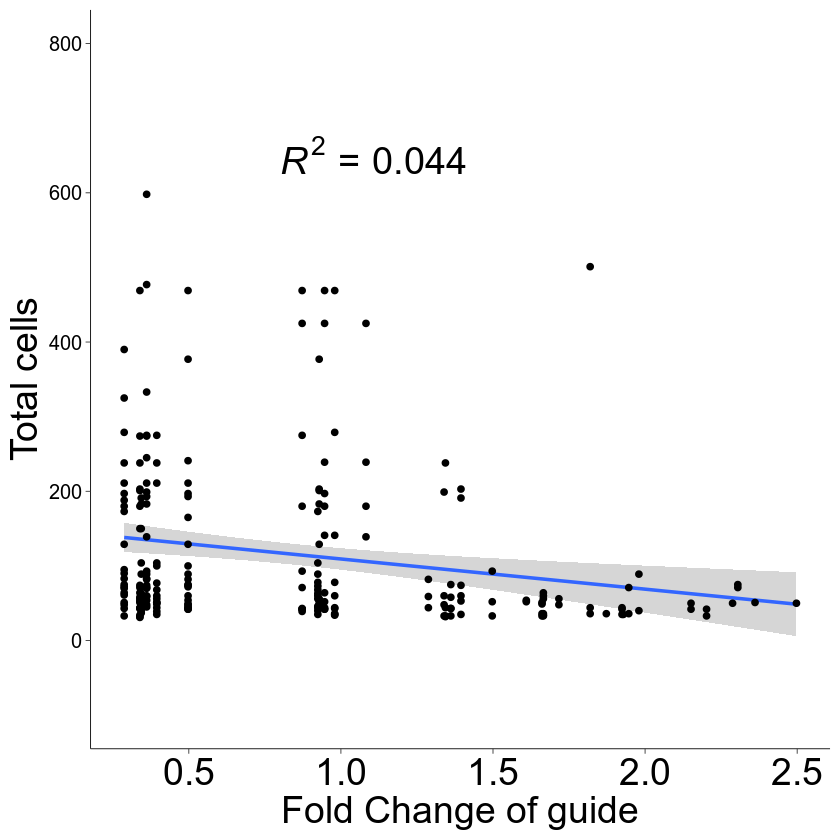

In [15]:
wfix = 7
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

## fold change is not a function of (related to) total cells in a guide
corr_df = readRDS(paste0(path, 'fig_output/data/fig3/tRF_mitosis_fc_total_cells_corr_df.rds'))

ggplot(data = corr_df, aes(x = ratio_above_noise_floor, y = size)) +
    geom_smooth(method = "lm", formula = y ~ x) + geom_point() + xlab('Fold Change of guide') + ylab('Total cells') +
    stat_cor(aes(label = ..rr.label..), label.y = 650, label.x = 0.8, size = 8) + ylim(c(-100, 800)) + theme_pubr() + 
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size/scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig3/tRF_mitosis_fc_total_cells_correlation.pdf'), width = wfix, height = hfix)

### mitosis tRF proliferation assay bargraph ###

[1] 0.0001536664 0.0001725444

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


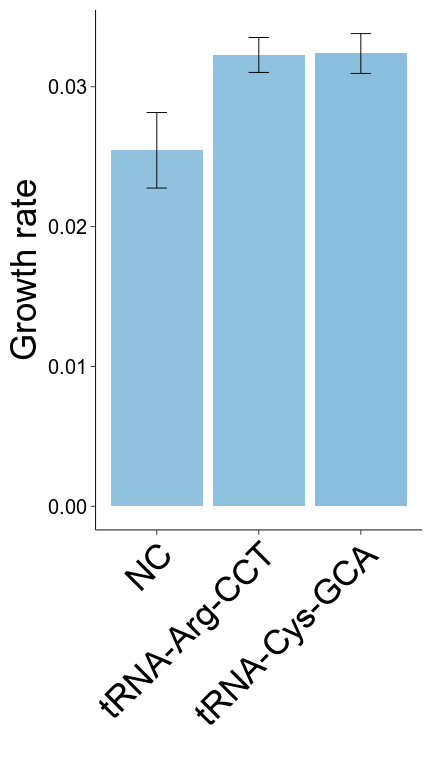

In [18]:
## tRF ##
wfix = 3.6
hfix = 6.5

options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

slopes_df = readRDS(paste0(path, 'fig_output/data/fig3/tRF_slopes_df.rds'))
slopes_df_select = readRDS(paste0(path, 'fig_output/data/fig3/tRF_slopes_df_select.rds'))
Stdevs = sqrt(13)*(slopes_df_select$upper_error * 2)/(2*1.96)
means = slopes_df_select$slope
sd_pooled1 = sqrt(12*(Stdevs[1]^2 + Stdevs[2]^2) / 24)
sd_pooled2 = sqrt(12*(Stdevs[1]^2 + Stdevs[3]^2) / 24)
t1 = (means[2] - means[1])/(sd_pooled1 * sqrt(1/13 + 1/13))
t2 = (means[3] - means[1])/(sd_pooled2 * sqrt(1/13 + 1/13))
df = 24
pval1 = pt(t1, df, lower.tail = FALSE)
pval2 = pt(t2, df, lower.tail = FALSE)
ttest_pvals_adjusted = p.adjust(c(pval1, pval2), method = 'bonferroni')
ttest_pvals_adjusted ## values are boneferroni adjusted

ggplot(data = slopes_df_select, aes(x = guide, y = slope, fill = guide)) + xlab('') +
  geom_bar(stat = "identity", show.legend = FALSE) + scale_fill_manual(values = colorRampPalette(RColorBrewer::brewer.pal(9, "Blues"))(100)[41:(40 + nrow(slopes_df))]) + geom_errorbar(aes(ymin = slope - lower_error, ymax = slope + upper_error), width=.2, size = lnwidth/scale_factor) + ylab('Growth rate') + theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_x_discrete(labels=c("NC", "tRNA-Arg-CCT", "tRNA-Cys-GCA")) + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size/scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig3/tRF_select_proliferation_rate.pdf'), width = wfix, height = hfix)


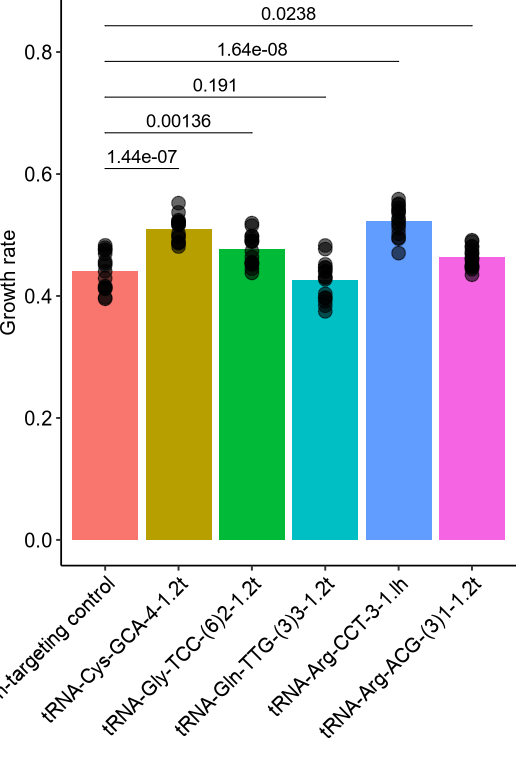

In [ ]:
## tRF ##
wfix = 4.3
hfix = 6.5

options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.25 ## always divide height by height -- much less likely to change to make figure look better

growth_rates_plot_df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig3/prism_benedict_growth_rates_plot_df.rds')
stat.test = growth_rates_plot_df %>% t_test(growth_rate ~ TuD) %>% adjust_pvalue(method = "BH") %>% add_significance("p.adj") %>% filter(group1 == 'Non-targeting control') %>% add_y_position(step.increase = 0.00000001)
stat.test = as.data.frame(stat.test)
stat.test$y.position = stat.test$y.position + 0.05
stat.test$p.adj = signif(stat.test$p.adj, 3)

barplot = growth_rates_plot_df %>% ggplot(aes(TuD, growth_rate)) + stat_summary(aes(fill = TuD), fun.y = 'mean', show.legend = F, geom = 'bar') +
    geom_point(color = 'black', alpha = 0.6, size = 3.5, show.legend = FALSE) + theme_pubr() + stat_pvalue_manual(stat.test, label = 'p.adj', label.y = 0.58, step.increase = 0.25, tip.length = 0) +
    theme(plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('Growth rate') +
    theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

barplot
ggsave(paste0(path, 'fig_output/data/fig3/prism_benedict_tRF_growth_rates_plot.pdf'), width = wfix, height = hfix)

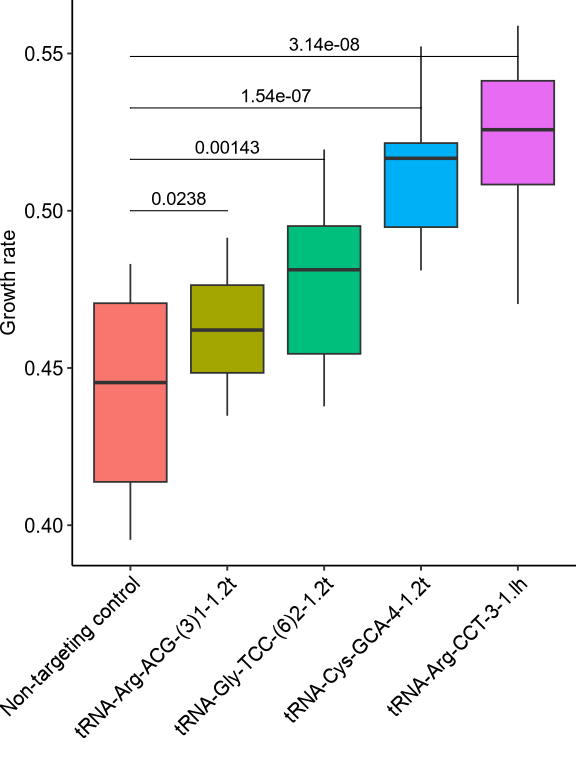

In [18]:
## tRF ##
wfix = 4.8
hfix = 6.5

options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.25 ## always divide height by height -- much less likely to change to make figure look better

growth_rates_plot_df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig3/prism_benedict_growth_rates_plot_df.rds')
growth_rates_plot_df = growth_rates_plot_df %>% filter(TuD != 'tRNA-Gln-TTG-(3)3-1.2t')
growth_rates_plot_df$TuD = as.character(growth_rates_plot_df$TuD)
tud_order = growth_rates_plot_df %>% group_by(TuD) %>% summarize(mean = mean(growth_rate), sd = sd(growth_rate), n = n()) %>% filter(TuD != 'Non-targeting control') %>% arrange(-mean) %>% pull(TuD) %>% as.character()
stat.test = growth_rates_plot_df %>% t_test(growth_rate ~ TuD) %>% adjust_pvalue(method = "BH") %>% add_significance("p.adj") %>% filter(group1 == 'Non-targeting control') %>% add_y_position(step.increase = 0.00000001)
stat.test = as.data.frame(stat.test)
stat.test$y.position = stat.test$y.position + 0.05
stat.test$p.adj = signif(stat.test$p.adj, 3)
stat.test = stat.test %>% arrange(factor(group2, levels = rev(tud_order)))

growth_rates_plot_df$TuD = factor(growth_rates_plot_df$TuD, levels = c('Non-targeting control', rev(tud_order)))

comparison = list(c('Non-targeting control', tud_order[4]), c('Non-targeting control', tud_order[3]), c('Non-targeting control', tud_order[2]), c('Non-targeting control', tud_order[1]))
growth_rates_plot_df %>% ggplot(aes(x = TuD, y = growth_rate)) + xlab('') + geom_boxplot(aes(fill = TuD), show.legend = FALSE) + 
ggpubr::theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + 
scale_fill_discrete() + ylab('Growth rate') + stat_pvalue_manual(stat.test, label = 'p.adj', y.position = 0.5, step.increase = 0.1, tip.length = 0) +
theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig3/prism_benedict_tRF_growth_rates_boxplot.pdf'), width = wfix, height = hfix)

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

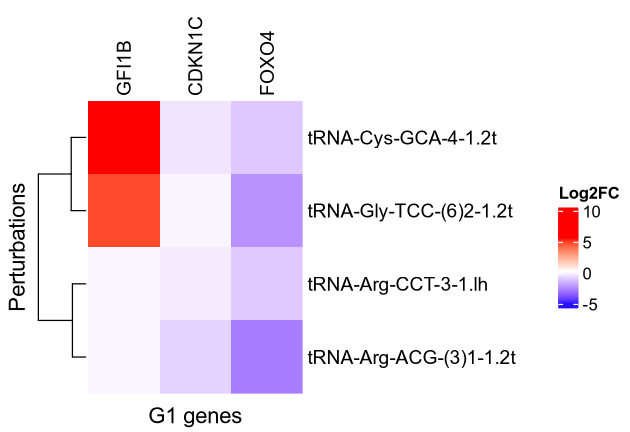

In [28]:
## tRF ##
wfix = 5.25
hfix = 3.6

options(repr.plot.width = wfix, repr.plot.height = hfix)
heatmap_data = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig3/cc_heatmap_data.rds')
heatmap_data = heatmap_data[rownames(heatmap_data) != 'tRNA-Gln-TTG-(3)3-1.2t',]


major_text_size = 8
minor_text_size = 8
lnwidth = 0.694


## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better
heatmap_data = as.matrix(heatmap_data)
avg = mean(heatmap_data)
lower_bound = mean(heatmap_data) - 2*sd(heatmap_data)  ## tried 2 and 5 sd for different effects
upper_bound = mean(heatmap_data) + 2*sd(heatmap_data)

coloring_map <- circlize::colorRamp2(c(lower_bound, avg, upper_bound), c("blue", "white", "red"))

perturb_htmp <- function(matrix, title) {
  draw(Heatmap(matrix, name = title, show_column_names = TRUE, show_row_names = TRUE, show_column_dend = FALSE,
               col = coloring_map, show_row_dend = TRUE, use_raster = TRUE, row_title = 'Perturbations', 
               column_title = 'G1 genes', row_title_side = 'left', column_title_side = 'bottom', show_heatmap_legend = TRUE, column_names_side = "top", column_dend_side = "bottom",
               column_names_gp = gpar(fontfamily = "Helvetica", fontsize = minor_text_size*scale_factor), row_names_gp = gpar(fontfamily = "Helvetica", fontsize = minor_text_size*scale_factor)))
}

perturb_htmp(heatmap_data, 'Log2FC')

pdf(paste0(path, 'fig_output/data/fig3/G1_heatmap.pdf'), width = wfix, height = hfix)
perturb_htmp(heatmap_data, 'Log2FC')
dev.off()

### apoptosis cell % flow cytometry ###

Warning message in geom_bar(stat = "summary", fun.y = "mean", show.legend = FALSE):
“Ignoring unknown parameters: `fun.y`”
Warning message in geom_bar(stat = "summary", fun.y = "mean", show.legend = FALSE):
“Ignoring unknown parameters: `fun.y`”
Warning message in geom_bar(stat = "summary", fun.y = "mean", show.legend = FALSE):
“Ignoring unknown parameters: `fun.y`”
No summary function supplied, defaulting to `mean_se()`
No summary function supplied, defaulting to `mean_se()`
No summary function supplied, defaulting to `mean_se()`


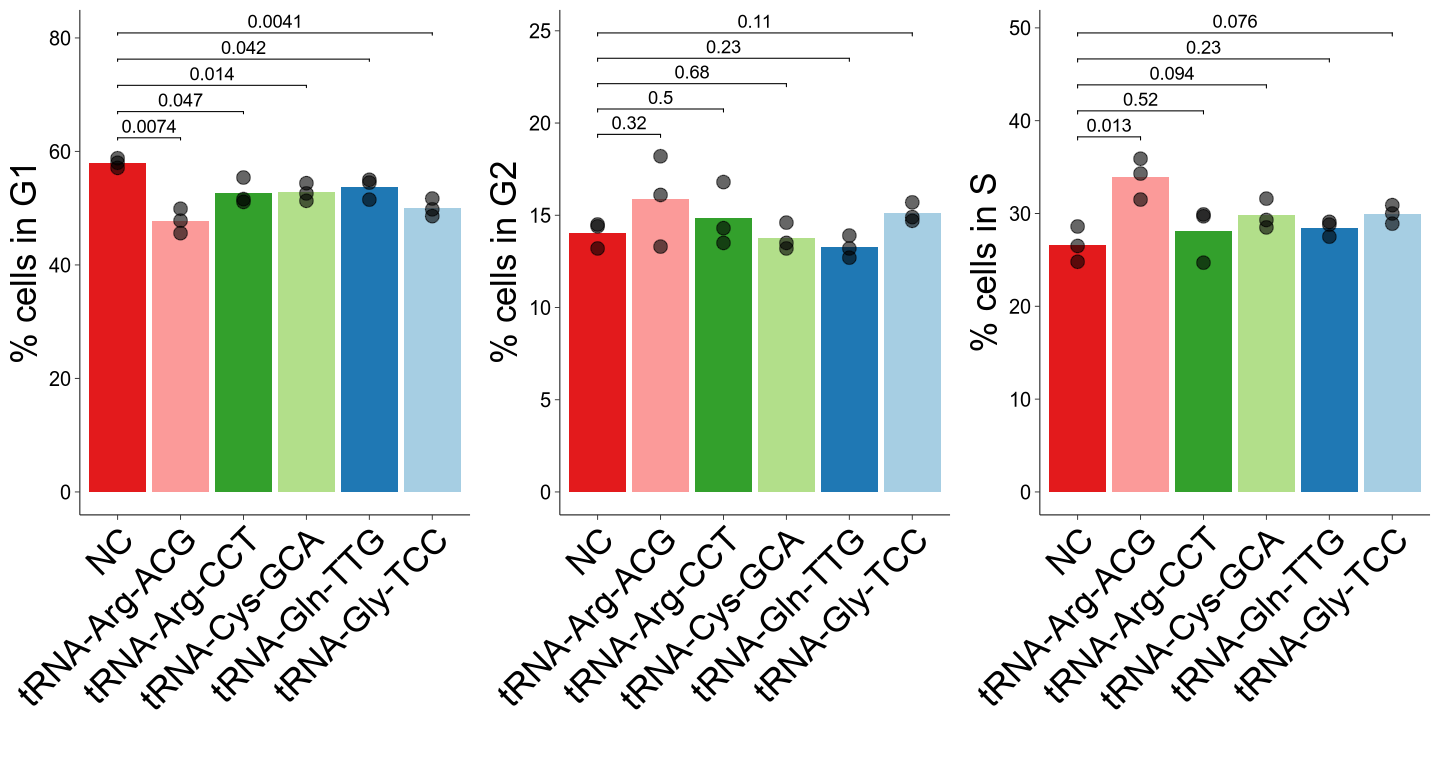

In [4]:
## tRF ##
wfix = 12
hfix = 6.5

options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

cc_flow = readRDS(paste0(path, 'fig_output/data/fig3/tRF_cc_flow.rds'))
cc_flow$sample = plyr::mapvalues(cc_flow$sample, from = unique(cc_flow$sample), to = c('NC', 'tRNA-Arg-CCT', 'tRNA-Arg-ACG', 'tRNA-Gln-TTG', 'tRNA-Gly-TCC', 'tRNA-Cys-GCA'))
samples = cc_flow %>% pull(sample) %>% unique() %>% sort()
G1_ttests = sapply(samples[-1], FUN = function(x) cc_flow %>% filter(cellcycle == 'G1' & sample %in% c('NC', x)) %>% t.test(pct_cells ~ sample, .) %>% magrittr::use_series('p.value') %>% signif(6))
G2_ttests = sapply(samples[-1], FUN = function(x) cc_flow %>% filter(cellcycle == 'G2' & sample %in% c('NC', x)) %>% t.test(pct_cells ~ sample, .) %>% magrittr::use_series('p.value') %>% signif(6))
S_ttests = sapply(samples[-1], FUN = function(x) cc_flow %>% filter(cellcycle == 'S' & sample %in% c('NC', x)) %>% t.test(pct_cells ~ sample, .) %>% magrittr::use_series('p.value') %>% signif(6))

samples = cc_flow %>% pull(sample) %>% unique() %>% sort()
my_comparisons = list(c(samples[1], samples[2]), c(samples[1], samples[3]), c(samples[1], samples[4]), c(samples[1], samples[5]), c(samples[1], samples[6]))

upper_lim = max(cc_flow %>% filter(cellcycle == 'G1') %>% pull(pct_cells))*1.05
G1_flow = cc_flow %>% filter(cellcycle == 'G1') %>% ggplot(aes(sample, pct_cells, fill = sample)) + geom_bar(stat = 'summary', fun.y = 'mean', show.legend = FALSE) +
geom_point(color = 'black', alpha = 0.6, size = 3.5, show.legend = FALSE) + #stat_compare_means(method = "t.test", comparisons = my_comparisons, label.y = upper_lim, step.increase = 0.35) + 
theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('% cells in G1') + scale_fill_brewer(palette = 'Paired', direction = -1) + scale_color_brewer(palette = 'Paired', direction = -1) +
theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size/scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

upper_lim = max(cc_flow %>% filter(cellcycle == 'G2') %>% pull(pct_cells))*1.05
G2_flow = cc_flow %>% filter(cellcycle == 'G2') %>% ggplot(aes(sample, pct_cells, fill = sample)) + geom_bar(stat = 'summary', fun.y = 'mean', show.legend = FALSE) +
geom_point(color = 'black', alpha = 0.6, size = 3.5, show.legend = FALSE) + #stat_compare_means(method = "t.test", comparisons = my_comparisons, label.y = upper_lim, step.increase = 0.25) + 
theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('% cells in G2') + scale_fill_brewer(palette = 'Paired', direction = -1) + scale_color_brewer(palette = 'Paired', direction = -1) +
theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size/scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

upper_lim = max(cc_flow %>% filter(cellcycle == 'S') %>% pull(pct_cells))*1.05
S_flow = cc_flow %>% filter(cellcycle == 'S') %>% ggplot(aes(sample, pct_cells, fill = sample)) + geom_bar(stat = 'summary', fun.y = 'mean', show.legend = FALSE) +
geom_point(color = 'black', alpha = 0.6, size = 3.5, show.legend = FALSE) + #stat_compare_means(method = "t.test", comparisons = my_comparisons, label.y = upper_lim, step.increase = 0.25) + 
theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('% cells in S') + scale_fill_brewer(palette = 'Paired', direction = -1) + scale_color_brewer(palette = 'Paired', direction = -1) +
theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size/scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

ggarrange(G1_flow, G2_flow, S_flow, ncol = 3, nrow = 1)

ggsave(paste0(path, 'fig_output/data/fig3/tRF_cc_flow.pdf'), width = wfix, height = hfix)



In [73]:
G1_ttests

tRNA-Arg-ACG tRNA-Arg-CCT tRNA-Cys-GCA tRNA-Gln-TTG tRNA-Gly-TCC 
  0.00744349   0.04739760   0.01366320   0.04199790   0.00407071

In [75]:
G2_ttests

tRNA-Arg-ACG tRNA-Arg-CCT tRNA-Cys-GCA tRNA-Gln-TTG tRNA-Gly-TCC 
    0.324939     0.501818     0.677877     0.233487     0.114683

In [74]:
S_ttests

tRNA-Arg-ACG tRNA-Arg-CCT tRNA-Cys-GCA tRNA-Gln-TTG tRNA-Gly-TCC 
   0.0133599    0.5153040    0.0944878    0.2324790    0.0757460

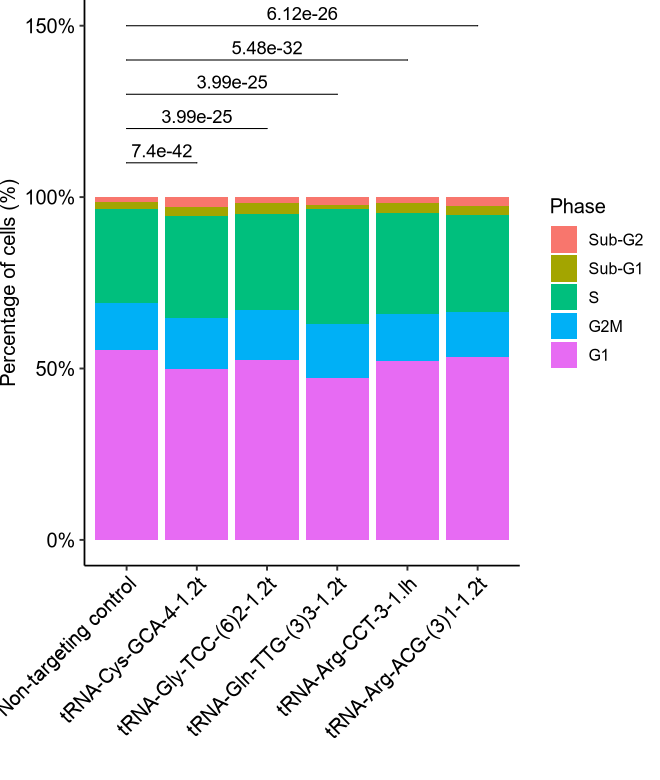

In [35]:
## tRF ##
wfix = 5.5
hfix = 6.5

options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.3 ## always divide height by height -- much less likely to change to make figure look better

flowjo_adjusted_cell_count_chisq = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig3/flowjo_benedict_adjusted_cell_count_chisq.rds')
cell_pcts_plot_df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig3/flojo_benedict_cell_pcts_plot_df.rds') 

cell_pcts_plot_df$Phase = factor(cell_pcts_plot_df$Phase, levels = rev(c('G1', 'G2M', 'S', 'Sub-G1', 'Sub-G2')))

pvals = vector()
for(i in 1:length(colnames(flowjo_adjusted_cell_count_chisq)[-1])){
    pvals[i] = chisq_test(as.numeric(flowjo_adjusted_cell_count_chisq[,c(1,i)]))$p
}
pvals = p.adjust(pvals, method = 'BH')

stat.test = tibble(
  group1 = rep(colnames(flowjo_adjusted_cell_count_chisq)[1], 5),
  group2 = colnames(flowjo_adjusted_cell_count_chisq)[-1],
  p.adj = signif(pvals, 3),
  y.position = seq(1.1, 1.5, length.out = 5)
)

ggplot(cell_pcts_plot_df, aes(fill = Phase, y = pct, x = TuD)) + 
    geom_bar(position = "fill", stat = "identity", show.legend = T) + scale_y_continuous(labels = scales::percent_format(accuracy = 1)) + theme_pubr() + stat_pvalue_manual(stat.test, label = 'p.adj', tip.length = 0, inherit.aes = F) +
    theme(legend.position = "right", axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('Percentage of cells (%)') +
    theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig3/flowjo_benedict_tRF_cc_flow_plot.pdf'), width = wfix, height = hfix)

`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.


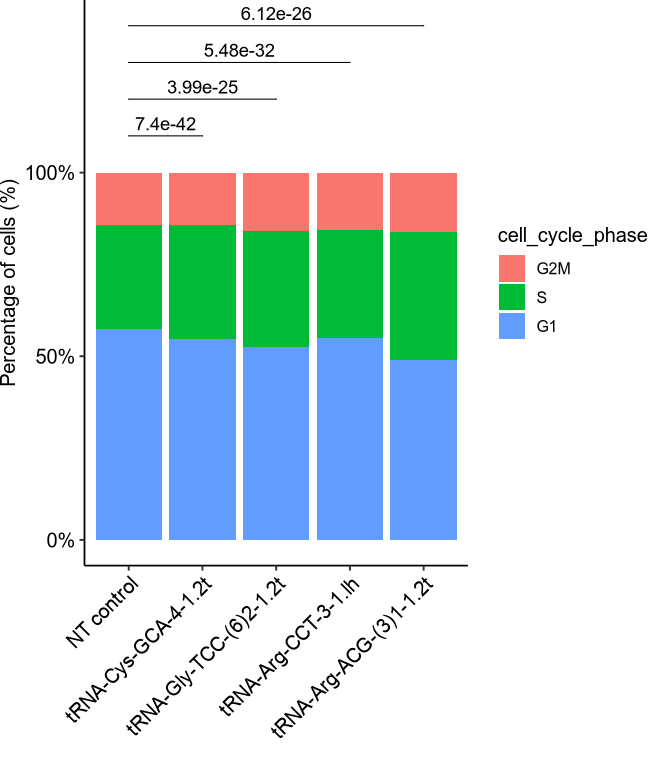

In [54]:
## tRF ##
wfix = 5.5
hfix = 6.5

## get stat test by running graph above !!!! ### These are not real values as the real test performed in prism, so pvals corrected in illustrator
stat.test$group1 = 'NT control'
stat.test$y.position[c(4,5)] = c(1.3, 1.4)

options(repr.plot.width = wfix, repr.plot.height = hfix)
flowjo_adjusted_cell_count_chisq = read.csv('/home/ssobti/projects/mir_tud/wetlab_followup_data/cellcycle/041724_tRF_chi_sq_cellcycle_flowjo_cell_counts_refined_benedict.csv', header = T)
colnames(flowjo_adjusted_cell_count_chisq)[1] = 'sample'
flow_jo_plot_df = flowjo_adjusted_cell_count_chisq %>% pivot_longer(cols = -sample, names_to = "cell_cycle_phase", values_to = "cell_count") %>% filter(!is.na(cell_count)) %>% mutate(cell_cycle_phase = sapply(stringr::str_split(cell_cycle_phase, "\\.", simplify = F), '[[', 1)) %>% group_by(sample, cell_cycle_phase) %>% summarise(mean_cell_count = mean(cell_count))
flow_jo_plot_df$cell_cycle_phase = factor(flow_jo_plot_df$cell_cycle_phase, levels = rev(c('G1', 'S', 'G2M')))
flow_jo_plot_df$sample = factor(flow_jo_plot_df$sample, levels = unique(flow_jo_plot_df$sample)[c(1,4,5,3,2)])

ggplot(flow_jo_plot_df, aes(fill = cell_cycle_phase, y = mean_cell_count, x = sample)) + 
    geom_bar(position = "fill", stat = "identity", show.legend = T) + scale_y_continuous(labels = scales::percent_format(accuracy = 1)) + theme_pubr() + stat_pvalue_manual(stat.test[-3,], label = 'p.adj', tip.length = 0, inherit.aes = F) +
    theme(legend.position = "right", axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('Percentage of cells (%)') + 
    theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig3/flowjo_benedict_tRF_cc_flow_plot_refined.pdf'), width = wfix, height = hfix)

### apoptosis cell % flow cytometry ###

tRNA-Arg-CCT tRNA-Cys-GCA 
   0.0252515    0.0492524

Warning message in geom_bar(stat = "summary", fun.y = "mean", show.legend = FALSE):
“Ignoring unknown parameters: `fun.y`”
No summary function supplied, defaulting to `mean_se()`
No summary function supplied, defaulting to `mean_se()`


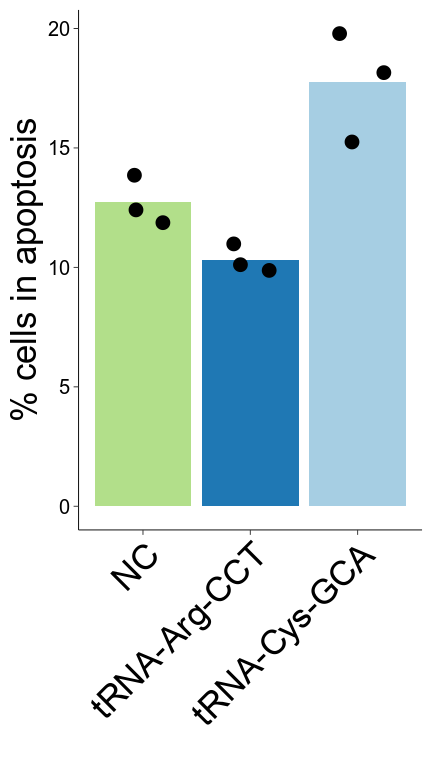

In [52]:
## tRF ##
wfix = 3.6
hfix = 6.5

options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

apop_flow = readRDS(paste0(path, 'fig_output/data/fig3/tRF_apop_flow.rds'))
apop_flow$sample = plyr::mapvalues(apop_flow$sample, from = c('Non-targeting TuD', 'tRNA-Arg-CCT-3-1.lh', 'tRNA-Cys-GCA-4-1.2t'), to = c('NC', 'tRNA-Arg-CCT', 'tRNA-Cys-GCA'))

samples = apop_flow %>% pull(sample) %>% unique() %>% sort()
my_comparisons = list(c(samples[1], samples[2]), c(samples[1], samples[3]))
upper_lim = max(apop_flow %>% pull(pct_cells))*1.05

samples = apop_flow %>% pull(sample) %>% unique() %>% sort()
ttests = sapply(samples[-1], FUN = function(x) apop_flow %>% filter(sample %in% c('NC', x)) %>% t.test(pct_cells ~ sample, .) %>% magrittr::use_series('p.value') %>% signif(6))
ttests

set.seed(1)
apop_flow %>% ggplot(aes(sample, pct_cells, fill = sample)) + geom_bar(stat = 'summary', fun.y = 'mean', show.legend = FALSE) +
geom_jitter(width = 0.25, size = 3.5, show.legend = FALSE) + #stat_compare_means(method = "t.test", comparisons = my_comparisons, label.y = upper_lim, step.increase = 0.15) +
theme_pubr() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('% cells in apoptosis') + scale_fill_brewer(palette = 'Paired', direction = -1) + scale_color_brewer(palette = 'Paired', direction = -1) +
theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size/scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig3/tRF_apop_flow.pdf'), width = wfix, height = hfix)

### supplemental S/G2M cell cycle frequency plot ###

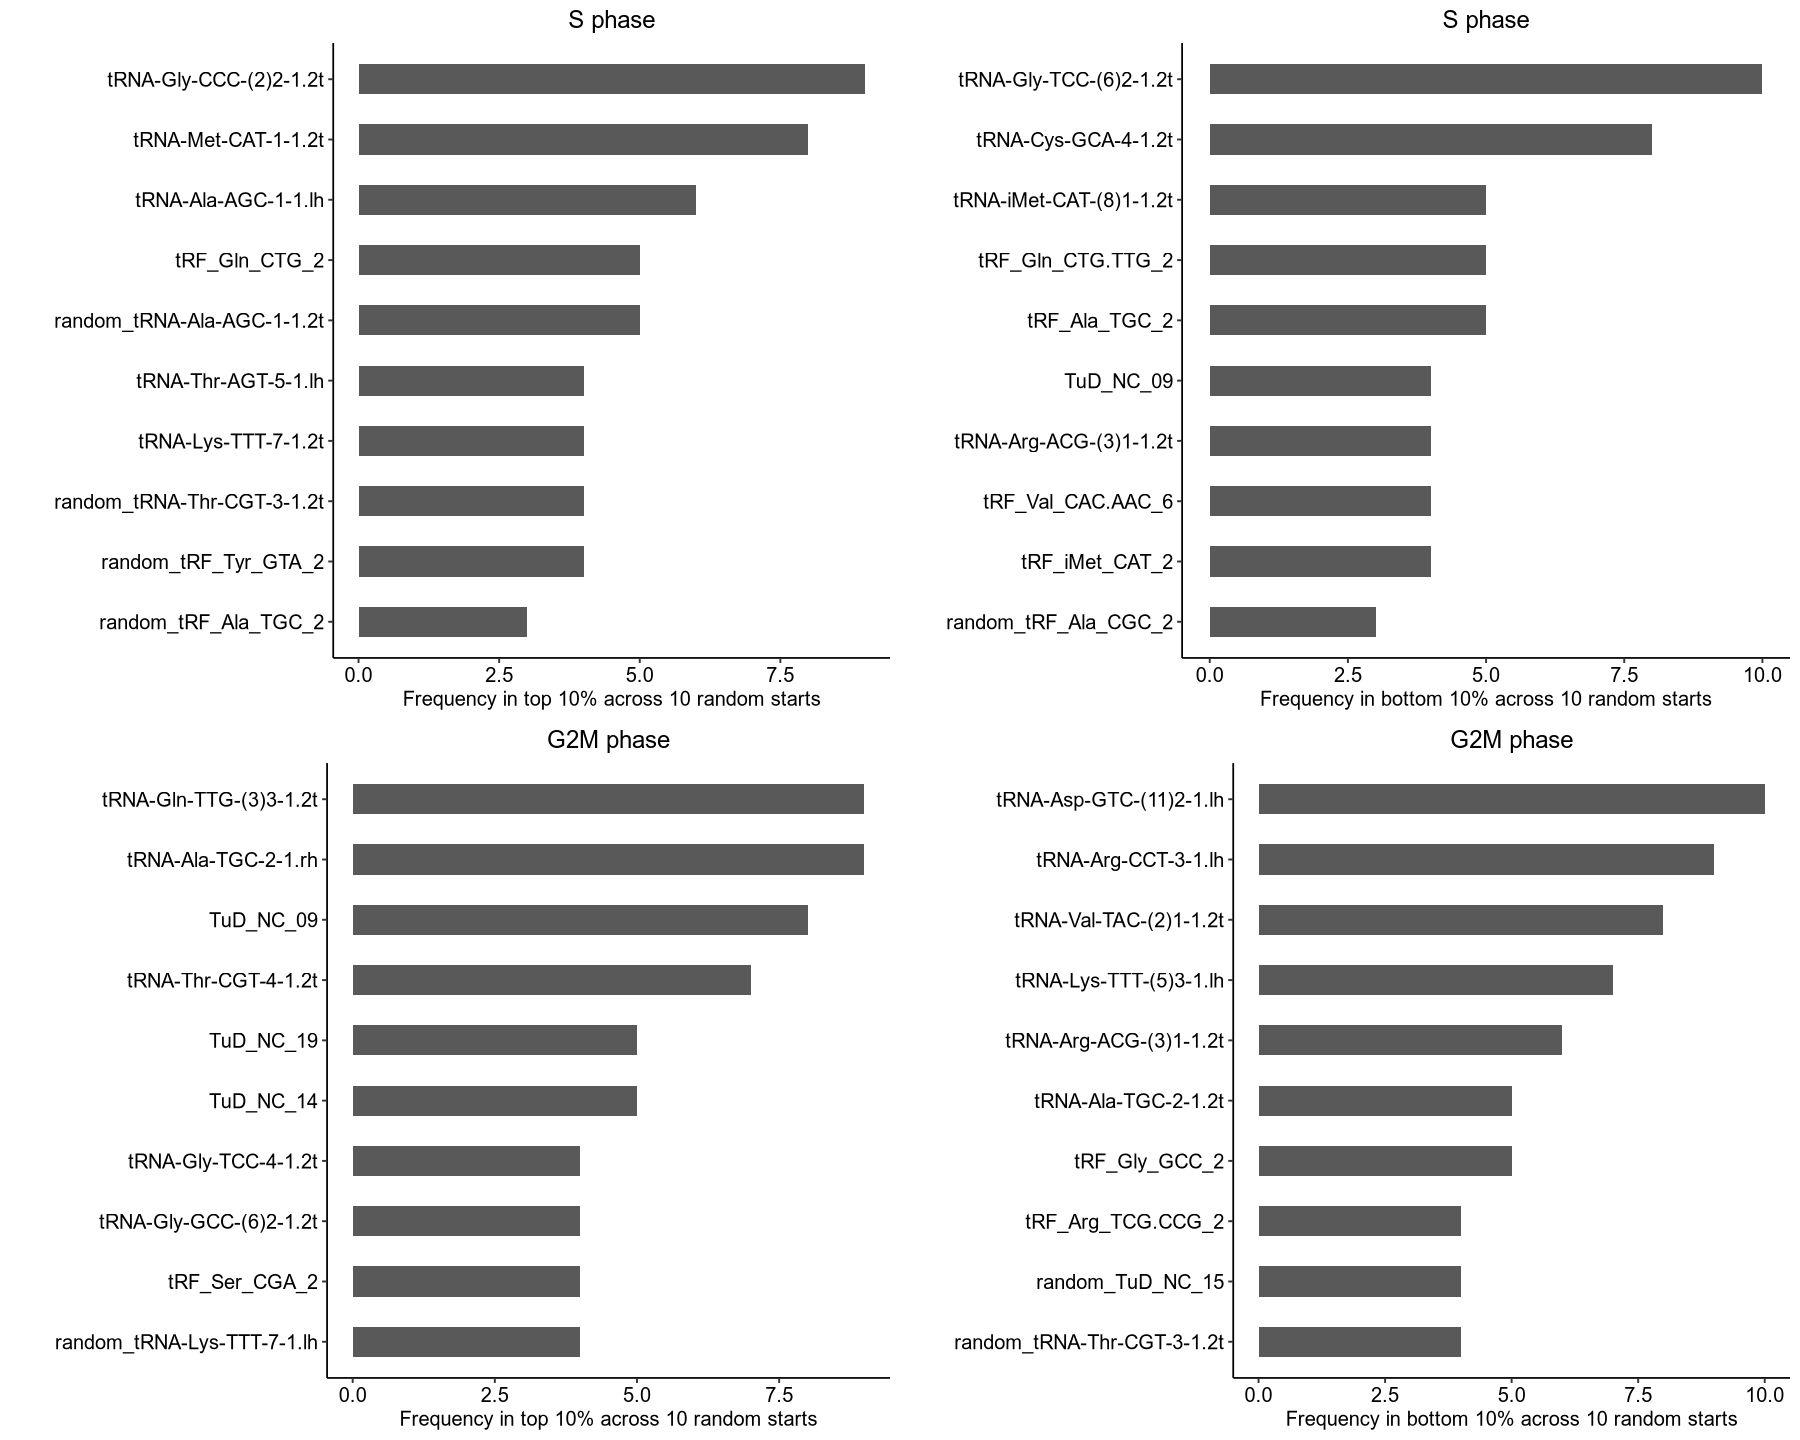

In [10]:
## tRF ## 
wfix = 15
hfix = 12
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

s_scores_top_guides = read.csv('/home/ssobti/projects/mir_tud/output_data/cellcycle/tRF/s_scores_top_guides.csv')
s_scores_bottom_guides = read.csv('/home/ssobti/projects/mir_tud/output_data/cellcycle/tRF/s_scores_bottom_guides.csv')
g2m_scores_top_guides = read.csv('/home/ssobti/projects/mir_tud/output_data/cellcycle/tRF/g2m_scores_top_guides.csv')
g2m_scores_bottom_guides = read.csv('/home/ssobti/projects/mir_tud/output_data/cellcycle/tRF/g2m_scores_bottom_guides.csv')
s_scores_df_list_combined = read.csv('/home/ssobti/projects/mir_tud/output_data/cellcycle/tRF/s_scores_df_list_combined.csv')
g2m_scores_df_list_combined = read.csv('/home/ssobti/projects/mir_tud/output_data/cellcycle/tRF/g2m_scores_df_list_combined.csv')

plot1 = ggplot(data = s_scores_top_guides, aes(x = reorder(s_scores_top_guides, Freq.in.top.10..across.10.random.starts), y = Freq.in.top.10..across.10.random.starts)) +
  geom_bar(stat = "identity", width = 0.5) + coord_flip() + ylab('Frequency in top 10% across 10 random starts') + xlab('') + ggtitle('S phase') + theme_pubr() + theme(plot.title = element_text(hjust = 0.5)) +
  theme(axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

plot2 = ggplot(data = s_scores_bottom_guides, aes(x = reorder(s_scores_bottom_guides, Freq.in.bottom.10..across.10.random.starts), y = Freq.in.bottom.10..across.10.random.starts)) +
  geom_bar(stat = "identity", width = 0.5) + coord_flip() + ylab('Frequency in bottom 10% across 10 random starts') + xlab('') + ggtitle('S phase') + theme_pubr() + theme(plot.title = element_text(hjust = 0.5)) +
  theme(axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

plot3 = ggplot(data = g2m_scores_top_guides, aes(x = reorder(g2m_scores_top_guides, Freq.in.top.10..across.10.random.starts), y = Freq.in.top.10..across.10.random.starts)) +
  geom_bar(stat = "identity", width = 0.5) + coord_flip() + ylab('Frequency in top 10% across 10 random starts') + xlab('') + ggtitle('G2M phase') + theme_pubr() + theme(plot.title = element_text(hjust = 0.5)) +
  theme(axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

plot4 = ggplot(data = g2m_scores_bottom_guides, aes(x = reorder(g2m_scores_bottom_guides, Freq.in.bottom.10..across.10.random.starts), y = Freq.in.bottom.10..across.10.random.starts)) +
  geom_bar(stat = "identity", width = 0.5) + coord_flip() + ylab('Frequency in bottom 10% across 10 random starts') + xlab('') + ggtitle('G2M phase') + theme_pubr() + theme(plot.title = element_text(hjust = 0.5)) +
  theme(axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))


ggarrange(plot1, plot2, plot3, plot4, ncol = 2, nrow = 2)
ggsave(paste0(path, 'fig_output/data/fig3/tRF_s_g2m_phase_freq.pdf'), width = wfix, height = hfix)

### supplemental S/G2M cell cycle dot/violinplot ###

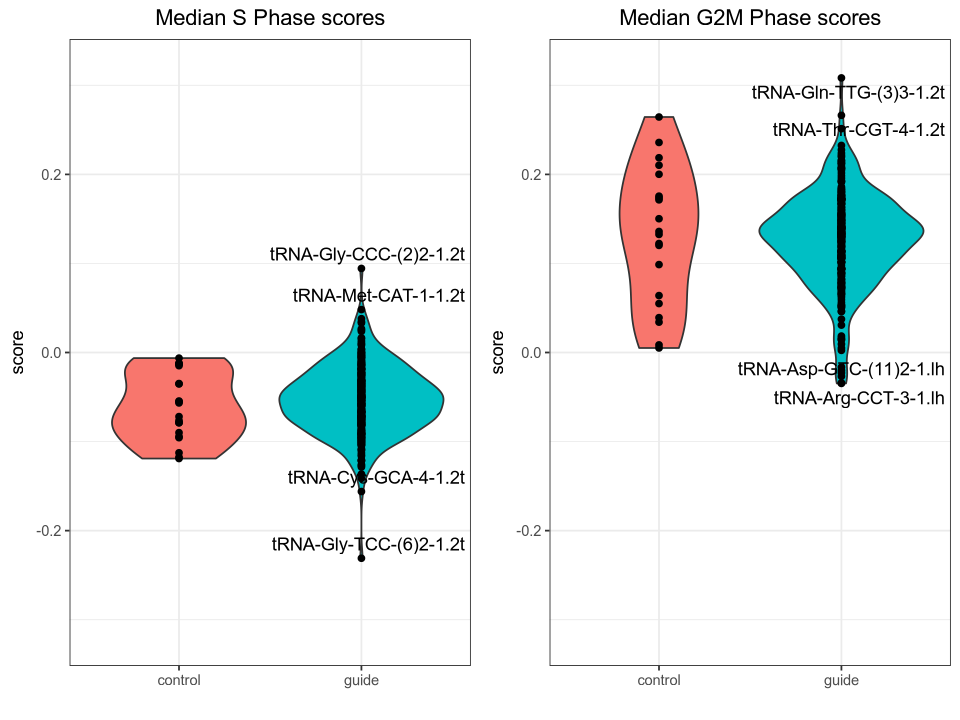

In [72]:
## tRF ## 
wfix = 8
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

s_scores_by_seed = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig3/tRF_s_scores_by_seed.rds')
g2m_scores_by_seed = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig3/tRF_g2m_scores_by_seed.rds')

options(repr.plot.width = 17, repr.plot.height = 8)
s_phase = ggplot(s_scores_by_seed, aes(x = type, y = score, fill = type)) + xlab('') +
    geom_violin(trim=TRUE, show.legend = FALSE) + geom_point(show.legend = FALSE) + geom_text_repel(data = subset(s_scores_by_seed, guide %in% c('tRNA-Gly-CCC-(2)2-1.2t', 'tRNA-Met-CAT-1-1.2t', 'tRNA-Cys-GCA-4-1.2t', 'tRNA-Gly-TCC-(6)2-1.2t')), aes(label=guide), nudge_x = 0.2) + ggtitle('Median S Phase scores') + theme_bw() + theme(plot.title = element_text(hjust = 0.5)) + ylim(-0.32,0.32)


g2m_phase = ggplot(g2m_scores_by_seed, aes(x = type, y = score, fill = type)) + xlab('') +
    geom_violin(trim=TRUE, show.legend = FALSE) + geom_point(show.legend = FALSE) + geom_text_repel(data = subset(g2m_scores_by_seed, guide %in% c('tRNA-Gln-TTG-(3)3-1.2t', 'tRNA-Thr-CGT-4-1.2t', 'tRNA-Arg-CCT-3-1.lh', 'tRNA-Asp-GTC-(11)2-1.lh')), aes(label=guide), nudge_x = 0.2) + ggtitle('Median G2M Phase scores') + theme_bw() + theme(plot.title = element_text(hjust = 0.5)) + ylim(-0.32,0.32)

options(repr.plot.width = wfix, repr.plot.height = hfix)
ggarrange(s_phase, g2m_phase, ncol = 2)
ggsave(paste0(path, 'fig_output/data/fig3/tRF_s_g2m_phase_scores.pdf'), width = wfix, height = hfix)

### supplemental fig UMAP of cell cycle genes of bulk RNA seq cell cycle followup tRFs ###

In [8]:
dim(adata.R)

[1] 2000  211

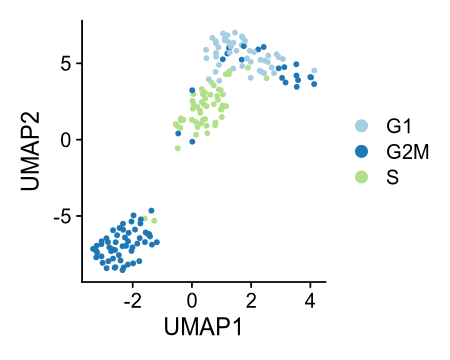

In [9]:
wfix = 3.75
hfix = 3
options(repr.plot.width = wfix, repr.plot.height = hfix)

## Plotted data for submission purposes
#cc_umap_df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig3/cc_umap_df.rds')

## load data
adata.R = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig3/cc_adata_R.rds')
meta = adata.R@meta.data
adata.R = adata.R[,meta$guide != 'tRNA-Gln-TTG-(3)3-1.2t']

DimPlot(adata.R, reduction = 'umap') + theme(plot.title = element_blank()) + xlab('UMAP1') + ylab('UMAP2') + scale_color_brewer(palette = "Paired") + 
theme(margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))
ggsave(paste0(path, 'fig_output/data/fig3/tRF_cc_umap_cycle_labels.pdf'), width = wfix, height = hfix)

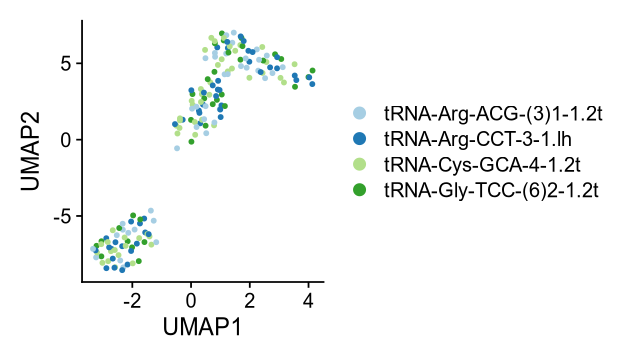

In [10]:
wfix = 5.35
hfix = 3
options(repr.plot.width = wfix, repr.plot.height = hfix)

## Plotted data for submission purposes
#cc_umap_df = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig3/cc_umap_df.rds')

## load data
adata.R = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig3/cc_adata_R.rds')
meta = adata.R@meta.data
adata.R = adata.R[,meta$guide != 'tRNA-Gln-TTG-(3)3-1.2t']

DimPlot(adata.R, reduction = 'umap', group.by = 'guide') + scale_color_brewer(palette = "Paired") + theme(plot.title = element_blank()) + xlab('UMAP1') + ylab('UMAP2') +
theme(margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))
ggsave(paste0(path, 'fig_output/data/fig3/tRF_cc_umap_sample_id.pdf'), width = wfix, height = hfix)

### supplemental fig cell cycle top perturbing guides compared to top control guides boxplots ###

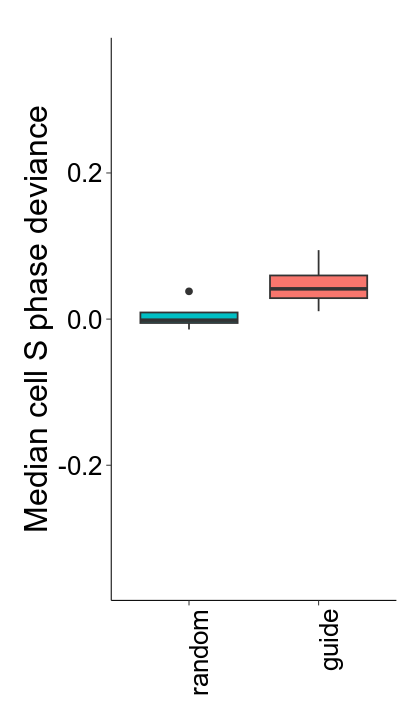

In [15]:
## tRF S phase increasing guides
wfix = 3.5
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

select_random_guides_medians_scores_combined = readRDS(paste0(path, 'fig_output/data/fig3/tRF_select_random_guides_medians_scores_combined.rds'))
## original y axis label: 'Median z-score of top guides'
select_random_guides_medians_scores_combined_graphing = select_random_guides_medians_scores_combined[[1]]
select_random_guides_medians_scores_combined_graphing$group = factor(select_random_guides_medians_scores_combined_graphing$group, levels = c('random', 'guide'))

ggplot(select_random_guides_medians_scores_combined_graphing, aes(x = group, y = median_score, fill = group)) + 
    geom_boxplot() + theme_pubr() + theme(axis.text.x = element_text(angle = 90, hjust = 1), plot.title = element_text(hjust = 0.5, margin = margin(0,0,12,0)), plot.margin = unit(c(0.8, 0.5, 0.5, 0.5), 'cm'), 
    axis.title.x = element_blank(), legend.position = 'none') + scale_fill_hue(direction = -1) + ylab('Median cell S phase deviance') + coord_cartesian(clip = 'off') + ylim(-0.35, 0.35) +
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig3/tRF_select_guides_s_phase_increasing_z_score_medians_boxplot.pdf'), width = wfix, height = hfix)

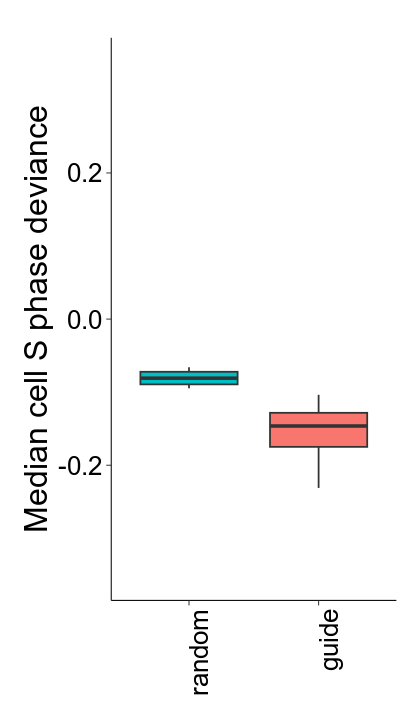

In [16]:
## tRF S phase decreasing guides
wfix = 3.5
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

select_random_guides_medians_scores_combined = readRDS(paste0(path, 'fig_output/data/fig3/tRF_select_random_guides_medians_scores_combined.rds'))
## original y axis label: 'Median z-score of top guides'
select_random_guides_medians_scores_combined_graphing = select_random_guides_medians_scores_combined[[2]]
select_random_guides_medians_scores_combined_graphing$group = factor(select_random_guides_medians_scores_combined_graphing$group, levels = c('random', 'guide'))

ggplot(select_random_guides_medians_scores_combined_graphing, aes(x = group, y = median_score, fill = group)) + 
    geom_boxplot() + theme_pubr() + theme(axis.text.x = element_text(angle = 90, hjust = 1), plot.title = element_text(hjust = 0.5, margin = margin(0,0,12,0)), plot.margin = unit(c(0.8, 0.5, 0.5, 0.5), 'cm'), 
    axis.title.x = element_blank(), legend.position = 'none') + scale_fill_hue(direction = -1) + ylab('Median cell S phase deviance') + coord_cartesian(clip = 'off') + ylim(-0.35, 0.35) +
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig3/tRF_select_guides_s_phase_decreasing_z_score_medians_boxplot.pdf'), width = wfix, height = hfix)

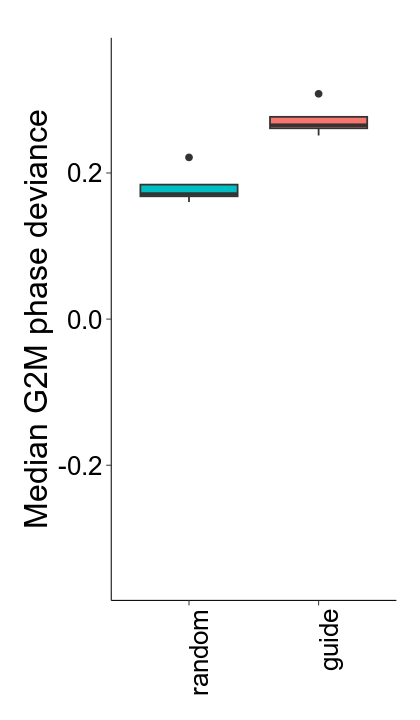

In [17]:
## tRF G2M phase increasing guides
wfix = 3.5
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

select_random_guides_medians_scores_combined = readRDS(paste0(path, 'fig_output/data/fig3/tRF_select_random_guides_medians_scores_combined.rds'))
## original y axis label: 'Median z-score of top guides'
select_random_guides_medians_scores_combined_graphing = select_random_guides_medians_scores_combined[[3]]
select_random_guides_medians_scores_combined_graphing$group = factor(select_random_guides_medians_scores_combined_graphing$group, levels = c('random', 'guide'))

ggplot(select_random_guides_medians_scores_combined_graphing, aes(x = group, y = median_score, fill = group)) + 
    geom_boxplot() + theme_pubr() + theme(axis.text.x = element_text(angle = 90, hjust = 1), plot.title = element_text(hjust = 0.5, margin = margin(0,0,12,0)), plot.margin = unit(c(0.8, 0.5, 0.5, 0.5), 'cm'), 
    axis.title.x = element_blank(), legend.position = 'none') + scale_fill_hue(direction = -1) + ylab('Median G2M phase deviance') + coord_cartesian(clip = 'off') + ylim(-0.35, 0.35) +
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig3/tRF_select_guides_g2m_phase_increasing_z_score_medians_boxplot.pdf'), width = wfix, height = hfix)

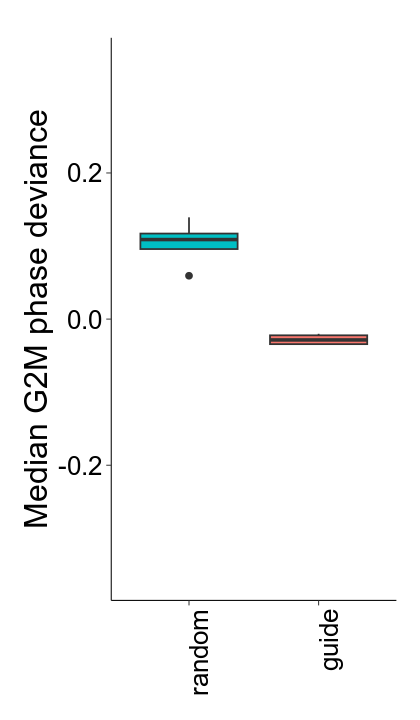

In [18]:
## tRF G2M phase decreasing guides
wfix = 3.5
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

select_random_guides_medians_scores_combined = readRDS(paste0(path, 'fig_output/data/fig3/tRF_select_random_guides_medians_scores_combined.rds'))
## original y axis label: 'Median z-score of top guides'
select_random_guides_medians_scores_combined_graphing = select_random_guides_medians_scores_combined[[4]]
select_random_guides_medians_scores_combined_graphing$group = factor(select_random_guides_medians_scores_combined_graphing$group, levels = c('random', 'guide'))

ggplot(select_random_guides_medians_scores_combined_graphing, aes(x = group, y = median_score, fill = group)) + 
    geom_boxplot() + theme_pubr() + theme(axis.text.x = element_text(angle = 90, hjust = 1), plot.title = element_text(hjust = 0.5, margin = margin(0,0,12,0)), plot.margin = unit(c(0.8, 0.5, 0.5, 0.5), 'cm'), 
    axis.title.x = element_blank(), legend.position = 'none') + scale_fill_hue(direction = -1) + ylab('Median G2M phase deviance') + coord_cartesian(clip = 'off') + ylim(-0.35, 0.35) +
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig3/tRF_select_guides_g2m_phase_decreasing_z_score_medians_boxplot.pdf'), width = wfix, height = hfix)

### supplemental fig CV/heterogeneity top perturbing guides compared to top control guides boxplots ###

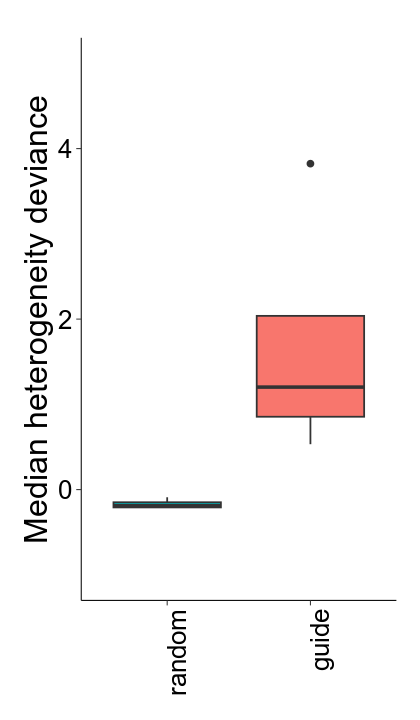

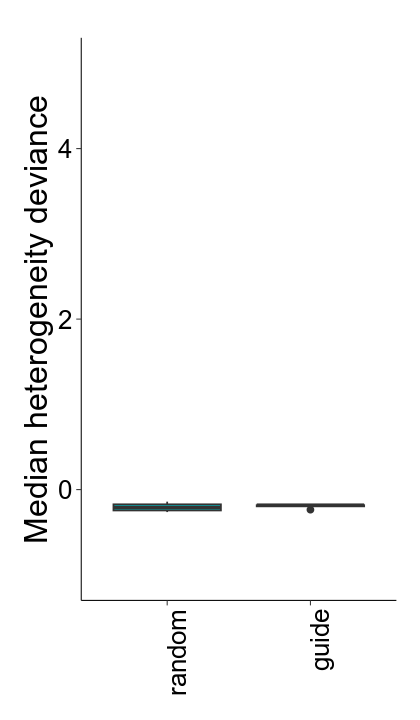

In [19]:
## tRF ##
wfix = 3.5
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

top_guides_medians_increasing_CV = readRDS(paste0(path, 'fig_output/data/fig3/tRF_select_top_guides_medians_increasing_CV.rds'))
top_guides_medians_decreasing_CV = readRDS(paste0(path, 'fig_output/data/fig3/tRF_select_top_guides_medians_decreasing_CV.rds'))

## median z-scores of top guides (4) above first randomized guide and top 4 randomized guides
## increasing CV
## original y axis label: 'Median z-score of top guides'
select_guides_increasing_CV_z_score_medians = ggplot(top_guides_medians_increasing_CV, aes(x = group, y = median_z_score_increasing_genes, fill = group)) +
  geom_boxplot() + theme_pubr() + theme(axis.text.x = element_text(angle = 90, hjust = 1), plot.title = element_text(hjust = 0.5, margin = margin(0,0,12,0)), plot.margin = unit(c(0.8, 0.5, 0.5, 0.5), 'cm'),
    axis.title.x = element_blank(), legend.position = 'none') + scale_fill_hue(direction = -1) + ylab('Median heterogeneity deviance') + coord_cartesian(clip = 'off') + ylim(-1, 5) +
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
## decreasing CV
## original y axis label: 'Median z-score of top guides'
select_guides_decreasing_CV_z_score_medians = ggplot(top_guides_medians_decreasing_CV, aes(x = group, y = median_z_score_decreasing_genes, fill = group)) +
  geom_boxplot() + theme_pubr() + theme(axis.text.x = element_text(angle = 90, hjust = 1), plot.title = element_text(hjust = 0.5, margin = margin(0,0,12,0)), plot.margin = unit(c(0.8, 0.5, 0.5, 0.5), 'cm'),
    axis.title.x = element_blank(), legend.position = 'none') + scale_fill_hue(direction = -1) + ylab('Median heterogeneity deviance') + coord_cartesian(clip = 'off') + ylim(-1, 5) +
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

select_guides_increasing_CV_z_score_medians
ggsave(paste0(path, 'fig_output/data/fig3/tRF_select_guides_increasing_CV_z_score_medians_boxplot.pdf'), width = wfix, height = hfix)

select_guides_decreasing_CV_z_score_medians
ggsave(paste0(path, 'fig_output/data/fig3/tRF_select_guides_decreasing_CV_z_score_medians_boxplot.pdf'), width = wfix, height = hfix)

## Fig 4 Pathway analysis ##

### TuDs to RC dot heatmap ###

the plot was flipped and the x limits will be applied to y-axis

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 13104 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


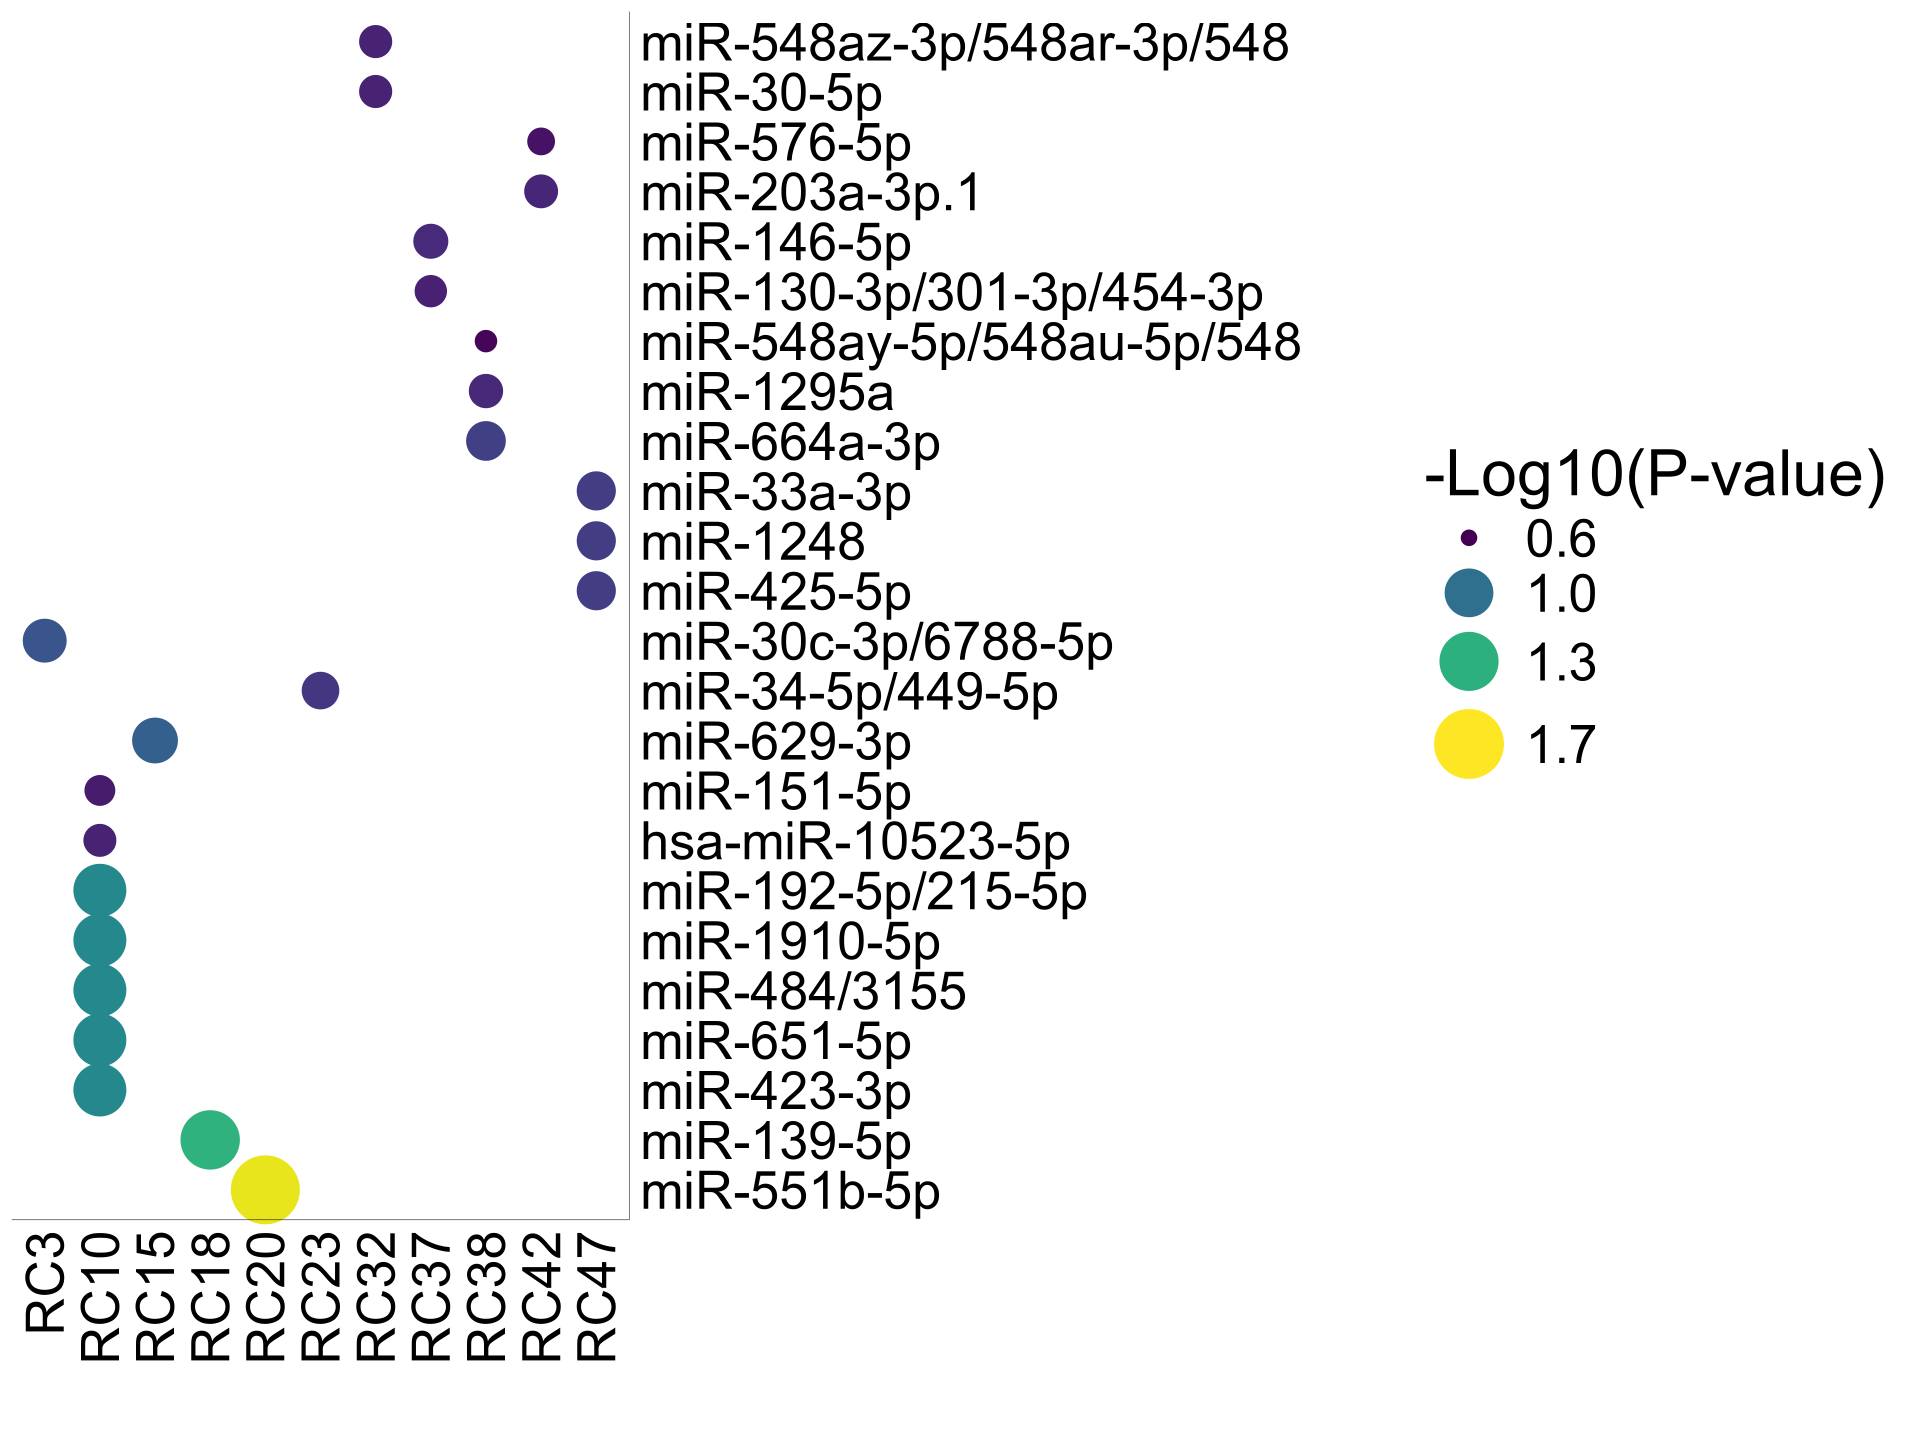

In [19]:
## miR ##
wfix = 16
hfix = 12

options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

gene_cluster = readRDS(paste0(path, 'fig_output/data/fig4/significant_miRs_to_RCs.rds'))
# make data square to calculate euclidean distance
mat <- gene_cluster %>% # drop unused columns to faciliate widening
  pivot_wider(names_from = cluster, values_from = count) %>%
  data.frame() # make df as tibbles -> matrix annoying
row.names(mat) <- mat$Gene  # put gene in `row`
mat <- mat[,-1] #drop gene column as now in rows
clust <- hclust(dist(mat %>% as.matrix())) 
v_clust <- hclust(dist(mat %>% as.matrix() %>% t())) # hclust with distance matrix
############ NOTICE THE t() above)

ddgram_col <- as.dendrogram(v_clust)
ggtree_plot_col <- ggtree(ddgram_col) + layout_dendrogram()

gene_cluster_select = gene_cluster %>% filter(count > (-log10(0.25)))
scale_breaks = sapply(signif(seq(signif(min(gene_cluster_select$count), 2), signif(max(gene_cluster_select$count), 2), length.out = 4), 2), FUN = plyr::round_any, accuracy = 0.1)

dotplot <- gene_cluster %>% 
  mutate(Gene = factor(Gene, levels = clust$labels[clust$order]),
         cluster = factor(cluster, levels = v_clust$labels)) %>%
         filter(count > (-log10(0.25))) %>%
  ggplot(aes(x=cluster, y = Gene, color = count, size = count)) + 
  geom_point() + 
  cowplot::theme_cowplot() + 
  theme(axis.line  = element_blank()) +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1)) +
  ylab('') + xlab('') +
  theme(axis.ticks = element_blank()) +
  #scale_color_gradientn(guide = 'legend', name = '-Log10(P-value)', colours = viridis::viridis(20), limits = c(0,4), oob = scales::squish, breaks = scale_breaks) +
  #scale_size_continuous(guide = 'legend', name = '-Log10(P-value)', range = c(4,10) , breaks = scale_breaks) +
  coord_cartesian(clip = 'off') +

  scale_color_gradientn(guide = 'legend', name = '-Log10(P-value)', colours = viridis::viridis(20), limits = c(min(scale_breaks), max(scale_breaks)), oob = scales::squish, breaks = scale_breaks) +
  scale_size_continuous(guide = 'legend', name = '-Log10(P-value)', range = c(4, 19), limits = c(min(scale_breaks), max(scale_breaks)), breaks = scale_breaks) +
  scale_y_discrete(position = "right") + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
#################################################
ggtree_plot_col <- ggtree_plot_col + xlim2(dotplot)


ddgram <- as.dendrogram(clust) # create dendrogram
ggtree_plot <- ggtree::ggtree(ddgram)
ggtree_plot <- ggtree_plot + ylim2(dotplot)

labels <- ggplot(gene_cluster %>% 
                   mutate(`Cell Type` = rep('A', nrow(gene_cluster)),
                           cluster = factor(cluster, levels = v_clust$labels)), 
                 aes(x = cluster, y = 1, fill = `Cell Type`)) + 
  geom_tile() + 
  scale_fill_brewer(palette = 'Set1') + 
  theme_nothing() +
  xlim2(dotplot)

legend <- plot_grid(get_legend(labels + theme(legend.position="bottom") + theme(axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = minor_text_size*scale_factor, family = "Helvetica"))))

#plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + labels + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + dotplot + plot_spacer() + plot_spacer() + legend + plot_layout(ncol = 3, widths = c(0.7, -0.1, 4), heights = c(0.9, 0.1, -0.1, 4, 1))
dotplot

ggsave(paste0(path, 'fig_output/data/fig4/significant_miRs_to_RCs.pdf'), width = wfix, height = hfix)



the plot was flipped and the x limits will be applied to y-axis

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 7644 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


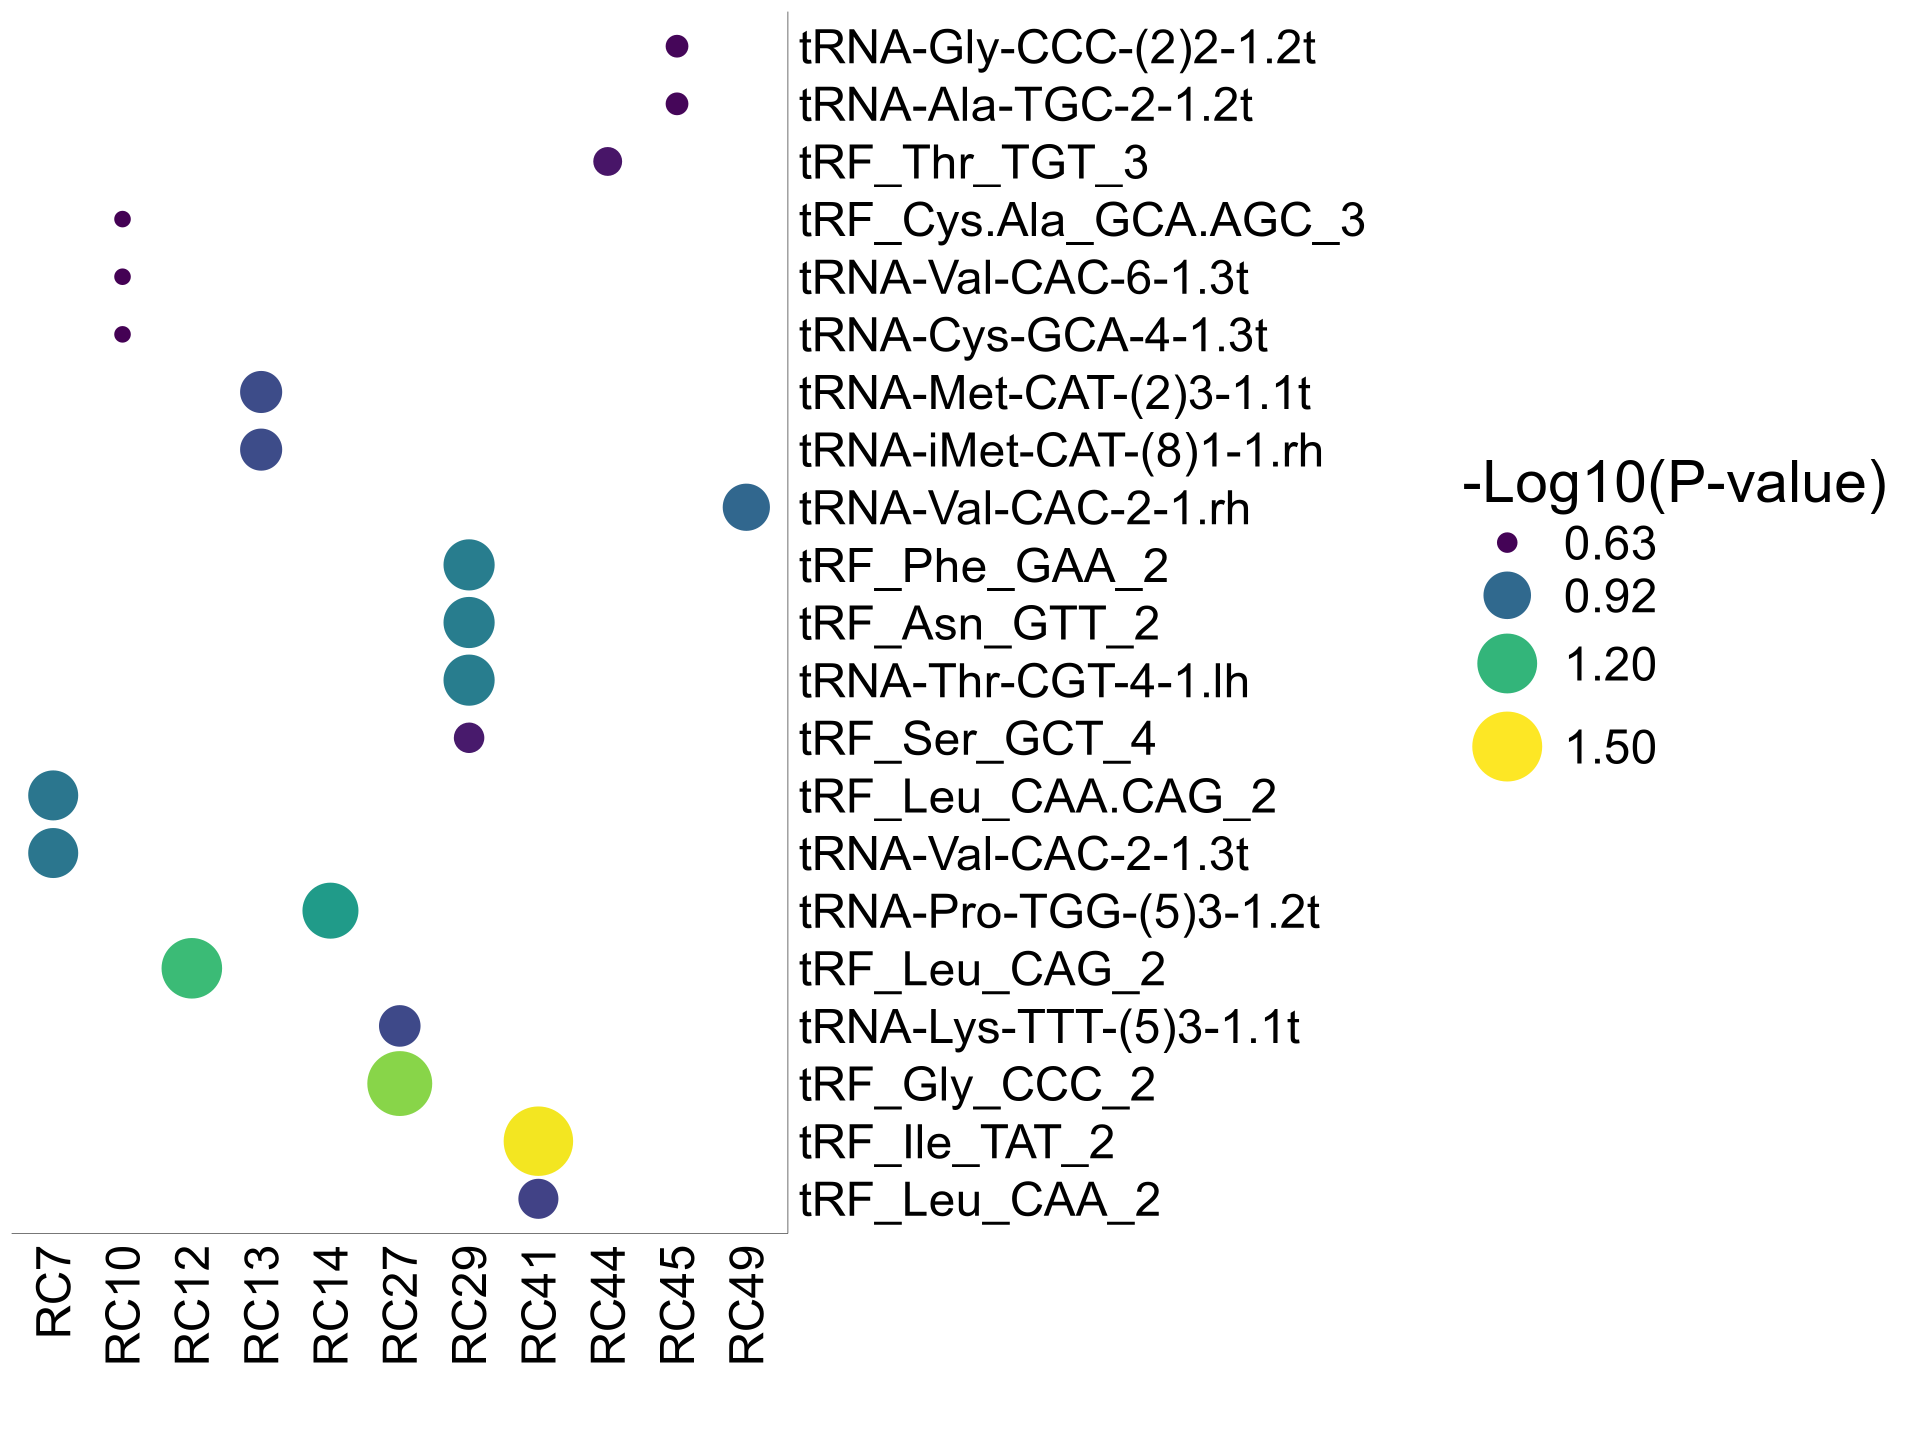

In [20]:
## tRF ##
wfix = 16
hfix = 12

options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = 11/2.5 ## always divide height by height -- much less likely to change to make figure look better

gene_cluster = readRDS(paste0(path, 'fig_output/data/fig4/significant_tRFs_to_RCs.rds'))

# make data square to calculate euclidean distance
mat <- gene_cluster %>% # drop unused columns to faciliate widening
  pivot_wider(names_from = cluster, values_from = count) %>%
  data.frame() # make df as tibbles -> matrix annoying
row.names(mat) <- mat$Gene  # put gene in `row`
mat <- mat[,-1] #drop gene column as now in rows
clust <- hclust(dist(mat %>% as.matrix())) 
v_clust <- hclust(dist(mat %>% as.matrix() %>% t())) # hclust with distance matrix
############ NOTICE THE t() above)

ddgram_col <- as.dendrogram(v_clust)
ggtree_plot_col <- ggtree(ddgram_col) + layout_dendrogram()

gene_cluster_select = gene_cluster %>% filter(count > (-log10(0.25)))
scale_breaks = sapply(signif(seq(signif(min(gene_cluster_select$count), 2), signif(max(gene_cluster_select$count), 2), length.out = 4), 2), FUN = plyr::round_any, accuracy = 0.01)


dotplot <- gene_cluster %>% 
  mutate(Gene = factor(Gene, levels = clust$labels[clust$order]),
         cluster = factor(cluster, levels = v_clust$labels)) %>%
         filter(count > (-log10(0.25))) %>%
  ggplot(aes(x=cluster, y = Gene, color = count, size = count)) + 
  geom_point() + 
  cowplot::theme_cowplot() + 
  theme(axis.line  = element_blank()) +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1)) +
  ylab('') + xlab('') +
  theme(axis.ticks = element_blank()) +
  scale_color_gradientn(guide = 'legend', name = '-Log10(P-value)', colours = viridis::viridis(20), limits = c(min(gene_cluster_select$count), 1.5), oob = scales::squish, breaks = scale_breaks) +
  scale_size_continuous(guide = 'legend', name = '-Log10(P-value)', range = c(4, 19), limits = c(min(gene_cluster_select$count), 1.5), breaks = scale_breaks) +
  scale_y_discrete(position = "right") + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
#################################################
ggtree_plot_col <- ggtree_plot_col + xlim2(dotplot)


ddgram <- as.dendrogram(clust) # create dendrogram
ggtree_plot <- ggtree::ggtree(ddgram)
ggtree_plot <- ggtree_plot + ylim2(dotplot)

labels <- ggplot(gene_cluster %>% 
                   mutate(`Cell Type` = rep('A', nrow(gene_cluster)),
                           cluster = factor(cluster, levels = v_clust$labels)), 
                 aes(x = cluster, y = 1, fill = `Cell Type`)) + 
  geom_tile() + 
  scale_fill_brewer(palette = 'Set1') + 
  theme_nothing() +
  xlim2(dotplot)

legend <- plot_grid(get_legend(labels + theme(legend.position="bottom")))

#plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + labels + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + dotplot + plot_spacer() + plot_spacer() + legend + plot_layout(ncol = 3, widths = c(0.7, -0.1, 4), heights = c(0.9, 0.1, -0.1, 4, 1))
dotplot

ggsave(paste0(path, 'fig_output/data/fig4/significant_tRFs_to_RCs.pdf'), width = wfix, height = hfix)

### RC to pathways dot heatmap ###

the plot was flipped and the x limits will be applied to y-axis

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


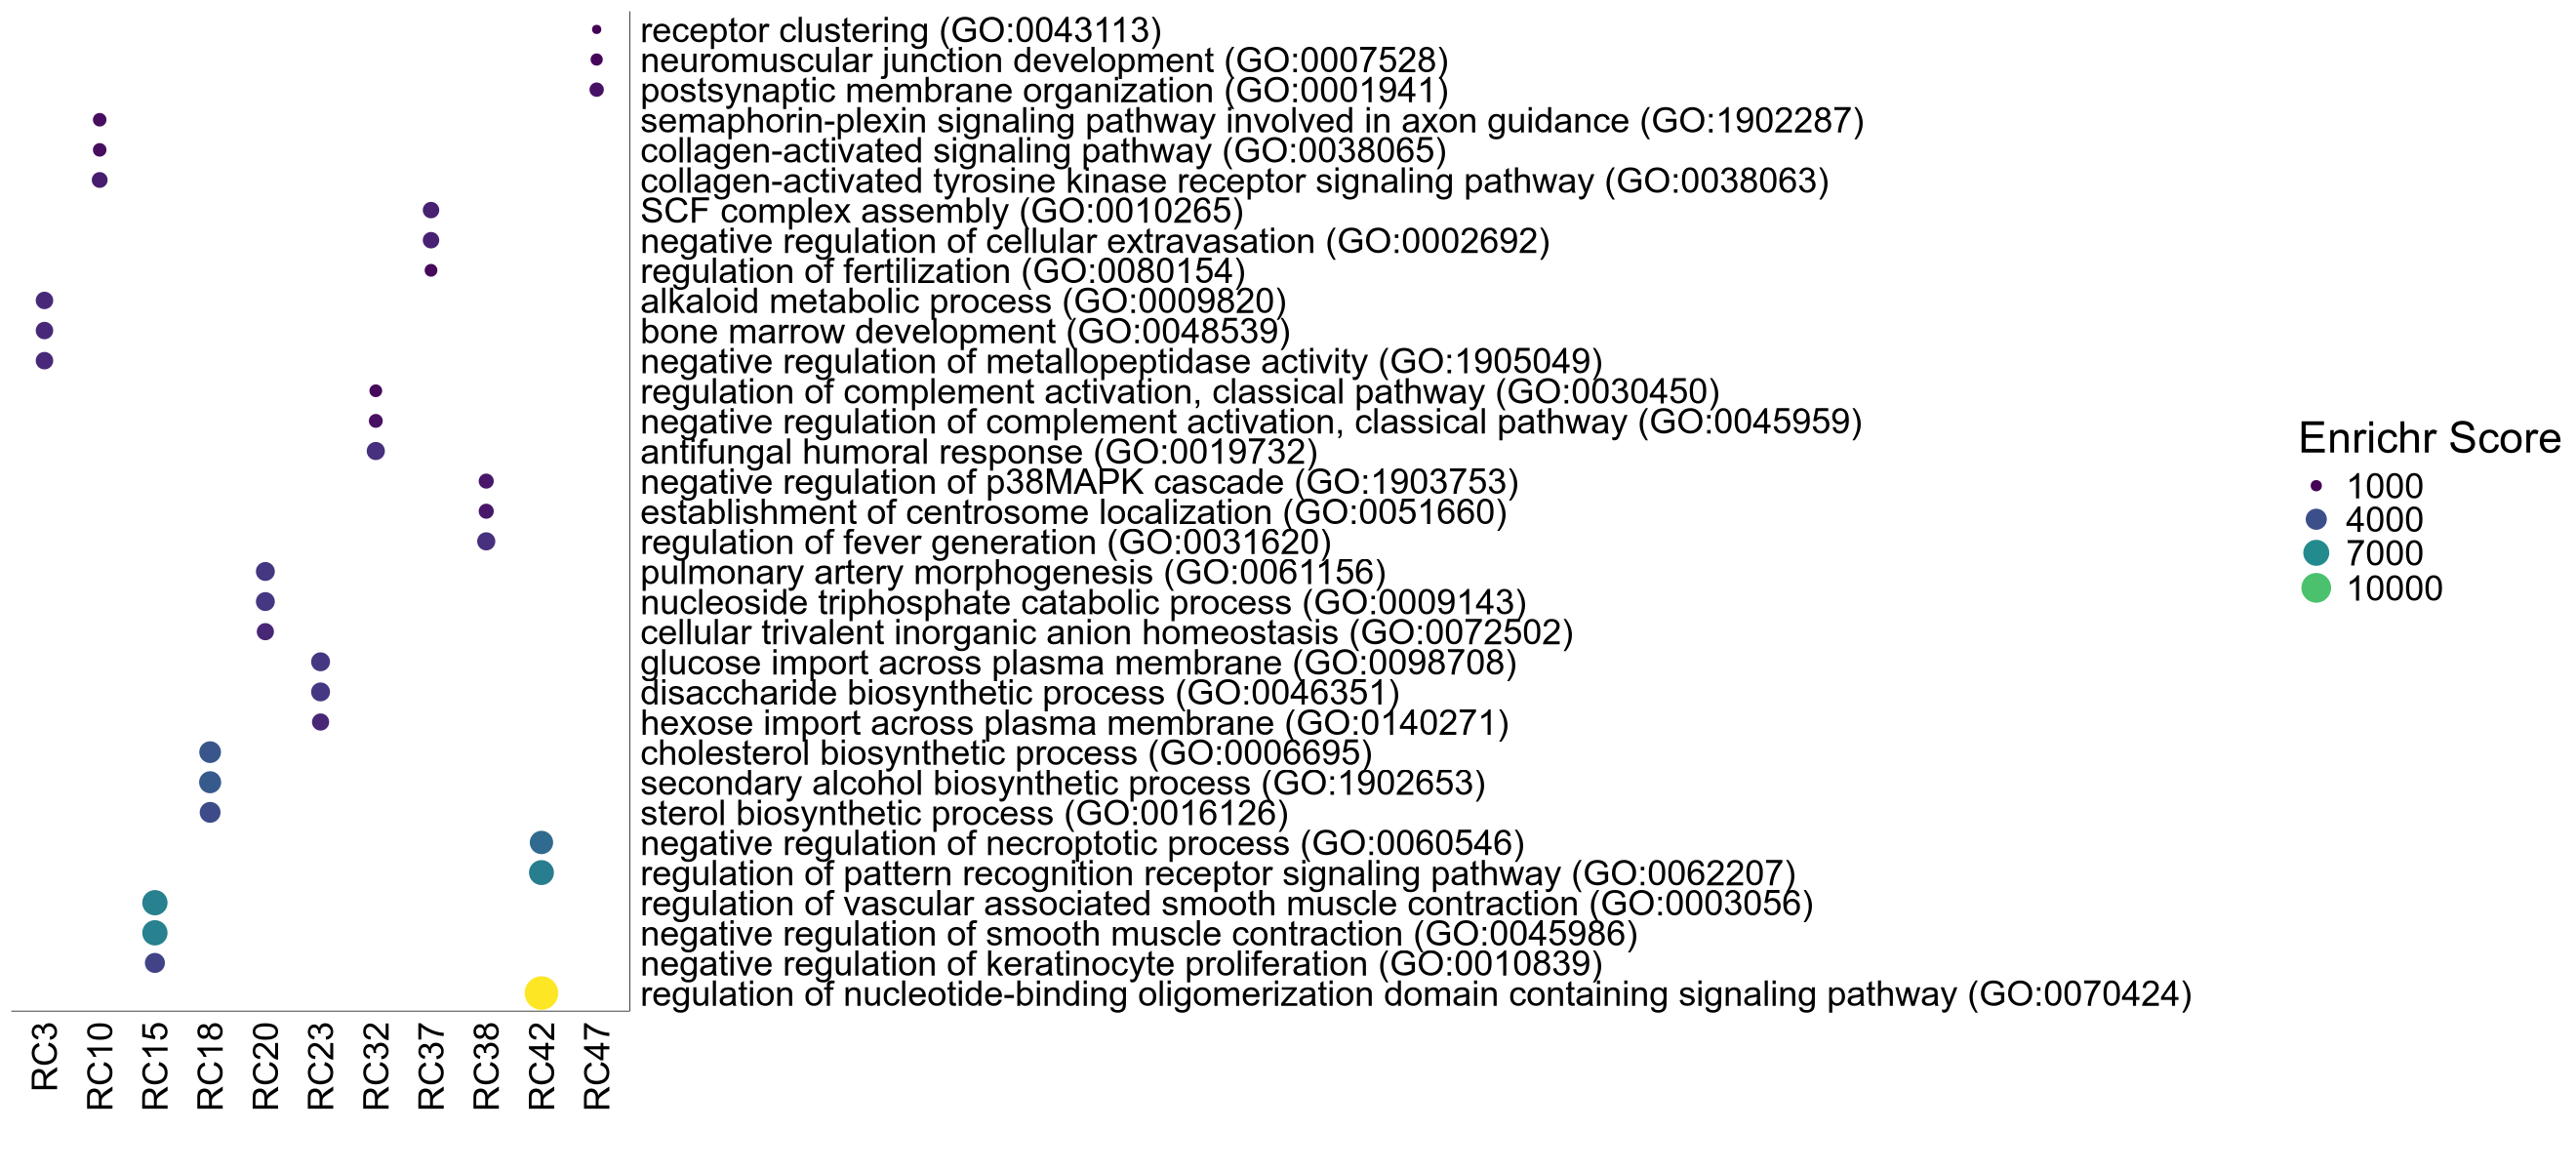

In [29]:
## miR ##
wfix = 22
hfix = 10
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3
scale_factor = hfix/3 ## always divide height by height -- much less likely to change to make figure look better

significant_RCs = readRDS(paste0(path, 'fig_output/data/fig4/miR_significant_RCs.rds'))
gene_cluster = readRDS(paste0(path, 'fig_output/data/fig4/miR_significant_RCs_to_pathways.rds'))
gene_cluster = gene_cluster %>% arrange(factor(cluster, levels = significant_RCs)) %>% as.data.frame()

mygraph <- graph_from_data_frame(gene_cluster)
mat <- as.matrix(get.adjacency(mygraph, sparse = FALSE, attr='count'))
mat <- select(as.data.frame(mat), starts_with("RC")) %>% filter(!startsWith(row.names(mat), "RC"))

clust <- hclust(dist(mat %>% as.matrix())) 
v_clust <- hclust(dist(mat %>% as.matrix() %>% t())) # hclust with distance matrix
############ NOTICE THE t() above)

ddgram_col <- as.dendrogram(v_clust)
ggtree_plot_col <- ggtree(ddgram_col) + layout_dendrogram()

scale_breaks = sapply(signif(seq(signif(min(gene_cluster$count), 1), signif(max(gene_cluster$count), 1), length.out = 4), 1), FUN = plyr::round_any, accuracy = 1000)

dotplot <- gene_cluster %>% 
  mutate(Gene = factor(Gene, levels = clust$labels[clust$order]),
         cluster = factor(cluster, levels = v_clust$labels)) %>%
         filter(cluster %in% significant_RCs) %>% filter(count > 0) %>%
  ggplot(aes(x=cluster, y = Gene, color = count, size = count)) + 
  geom_point() + 
  cowplot::theme_cowplot() + 
  theme(axis.line  = element_blank()) +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1)) +
  ylab('') + xlab('') +
  theme(axis.ticks = element_blank()) +
  scale_color_gradientn(guide = 'legend', name = 'Enrichr Score', colours = viridis::viridis(20), limits = c(min(gene_cluster$count), max(gene_cluster$count)), oob = scales::squish, breaks = scale_breaks) +
  scale_size_continuous(guide = 'legend', name = 'Enrichr Score', range = c(2, 9), limits = c(min(gene_cluster$count), max(gene_cluster$count)), breaks = scale_breaks) +
  scale_y_discrete(position = "right") + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
#################################################
ggtree_plot_col <- ggtree_plot_col + xlim2(dotplot)


ddgram <- as.dendrogram(clust) # create dendrogram
ggtree_plot <- ggtree::ggtree(ddgram)
ggtree_plot <- ggtree_plot + ylim2(dotplot)

labels <- ggplot(gene_cluster %>% 
                   mutate(`Cell Type` = rep('A', nrow(gene_cluster)),
                           cluster = factor(cluster, levels = v_clust$labels)), 
                 aes(x = cluster, y = 1, fill = `Cell Type`)) + 
  geom_tile() + 
  scale_fill_brewer(palette = 'Set1') + 
  theme_nothing() +
  xlim2(dotplot)

legend <- plot_grid(get_legend(labels + theme(legend.position="bottom")))

#plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + labels + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + dotplot + plot_spacer() + plot_spacer() + legend + plot_layout(ncol = 3, widths = c(0.7, -0.1, 4), heights = c(0.9, 0.1, -0.1, 4, 1))
dotplot

ggsave(paste0(path, 'fig_output/data/fig4/miR_significant_RCs_to_pathways.pdf'), width = wfix, height = hfix)

the plot was flipped and the x limits will be applied to y-axis

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


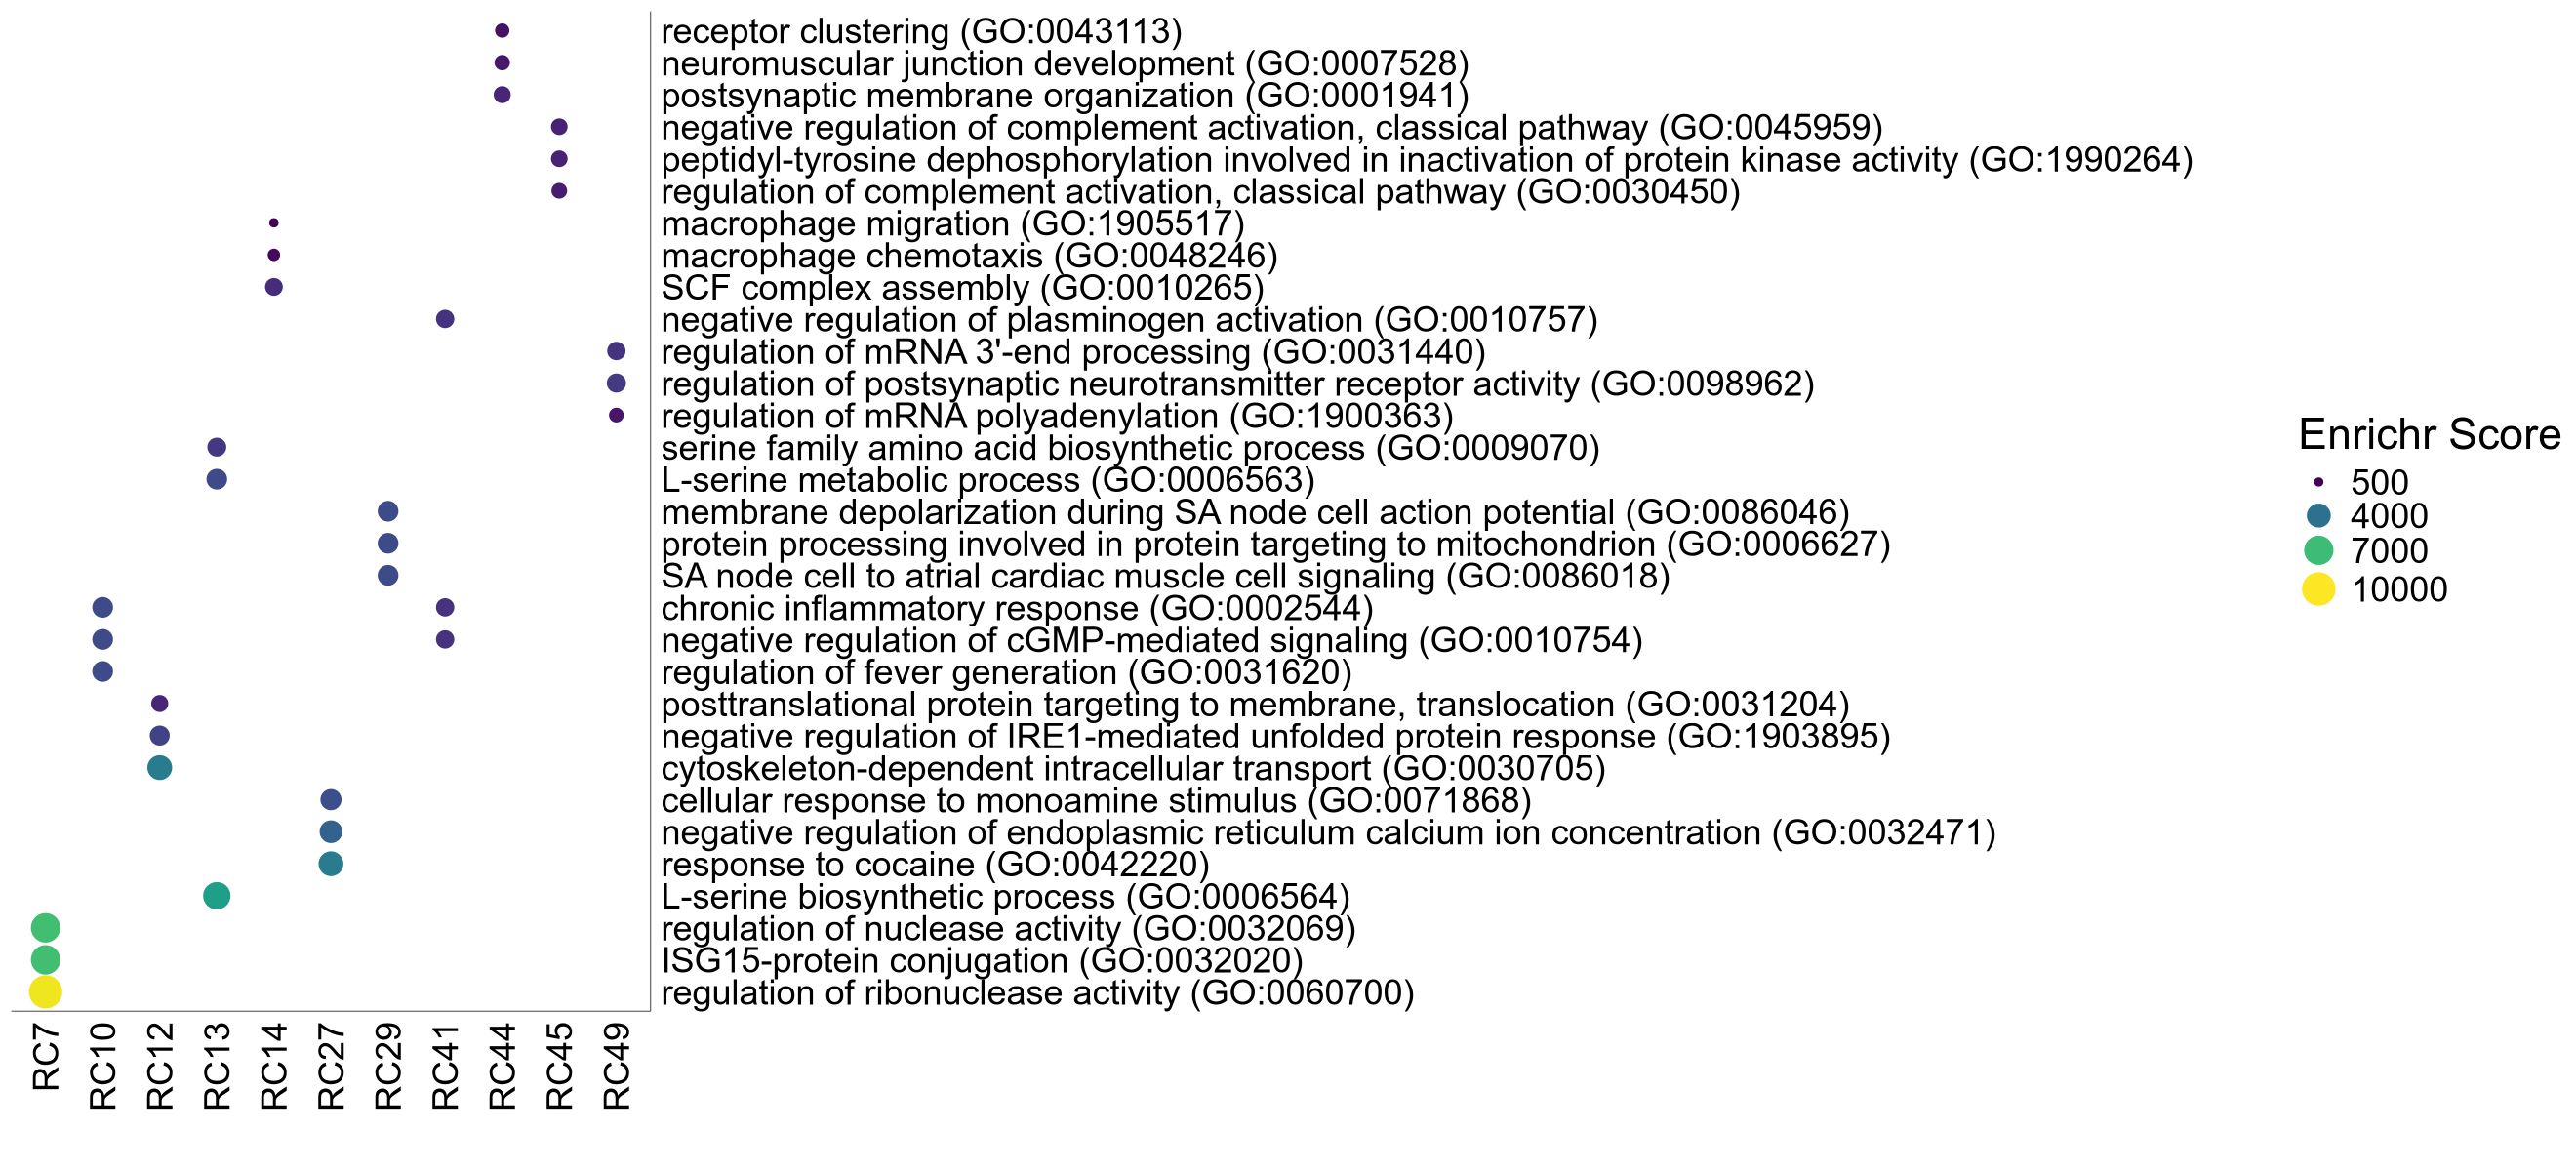

In [31]:
## tRF ##
wfix = 22
hfix = 10

options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3
scale_factor = hfix/3 ## always divide height by height -- much less likely to change to make figure look better

significant_RCs = readRDS(paste0(path, 'fig_output/data/fig4/tRF_significant_RCs.rds'))
gene_cluster = readRDS(paste0(path, 'fig_output/data/fig4/tRF_significant_RCs_to_pathways.rds'))
gene_cluster = gene_cluster %>% arrange(factor(cluster, levels = significant_RCs)) %>% as.data.frame()

mygraph <- graph_from_data_frame(gene_cluster)
mat <- as.matrix(get.adjacency(mygraph, sparse = FALSE, attr='count'))
mat <- select(as.data.frame(mat), starts_with("RC")) %>% filter(!startsWith(row.names(mat), "RC"))

clust <- hclust(dist(mat %>% as.matrix())) 
v_clust <- hclust(dist(mat %>% as.matrix() %>% t())) # hclust with distance matrix
############ NOTICE THE t() above)

ddgram_col <- as.dendrogram(v_clust)
ggtree_plot_col <- ggtree(ddgram_col) + layout_dendrogram()

scale_breaks = sapply(signif(seq(signif(min(gene_cluster$count), 1), signif(max(gene_cluster$count), 1), length.out = 4), 1), FUN = plyr::round_any, accuracy = 100)

dotplot <- gene_cluster %>% 
  mutate(Gene = factor(Gene, levels = clust$labels[clust$order]),
         cluster = factor(cluster, levels = v_clust$labels)) %>%
         filter(cluster %in% significant_RCs) %>% filter(count > 0) %>%
  ggplot(aes(x=cluster, y = Gene, color = count, size = count)) + 
  geom_point() + 
  cowplot::theme_cowplot() + 
  theme(axis.line  = element_blank()) +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1)) +
  ylab('') + xlab('') +
  theme(axis.ticks = element_blank()) +
  scale_color_gradientn(guide = 'legend', name = 'Enrichr Score', colours = viridis::viridis(20), limits = c(min(scale_breaks), max(scale_breaks)), oob = scales::squish, breaks = scale_breaks) +
  scale_size_continuous(guide = 'legend', name = 'Enrichr Score', range = c(2,9), limits = c(min(scale_breaks), max(scale_breaks)), breaks = scale_breaks) +
  scale_y_discrete(position = "right") + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
#################################################
ggtree_plot_col <- ggtree_plot_col + xlim2(dotplot)


ddgram <- as.dendrogram(clust) # create dendrogram
ggtree_plot <- ggtree::ggtree(ddgram)
ggtree_plot <- ggtree_plot + ylim2(dotplot)

labels <- ggplot(gene_cluster %>% 
                   mutate(`Cell Type` = rep('A', nrow(gene_cluster)),
                           cluster = factor(cluster, levels = v_clust$labels)), 
                 aes(x = cluster, y = 1, fill = `Cell Type`)) + 
  geom_tile() + 
  scale_fill_brewer(palette = 'Set1') + 
  theme_nothing() +
  xlim2(dotplot)

legend <- plot_grid(get_legend(labels + theme(legend.position="bottom")))

#plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + labels + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + dotplot + plot_spacer() + plot_spacer() + legend + plot_layout(ncol = 3, widths = c(0.7, -0.1, 4), heights = c(0.9, 0.1, -0.1, 4, 1))
dotplot

ggsave(paste0(path, 'fig_output/data/fig4/tRF_significant_RCs_to_pathways.pdf'), width = wfix, height = hfix)

### supplemental fig RC to high correlation/loading genes dot heatmap ###

the plot was flipped and the x limits will be applied to y-axis

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 78000 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


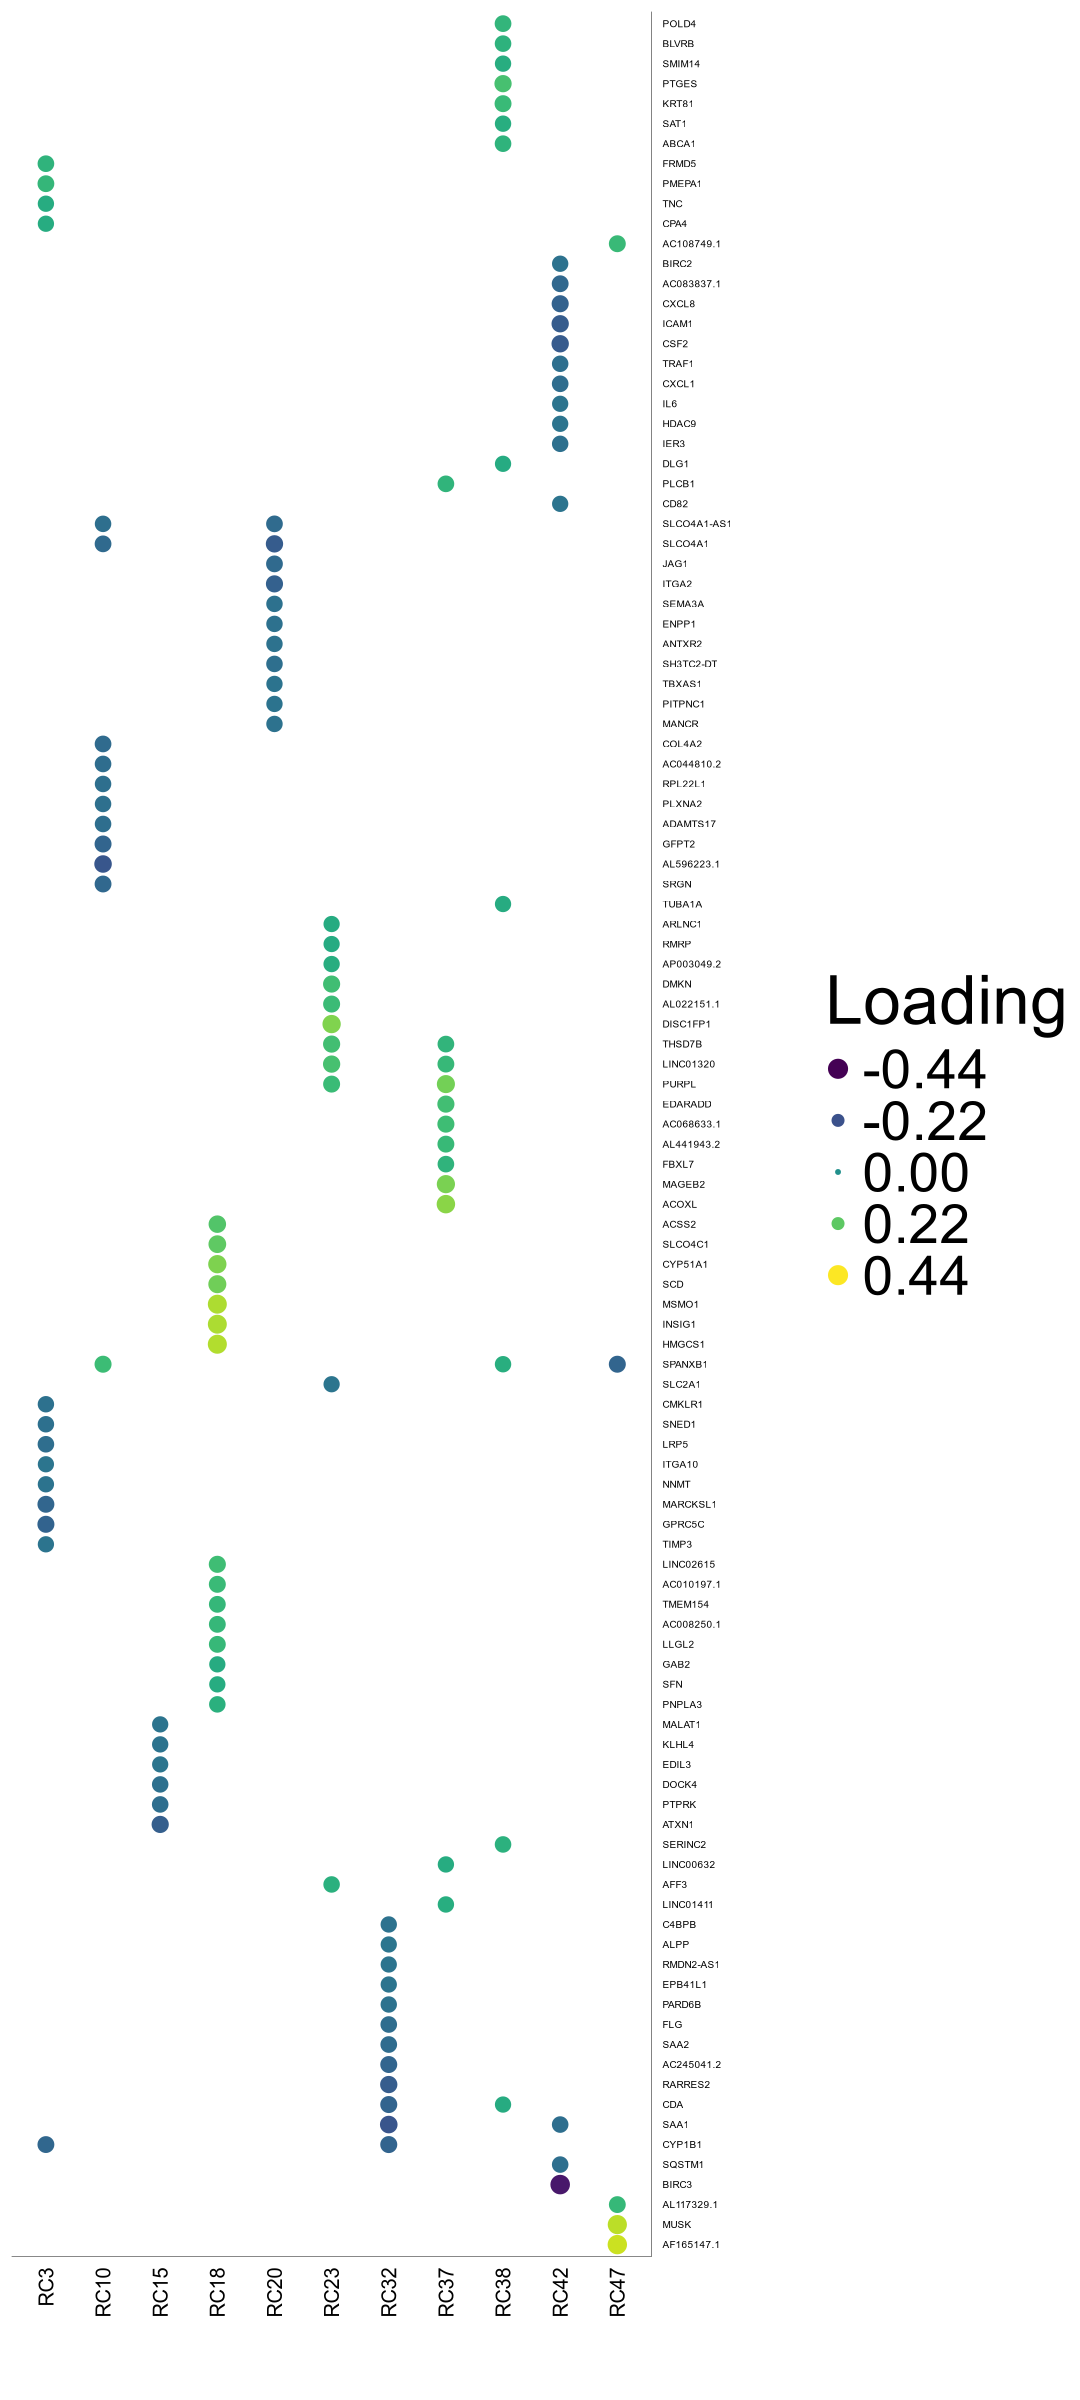

In [32]:
## miR ##
wfix = 9
hfix = 20
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

significant_RCs = readRDS(paste0(path, 'fig_output/data/fig4/miR_significant_RCs.rds'))
gene_cluster = readRDS(paste0(path, 'fig_output/data/fig4/miR_significant_RCs_genes.rds'))
gene_cluster = gene_cluster %>% arrange(factor(cluster, levels = significant_RCs)) %>% as.data.frame()

# make data square to calculate euclidean distance
mat <- gene_cluster %>% # drop unused columns to faciliate widening
  pivot_wider(names_from = cluster, values_from = count) %>%
  data.frame() # make df as tibbles -> matrix annoying
row.names(mat) <- mat$Gene  # put gene in `row`
mat <- mat[,-1] #drop gene column as now in rows
clust <- hclust(dist(mat %>% as.matrix())) 
v_clust <- hclust(dist(mat %>% as.matrix() %>% t())) # hclust with distance matrix
############ NOTICE THE t() above)

ddgram_col <- as.dendrogram(v_clust)
ggtree_plot_col <- ggtree(ddgram_col) + layout_dendrogram()

scale_breaks = sapply(signif(seq(signif(-max(gene_cluster$count), 2), signif(max(gene_cluster$count), 2), length.out = 5), 2), FUN = plyr::round_any, accuracy = 0.01)
legend_size = c(5, 3, 1, 3, 5)

dotplot <- gene_cluster %>% 
  mutate(Gene = factor(Gene, levels = clust$labels[clust$order]),
         cluster = factor(cluster, levels = v_clust$labels)) %>%
         filter(cluster %in% significant_RCs) %>% filter(count > 0 | count < 0) %>%
  ggplot(aes(x=cluster, y = Gene, color = count, size = abs(count))) + 
  geom_point() + 
  cowplot::theme_cowplot() + 
  theme(axis.line  = element_blank()) +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1, size = 12), axis.text.y = element_text(size = 6)) +
  ylab('') + xlab('') +
  theme(axis.ticks = element_blank()) +
  scale_color_gradientn(guide = 'legend', name = 'Loading', colours = viridis::viridis(20), limits = c(min(scale_breaks), round(max(gene_cluster$count), 3)), oob = scales::squish, breaks = scale_breaks) +
  scale_size_continuous(guide = 'legend', name = 'Loading', range = c(0,5), limits = c(min(scale_breaks), round(max(gene_cluster$count), 3)), breaks = scale_breaks) +
  scale_y_discrete(position = "right") + guides(color = guide_legend(), size = guide_legend(override.aes = list(size = legend_size)))  + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
#################################################
ggtree_plot_col <- ggtree_plot_col + xlim2(dotplot)


ddgram <- as.dendrogram(clust) # create dendrogram
ggtree_plot <- ggtree::ggtree(ddgram)
ggtree_plot <- ggtree_plot + ylim2(dotplot)

labels <- ggplot(gene_cluster %>% 
                   mutate(`Cell Type` = rep('A', nrow(gene_cluster)),
                           cluster = factor(cluster, levels = v_clust$labels)), 
                 aes(x = cluster, y = 1, fill = `Cell Type`)) + 
  geom_tile() + 
  scale_fill_brewer(palette = 'Set1') + 
  theme_nothing() +
  xlim2(dotplot)

legend <- plot_grid(get_legend(labels + theme(legend.position = "bottom")))

#plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + labels + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + dotplot + plot_spacer() + plot_spacer() + legend + plot_layout(ncol = 3, widths = c(0.7, -0.1, 4), heights = c(0.9, 0.1, -0.1, 4, 1))
dotplot

ggsave(paste0(path, 'fig_output/data/fig4/miR_significant_RCs_genes.pdf'), width = wfix, height = hfix)



the plot was flipped and the x limits will be applied to y-axis

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 78000 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


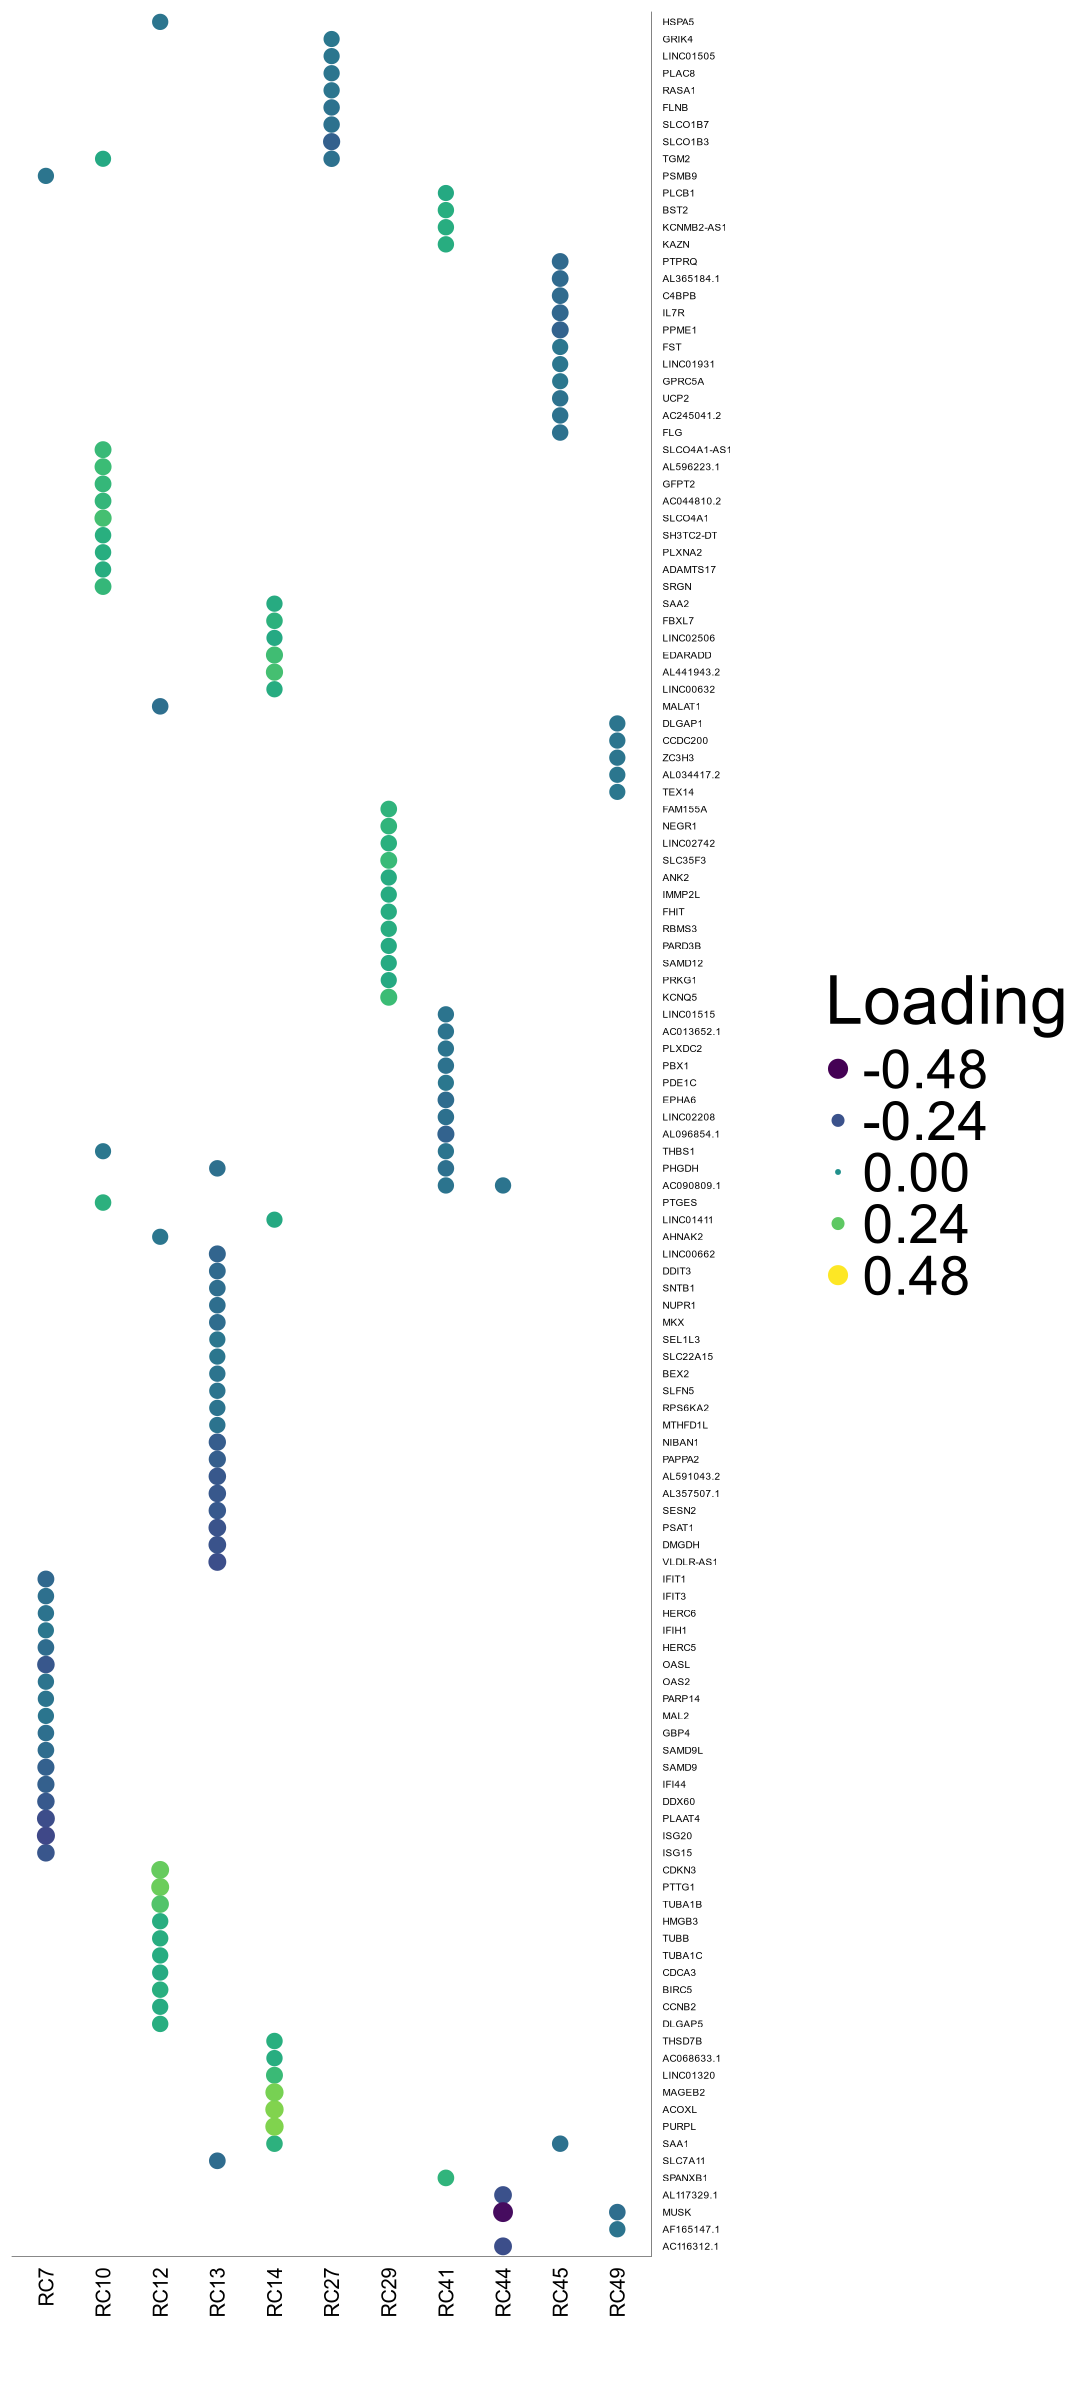

In [33]:
## tRF ##
wfix = 9
hfix = 20
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

significant_RCs = readRDS(paste0(path, 'fig_output/data/fig4/tRF_significant_RCs.rds'))
gene_cluster = readRDS(paste0(path, 'fig_output/data/fig4/tRF_significant_RCs_genes.rds'))
gene_cluster = gene_cluster %>% arrange(factor(cluster, levels = significant_RCs)) %>% as.data.frame()

# make data square to calculate euclidean distance
mat <- gene_cluster %>% # drop unused columns to faciliate widening
  pivot_wider(names_from = cluster, values_from = count) %>%
  data.frame() # make df as tibbles -> matrix annoying
row.names(mat) <- mat$Gene  # put gene in `row`
mat <- mat[,-1] #drop gene column as now in rows
clust <- hclust(dist(mat %>% as.matrix())) 
v_clust <- hclust(dist(mat %>% as.matrix() %>% t())) # hclust with distance matrix
############ NOTICE THE t() above)

ddgram_col <- as.dendrogram(v_clust)
ggtree_plot_col <- ggtree(ddgram_col) + layout_dendrogram()

scale_breaks = sapply(signif(seq(signif(min(gene_cluster$count), 2), signif(abs(min(gene_cluster$count)), 2), length.out = 5), 2), FUN = plyr::round_any, accuracy = 0.01)
legend_size = c(5, 3, 1, 3, 5)

dotplot <- gene_cluster %>% 
  mutate(Gene = factor(Gene, levels = clust$labels[clust$order]),
         cluster = factor(cluster, levels = v_clust$labels)) %>%
         filter(cluster %in% significant_RCs) %>% filter(count > 0 | count < 0) %>%
  ggplot(aes(x=cluster, y = Gene, color = count, size = abs(count))) + 
  geom_point() + 
  cowplot::theme_cowplot() + 
  theme(axis.line  = element_blank()) +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1, size = 12), axis.text.y = element_text(size = 6)) +
  ylab('') + xlab('') +
  theme(axis.ticks = element_blank()) +
  scale_color_gradientn(guide = 'legend', name = 'Loading', colours = viridis::viridis(20), limits = c(round(min(gene_cluster$count), 2), max(scale_breaks)), oob = scales::squish, breaks = scale_breaks) +
  scale_size_continuous(guide = 'legend', name = 'Loading', range = c(0,5), limits = c(round(min(gene_cluster$count), 2), max(scale_breaks)), breaks = scale_breaks) +
  scale_y_discrete(position = "right") + guides(color = guide_legend(), size = guide_legend(override.aes = list(size = legend_size))) + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
#################################################
ggtree_plot_col <- ggtree_plot_col + xlim2(dotplot)


ddgram <- as.dendrogram(clust) # create dendrogram
ggtree_plot <- ggtree::ggtree(ddgram)
ggtree_plot <- ggtree_plot + ylim2(dotplot)

labels <- ggplot(gene_cluster %>% 
                   mutate(`Cell Type` = rep('A', nrow(gene_cluster)),
                           cluster = factor(cluster, levels = v_clust$labels)), 
                 aes(x = cluster, y = 1, fill = `Cell Type`)) + 
  geom_tile() + 
  scale_fill_brewer(palette = 'Set1') + 
  theme_nothing() +
  xlim2(dotplot)

legend <- plot_grid(get_legend(labels + theme(legend.position="bottom")))

#plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + labels + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + plot_spacer() + dotplot + plot_spacer() + plot_spacer() + legend + plot_layout(ncol = 3, widths = c(0.7, -0.1, 4), heights = c(0.9, 0.1, -0.1, 4, 1))
dotplot

ggsave(paste0(path, 'fig_output/data/fig4/tRF_significant_RCs_genes.pdf'), width = wfix, height = hfix)


### supplemental fig box plots of RC scores vs best guide fit for the significant RCs ###

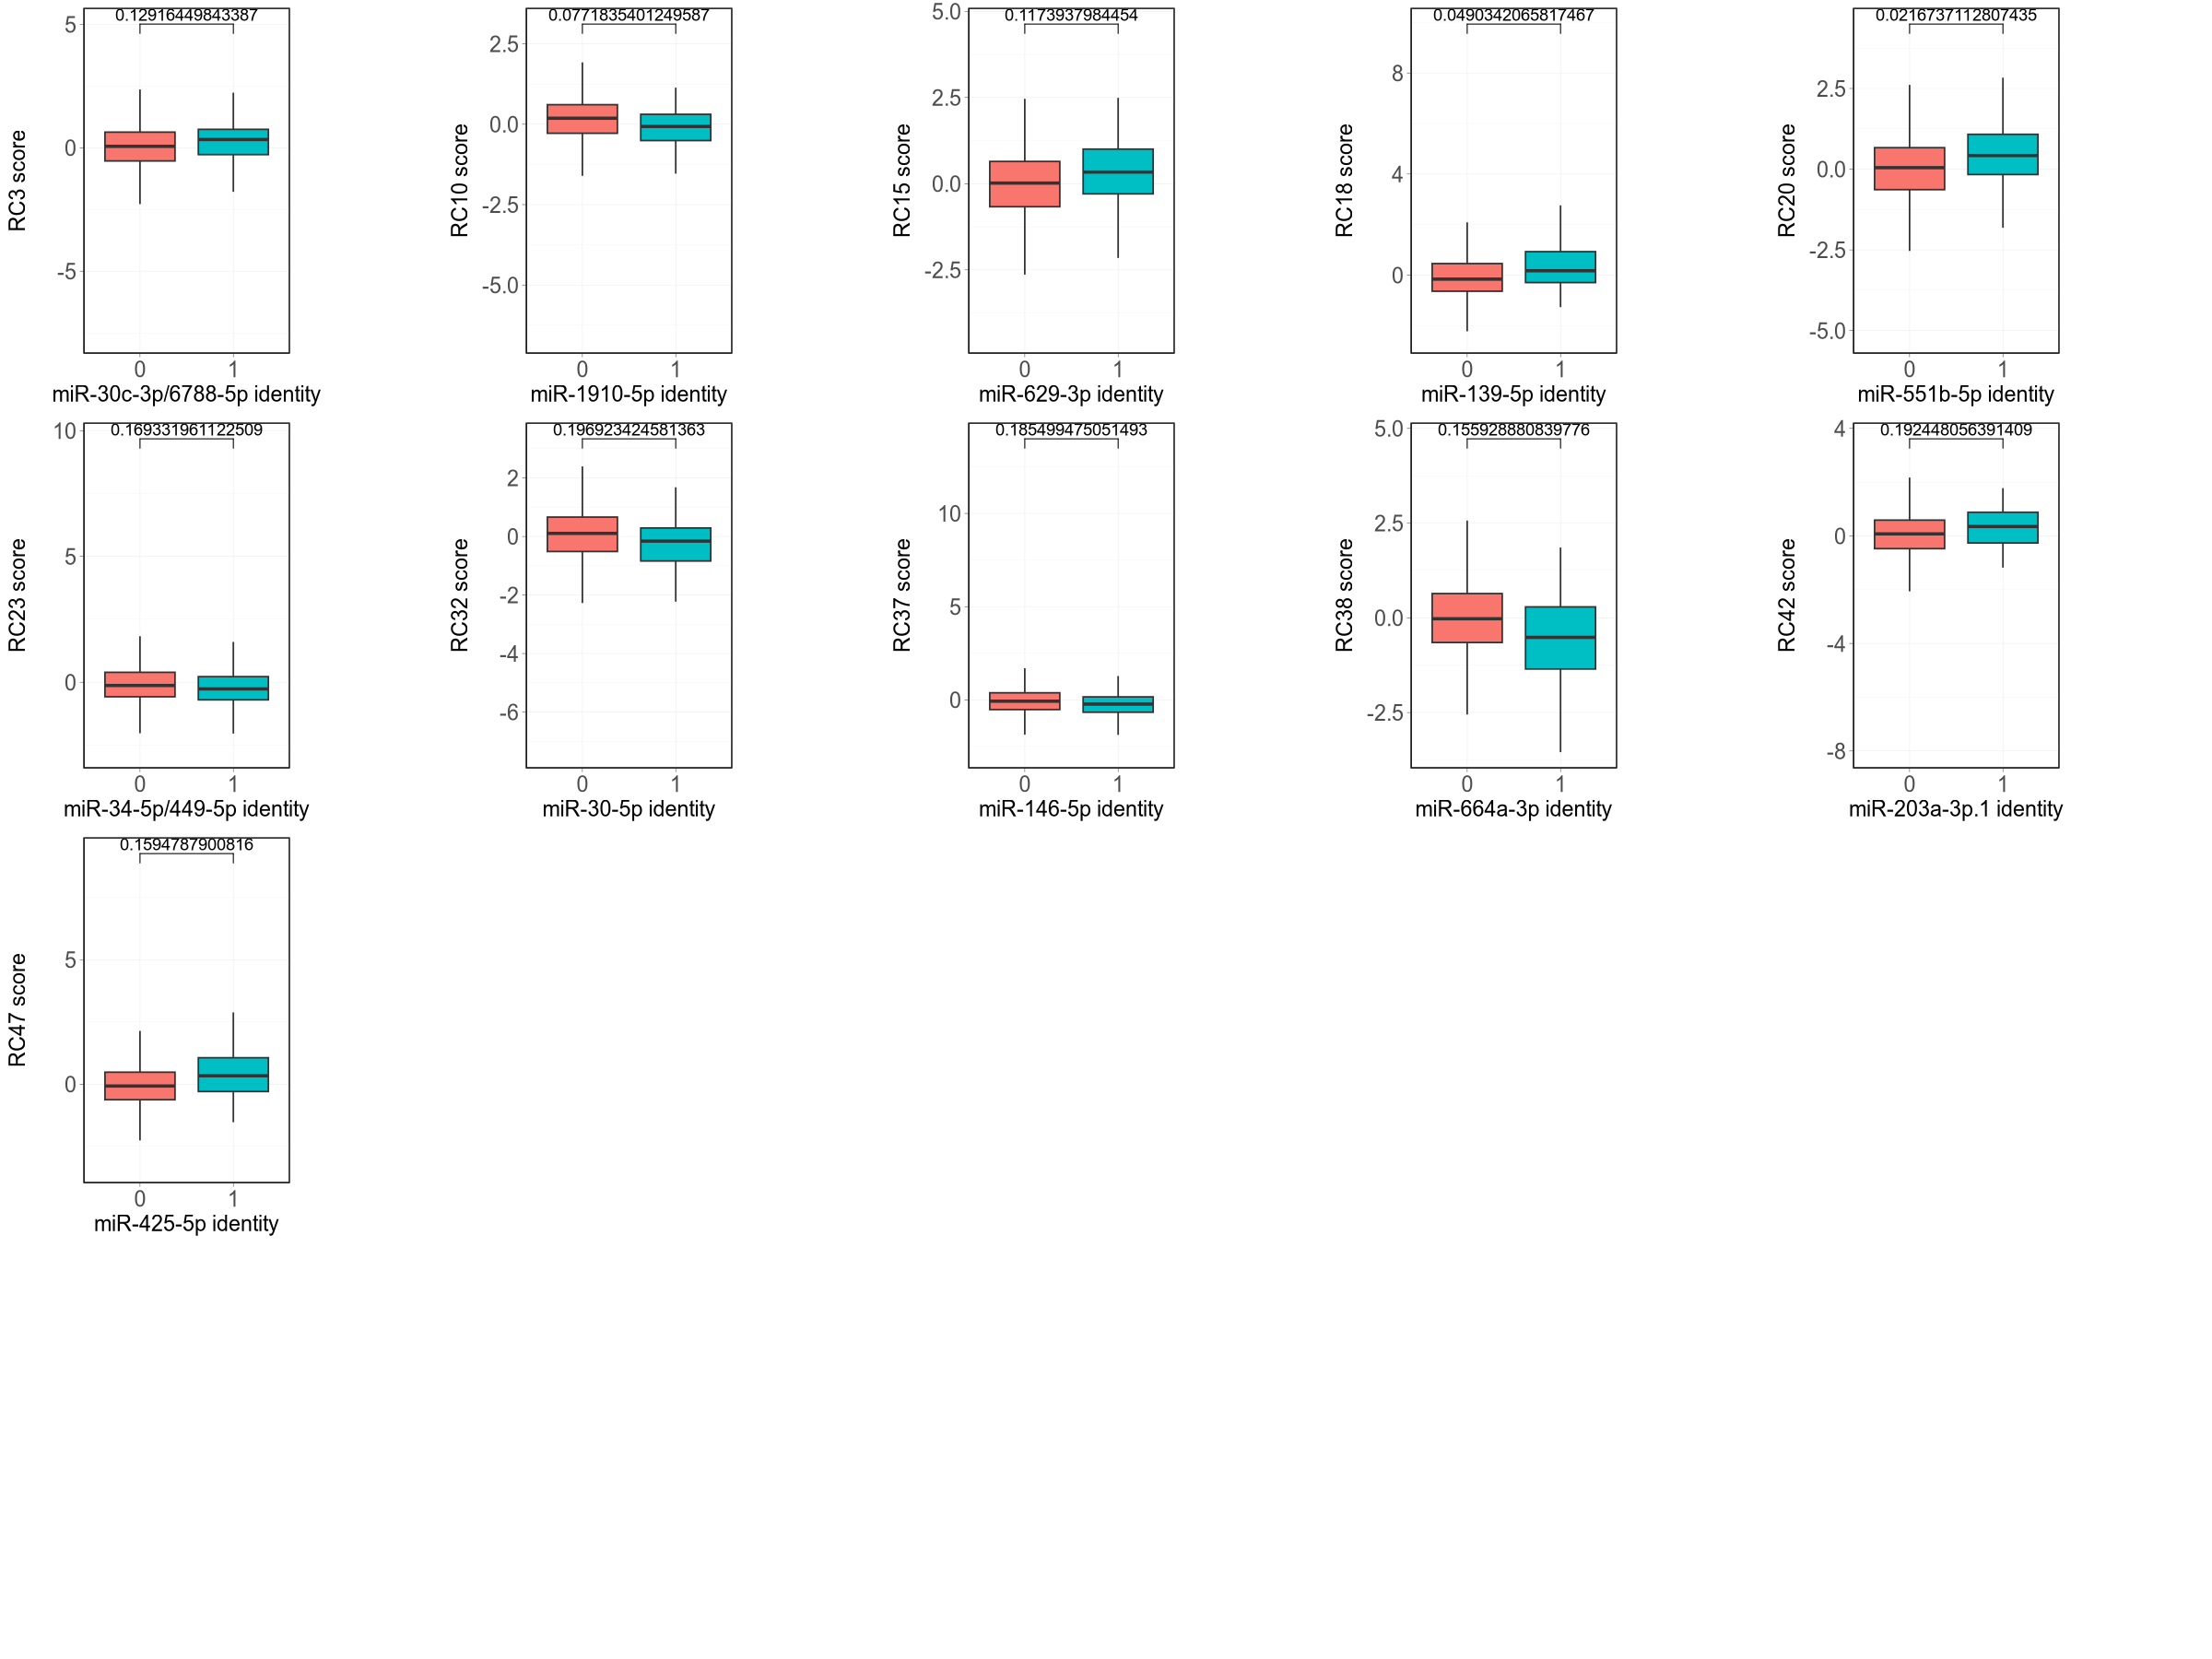

In [ ]:
## miR ##
wfix = 20
hfix = 15
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.15
scale_factor = hfix/3.15 ## always divide height by height -- much less likely to change to make figure look better

gene_cluster = readRDS(paste0(path, 'fig_output/data/fig4/significant_miRs_to_RCs.rds'))
significant_RCs = readRDS(paste0(path, 'fig_output/data/fig4/miR_significant_RCs.rds'))
fits_table = readRDS(paste0(path, 'fig_output/data/fig4/miR_boxplot_RCs_best_guide_fit.rds'))
rotated_varimax_scores =  readRDS(paste0(path, 'fig_output/data/fig4/miR_rotated_varimax_scores.rds'))
meta = readRDS(paste0(path, 'fig_output/data/fig4/miR_meta.rds'))
significant_guides_to_RCs = sapply(significant_RCs, function(a) fits_table %>% dplyr::filter(y == a) %>% arrange(desc(abs(value))) %>% pull(x) %>% head(1))
significant_guides_to_RCs = as.character(significant_guides_to_RCs)
RC_to_guide_violin_dfs = list()
RC_to_guide_violin_plots = list()
RC_to_guide_box_plots = list()
RC_to_guide_violin_plots_individual_scale = list()
RC_to_guide_box_plots_individual_scale = list()
ttests = list()
for (i in 1:length(significant_RCs)){
    idx = as.numeric(significant_RCs[i] %>% str_sub(3))
    RC_to_guide_violin_dfs[[i]] = data.frame(RC = significant_RCs[i], guide = significant_guides_to_RCs[i], RC_score = rotated_varimax_scores[meta$guide == significant_guides_to_RCs[i] | meta$guide == 'TuD_NC',idx], guide_score = ifelse(meta$guide[meta$guide == significant_guides_to_RCs[i] | meta$guide == 'TuD_NC'] == as.character(significant_guides_to_RCs[i]), 1, 0))
    RC_to_guide_violin_dfs[[i]]$guide_score = as.factor(RC_to_guide_violin_dfs[[i]]$guide_score)
    my_comparisons = list(c('0','1'))
    upper_lim = max(RC_to_guide_violin_dfs[[i]]$RC_score)*1.15
    RC_to_guide_violin_plots[[i]] = ggplot(RC_to_guide_violin_dfs[[i]], aes(x = guide_score, y = RC_score, fill = guide_score)) + geom_jitter(position = position_jitter(seed = 1, width = 0.2), alpha = 0.1) + geom_violin(alpha = 0.8, trim = FALSE) + theme_bw() + theme(axis.text.x = element_text(size = 14), axis.text.y = element_text(size = 14), axis.title.x = element_text(size = 14), axis.title.y = element_text(size = 14)) + labs(y = paste0('RC', idx, ' score'), x = paste0(significant_guides_to_RCs[i], ' identity')) + 
    stat_compare_means(method = "t.test", label.x = 1.35, comparisons = my_comparisons, label.y = upper_lim) + ylim(-15, 15) + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
    
    RC_to_guide_violin_plots_individual_scale[[i]] = ggplot(RC_to_guide_violin_dfs[[i]], aes(x = guide_score, y = RC_score, fill = guide_score)) + geom_jitter(position = position_jitter(seed = 1, width = 0.2), alpha = 0.1) + geom_violin(alpha = 0.8, trim = FALSE) + theme_bw() + theme(axis.text.x = element_text(size = 14), axis.text.y = element_text(size = 14), axis.title.x = element_text(size = 14), axis.title.y = element_text(size = 14)) + labs(y = paste0('RC', idx, ' score'), x = paste0(significant_guides_to_RCs[i], ' identity')) + 
    stat_compare_means(method = "t.test", label.x = 1.35, comparisons = my_comparisons, label.y = upper_lim) + ylim(-upper_lim*1.2, upper_lim*1.2) + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
    
    stat.test = data.frame(.y. = 'len', group1 = '0', group2 = '1', p = 10^-max(gene_cluster[gene_cluster$Gene == significant_guides_to_RCs[i], 'count']), y.position = upper_lim)
    RC_to_guide_box_plots[[i]] = ggplot(RC_to_guide_violin_dfs[[i]], aes(x = guide_score, y = RC_score, fill = guide_score)) + geom_boxplot(outlier.shape = NA, show.legend = FALSE) + theme_bw() + theme(axis.text.x = element_text(size = 14), axis.text.y = element_text(size = 14), axis.title.x = element_text(size = 14), axis.title.y = element_text(size = 14), plot.margin = unit(c(5.5, 100, 5.5, 5.5), 'pt')) + labs(y = paste0('RC', idx, ' score'), x = paste0(significant_guides_to_RCs[i], ' identity')) +
    stat_pvalue_manual(stat.test, label = "p", label.x = 1.35, inherit.aes = F) + coord_cartesian(clip = 'off') + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
    
    RC_to_guide_box_plots_individual_scale[[i]] = ggplot(RC_to_guide_violin_dfs[[i]], aes(x = guide_score, y = RC_score, fill = guide_score)) + geom_boxplot() + theme_bw() + theme(axis.text.x = element_text(size = 14), axis.text.y = element_text(size = 14), axis.title.x = element_text(size = 14), axis.title.y = element_text(size = 14)) + labs(y = paste0('RC', idx, ' score'), x = paste0(significant_guides_to_RCs[i], ' identity')) +
    stat_compare_means(method = "t.test", label.x = 1.35, comparisons = my_comparisons, label.y = upper_lim) + ylim(-upper_lim*1.2, upper_lim*1.2) + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
}

ggpubr::ggarrange(plotlist = RC_to_guide_box_plots, ncol = 5, nrow = 4, align = 'hv')
#ggsave(paste0(path, 'fig_output/data/fig4/miR_boxplot_RCs_best_guide_fit.pdf'), width = wfix, height = hfix)

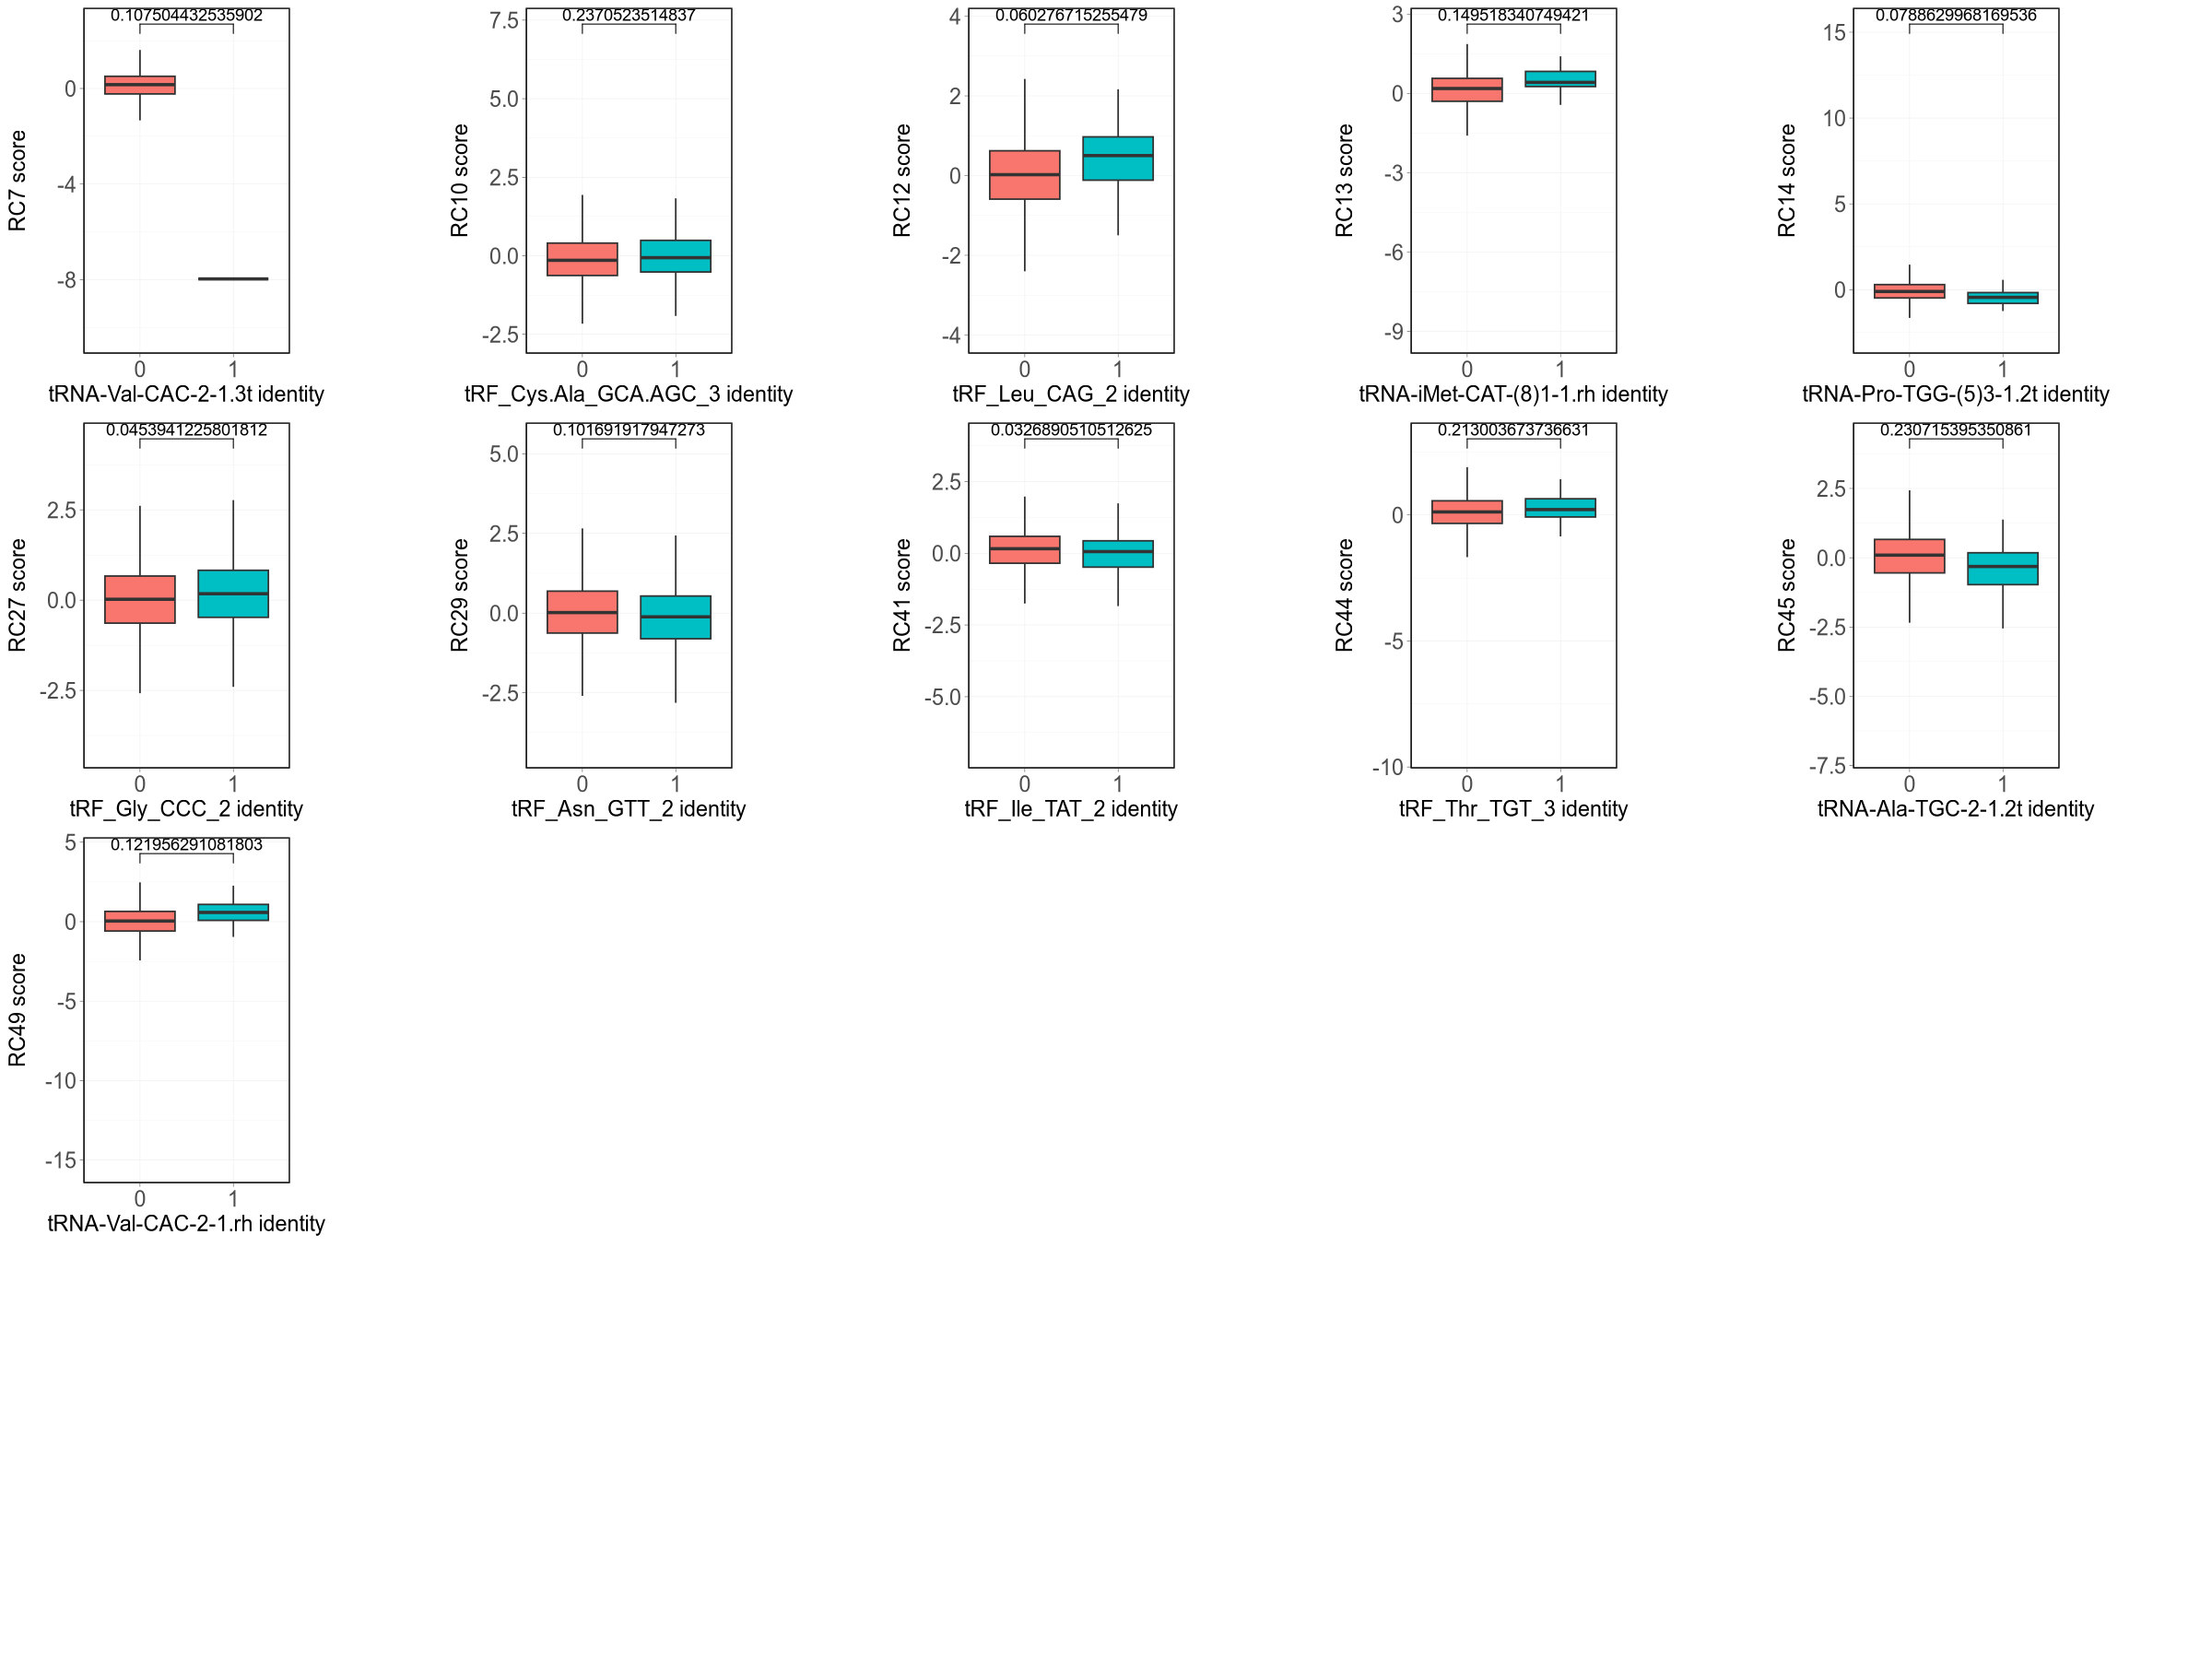

In [64]:
## tRF ##
wfix = 20
hfix = 15
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.15
scale_factor = hfix/3.15 ## always divide height by height -- much less likely to change to make figure look better

gene_cluster = readRDS(paste0(path, 'fig_output/data/fig4/significant_tRFs_to_RCs.rds'))
significant_RCs = readRDS(paste0(path, 'fig_output/data/fig4/tRF_significant_RCs.rds'))
fits_table = readRDS(paste0(path, 'fig_output/data/fig4/tRF_boxplot_RCs_best_guide_fit.rds'))
rotated_varimax_scores =  readRDS(paste0(path, 'fig_output/data/fig4/tRF_rotated_varimax_scores.rds'))
meta = readRDS(paste0(path, 'fig_output/data/fig4/tRF_meta.rds'))
significant_guides_to_RCs = sapply(significant_RCs, function(a) fits_table %>% dplyr::filter(y == a) %>% arrange(desc(abs(value))) %>% pull(x) %>% head(1))
significant_guides_to_RCs = as.character(significant_guides_to_RCs)
RC_to_guide_violin_dfs = list()
RC_to_guide_violin_plots = list()
RC_to_guide_box_plots = list()
RC_to_guide_violin_plots_individual_scale = list()
RC_to_guide_box_plots_individual_scale = list()
ttests = list()

significant_guides_to_RCs_names = make.unique(condense_tRF_names(significant_guides_to_RCs))

for (i in 1:length(significant_RCs)){
    idx = as.numeric(significant_RCs[i] %>% str_sub(3))
    RC_to_guide_violin_dfs[[i]] = data.frame(RC = significant_RCs[i], guide = significant_guides_to_RCs[i], RC_score = rotated_varimax_scores[meta$guide == significant_guides_to_RCs[i] | meta$guide == 'TuD_NC',idx], guide_score = ifelse(meta$guide[meta$guide == significant_guides_to_RCs[i] | meta$guide == 'TuD_NC'] == as.character(significant_guides_to_RCs[i]), 1, 0))
    RC_to_guide_violin_dfs[[i]]$guide_score = as.factor(RC_to_guide_violin_dfs[[i]]$guide_score)
    my_comparisons = list(c('0','1'))
    upper_lim = max(RC_to_guide_violin_dfs[[i]]$RC_score)*1.15
    RC_to_guide_violin_plots[[i]] = ggplot(RC_to_guide_violin_dfs[[i]], aes(x = guide_score, y = RC_score, fill = guide_score)) + geom_jitter(position = position_jitter(seed = 1, width = 0.2), alpha = 0.1) + geom_violin(alpha = 0.8, trim = FALSE) + theme_bw() + theme(axis.text.x = element_text(size = 14), axis.text.y = element_text(size = 14), axis.title.x = element_text(size = 14), axis.title.y = element_text(size = 14)) + labs(y = paste0('RC', idx, ' score'), x = paste0(significant_guides_to_RCs_names[i], ' identity')) + 
    stat_compare_means(method = "t.test", label.x = 1.35, comparisons = my_comparisons, label.y = upper_lim) + ylim(-15, 15) + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
    
    RC_to_guide_violin_plots_individual_scale[[i]] = ggplot(RC_to_guide_violin_dfs[[i]], aes(x = guide_score, y = RC_score, fill = guide_score)) + geom_jitter(position = position_jitter(seed = 1, width = 0.2), alpha = 0.1) + geom_violin(alpha = 0.8, trim = FALSE) + theme_bw() + theme(axis.text.x = element_text(size = 14), axis.text.y = element_text(size = 14), axis.title.x = element_text(size = 14), axis.title.y = element_text(size = 14)) + labs(y = paste0('RC', idx, ' score'), x = paste0(significant_guides_to_RCs_names[i], ' identity')) + 
    stat_compare_means(method = "t.test", label.x = 1.35, comparisons = my_comparisons, label.y = upper_lim) + ylim(-upper_lim*1.2, upper_lim*1.2) + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
    
    stat.test = data.frame(.y. = 'len', group1 = '0', group2 = '1', p = 10^-max(gene_cluster[gene_cluster$Gene == significant_guides_to_RCs[i], 'count']), y.position = upper_lim)
    RC_to_guide_box_plots[[i]] = ggplot(RC_to_guide_violin_dfs[[i]], aes(x = guide_score, y = RC_score, fill = guide_score)) + geom_boxplot(outlier.shape = NA, show.legend = FALSE) + theme_bw() + theme(axis.text.x = element_text(size = 14), axis.text.y = element_text(size = 14), axis.title.x = element_text(size = 14), axis.title.y = element_text(size = 14), plot.margin = unit(c(5.5, 100, 5.5, 5.5), 'pt')) + labs(y = paste0('RC', idx, ' score'), x = paste0(significant_guides_to_RCs[i], ' identity')) +
    stat_pvalue_manual(stat.test, label = "p", label.x = 1.35, inherit.aes = F) + coord_cartesian(clip = 'off') + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

        
    RC_to_guide_box_plots_individual_scale[[i]] = ggplot(RC_to_guide_violin_dfs[[i]], aes(x = guide_score, y = RC_score, fill = guide_score)) + geom_boxplot() + theme_bw() + theme(axis.text.x = element_text(size = 14), axis.text.y = element_text(size = 14), axis.title.x = element_text(size = 14), axis.title.y = element_text(size = 14)) + labs(y = paste0('RC', idx, ' score'), x = paste0(significant_guides_to_RCs_names[i], ' identity')) +
    stat_compare_means(method = "t.test", label.x = 1.35, comparisons = my_comparisons, label.y = upper_lim) + ylim(-upper_lim*1.2, upper_lim*1.2) + theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"),
        axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size*scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

}

ggpubr::ggarrange(plotlist = RC_to_guide_box_plots, ncol = 5, nrow = 4, align = 'hv')
#ggsave(paste0(path, 'fig_output/data/fig4/tRF_boxplot_RCs_best_guide_fit.pdf'), width = wfix, height = hfix)

## RNAseq validation figs ##


Warning message in geom_bar(aes(fill = Sample), stat = "summary", fun.y = "mean", :
“Ignoring unknown parameters: `fun.y`”
Warning message in geom_bar(aes(fill = Sample), stat = "summary", fun.y = "mean", :
“Ignoring unknown parameters: `fun.y`”
No summary function supplied, defaulting to `mean_se()`
No summary function supplied, defaulting to `mean_se()`
No summary function supplied, defaulting to `mean_se()`


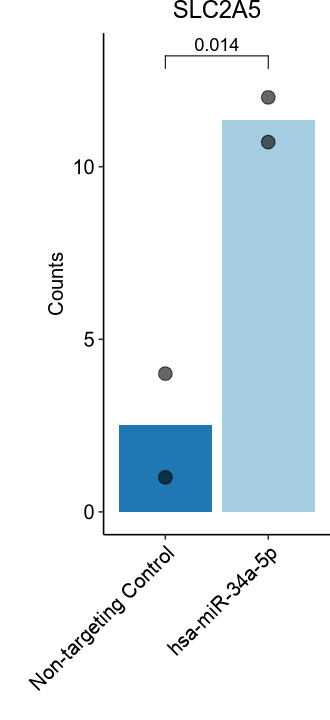

No summary function supplied, defaulting to `mean_se()`


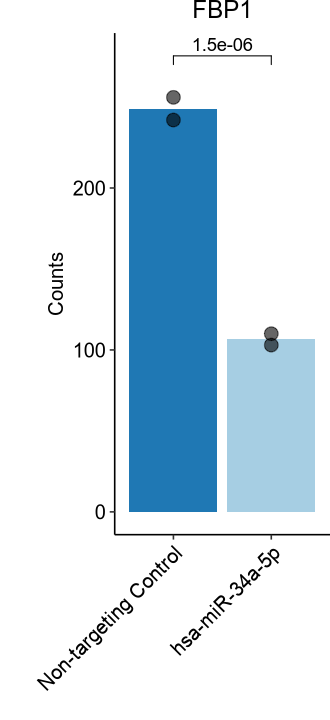

In [91]:
wfix = 2.75
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

genes = c('SLC2A5', 'FBP1')
pvals_df = readRDS(paste0(path, 'fig_output/data/fig4/miR_34_pvals_df.rds'))
select_genes_counts = readRDS(paste0(path, 'fig_output/data/fig4/miR_34_selected_genes_counts.rds'))

select_genes_counts = select_genes_counts %>% dplyr::filter(Sample %in% c('NC1', 'hsa-miR-34a-5p'))
select_genes_counts$Sample[select_genes_counts$Sample == 'NC1'] = 'Non-targeting Control'
select_genes_counts = select_genes_counts %>% dplyr::filter(SYMBOL %in% genes)
select_genes_counts$Sample = factor(select_genes_counts$Sample, levels = c('Non-targeting Control', 'hsa-miR-34a-5p'))
p.ad_SLC2A5 = pvals_df %>% dplyr::filter(symbol == 'SLC2A5') %>% arrange(factor(symbol, levels = genes)) %>% pull(padj) %>% signif(2)
p.ad_FBP1 = pvals_df %>% dplyr::filter(symbol == 'FBP1') %>% arrange(factor(symbol, levels = genes)) %>% pull(padj) %>% signif(2)

y.pos_SLC2A5 = select_genes_counts %>% dplyr::filter(SYMBOL == 'SLC2A5') %>% summarize(max = max(Counts)) %>% pull(max) * 1.1
stat.test_SLC2A5 = data.frame(.y. = 'len', group1 = 'Non-targeting Control', group2 = 'hsa-miR-34a-5p', p.adj = p.ad_SLC2A5[1], y.position = y.pos_SLC2A5)

y.pos_FBP1 = select_genes_counts %>% dplyr::filter(SYMBOL == 'FBP1') %>% summarize(max = max(Counts)) %>% pull(max) * 1.1
stat.test_FBP1 = data.frame(.y. = 'len', group1 = 'Non-targeting Control', group2 = 'hsa-miR-34a-5p', p.adj = p.ad_FBP1[1], y.position = y.pos_FBP1)

SLC2A5_barplot = select_genes_counts %>% dplyr::filter(SYMBOL == 'SLC2A5') %>% ggplot(aes(Sample, Counts)) + geom_bar(aes(fill = Sample), stat = 'summary', fun.y = 'mean', show.legend = FALSE) +
    geom_point(color = 'black', alpha = 0.6, size = 3.5, show.legend = FALSE) + theme_pubr() + stat_pvalue_manual(stat.test_SLC2A5, label = 'p.adj', step.increase = 0.1) + ggtitle(genes[1]) +
    theme(plot.margin = unit(c(0, 0, 0, 0.4), 'in'), plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('Counts') + scale_fill_brewer(palette = 'Paired', direction = -1) + scale_color_brewer(palette = 'Paired', direction = -1) + 
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
    axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size/scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

FBP1_barplot = select_genes_counts %>% dplyr::filter(SYMBOL == 'FBP1') %>% ggplot(aes(Sample, Counts)) + geom_bar(aes(fill = Sample), stat = 'summary', fun.y = 'mean', show.legend = FALSE) +
    geom_point(color = 'black', alpha = 0.6, size = 3.5, show.legend = FALSE) + theme_pubr() + stat_pvalue_manual(stat.test_FBP1, label = 'p.adj', step.increase = 0.1) + ggtitle(genes[2]) +
    theme(plot.margin = unit(c(0, 0, 0, 0.4), 'in'), plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('Counts') + scale_fill_brewer(palette = 'Paired', direction = -1) + scale_color_brewer(palette = 'Paired', direction = -1) + 
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
    axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size/scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

#ggarrange(SLC2A5_barplot, FBP1_barplot, ncol = 2, nrow = 1)
SLC2A5_barplot
ggsave(paste0(path, 'fig_output/data/fig4/miR_34_barplot_slc2a5.pdf'), width = wfix, height = hfix)
FBP1_barplot
ggsave(paste0(path, 'fig_output/data/fig4/miR_34_barplot_fbp1.pdf'), width = wfix, height = hfix)

Warning message in geom_bar(aes(fill = Sample), stat = "summary", fun.y = "mean", :
“Ignoring unknown parameters: `fun.y`”
Warning message in geom_bar(aes(fill = Sample), stat = "summary", fun.y = "mean", :
“Ignoring unknown parameters: `fun.y`”
No summary function supplied, defaulting to `mean_se()`
No summary function supplied, defaulting to `mean_se()`


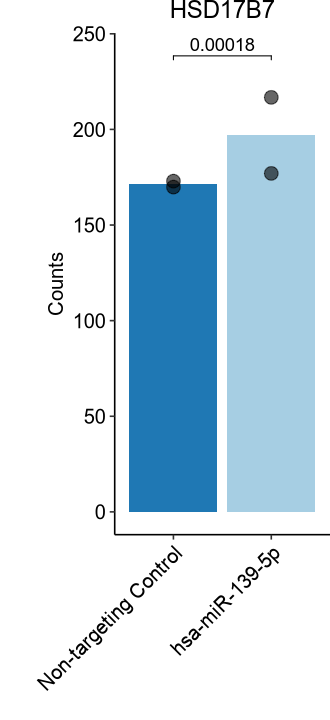

In [92]:
wfix = 2.75
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

genes = c('HSD17B7', 'PLPP6')
pvals_df = readRDS(paste0(path, 'fig_output/data/fig4/miR_139_pvals_df.rds'))
select_genes_counts = readRDS(paste0(path, 'fig_output/data/fig4/miR_139_selected_genes_counts.rds'))
select_genes_counts$Sample[select_genes_counts$Sample == 'NC1'] = 'Non-targeting Control'
select_genes_counts$Sample = factor(select_genes_counts$Sample, levels = c('Non-targeting Control', 'hsa-miR-139-5p'))
p.ad = pvals_df %>% arrange(factor(symbol, levels = genes)) %>% pull(padj) %>% signif(2)
y.pos = select_genes_counts %>% group_by(SYMBOL) %>% summarize(max = max(Counts)) %>% arrange(factor(SYMBOL, levels = genes)) %>% pull(max) * 1.1
stat.test = data.frame(.y. = 'len', group1 = rep('Non-targeting Control', length(genes)), group2 = rep('hsa-miR-139-5p', length(genes)), p.adj = p.ad, y.position = y.pos)

barplots = list()
for (i in 1:length(genes)){
barplots[[i]] = select_genes_counts %>% dplyr::filter(SYMBOL %in% genes[i]) %>% ggplot(aes(Sample, Counts)) + geom_bar(aes(fill = Sample), stat = 'summary', fun.y = 'mean', show.legend = FALSE) +
    geom_point(color = 'black', alpha = 0.6, size = 3.5, show.legend = FALSE) + theme_pubr() + stat_pvalue_manual(stat.test[i,], label = 'p.adj') + ggtitle(genes[i]) +
    theme(plot.margin = unit(c(0, 0, 0, 0.4), 'in'), plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('Counts') + scale_fill_brewer(palette = 'Paired', direction = -1) + scale_color_brewer(palette = 'Paired', direction = -1) + 
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
    axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size/scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
}

barplots[[1]]
ggsave(paste0(path, 'fig_output/data/fig4/miR_139_barplot_hsd17b7.pdf'), width = wfix, height = hfix)

Warning message in geom_bar(aes(fill = Sample), stat = "summary", fun.y = "mean", :
“Ignoring unknown parameters: `fun.y`”
Warning message in geom_bar(aes(fill = Sample), stat = "summary", fun.y = "mean", :
“Ignoring unknown parameters: `fun.y`”
No summary function supplied, defaulting to `mean_se()`
No summary function supplied, defaulting to `mean_se()`
No summary function supplied, defaulting to `mean_se()`


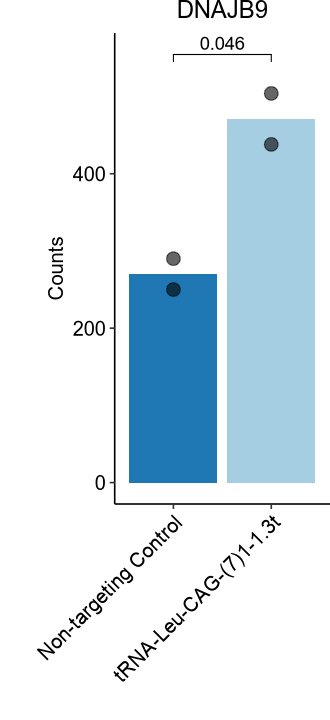

No summary function supplied, defaulting to `mean_se()`


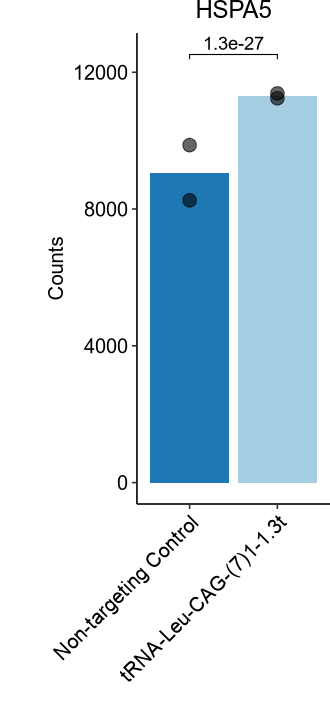

In [107]:
wfix = 2.75
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

genes = c('DNAJB9', 'HSPA5')
pvals_df = readRDS(paste0(path, 'fig_output/data/fig4/tRF_Leu_CAG_pvals_df.rds'))
select_genes_counts = readRDS(paste0(path, 'fig_output/data/fig4/tRF_Leu_CAG_selected_genes_counts.rds'))

select_genes_counts = select_genes_counts %>% dplyr::filter(Sample %in% c('NC1', 'tRNA-Leu-CAG-(7)1-1.3t'))
select_genes_counts$Sample[select_genes_counts$Sample == 'NC1'] = 'Non-targeting Control'
select_genes_counts$Sample = factor(select_genes_counts$Sample, levels = c('Non-targeting Control', 'tRNA-Leu-CAG-(7)1-1.3t'))
p.ad_DNAJB9 = pvals_df %>% dplyr::filter(symbol == 'DNAJB9') %>% arrange(factor(symbol, levels = genes)) %>% pull(padj) %>% signif(2)
p.ad_HSPA5 = pvals_df %>% dplyr::filter(symbol == 'HSPA5') %>% arrange(factor(symbol, levels = genes)) %>% pull(padj) %>% signif(2)

y.pos_DNAJB9 = select_genes_counts %>% dplyr::filter(SYMBOL == 'DNAJB9') %>% summarize(max = max(Counts)) %>% pull(max) * 1.1
stat.test_DNAJB9 = data.frame(.y. = 'len', group1 = 'Non-targeting Control', group2 = 'tRNA-Leu-CAG-(7)1-1.3t', p.adj = p.ad_DNAJB9[2], y.position = y.pos_DNAJB9)

y.pos_HSPA5 = select_genes_counts %>% dplyr::filter(SYMBOL == 'HSPA5') %>% summarize(max = max(Counts)) %>% pull(max) * 1.1
stat.test_HSPA5 = data.frame(.y. = 'len', group1 = 'Non-targeting Control', group2 = 'tRNA-Leu-CAG-(7)1-1.3t', p.adj = p.ad_HSPA5[2], y.position = y.pos_HSPA5)

DNAJB9_barplot = select_genes_counts %>% dplyr::filter(SYMBOL == 'DNAJB9') %>% ggplot(aes(Sample, Counts)) + geom_bar(aes(fill = Sample), stat = 'summary', fun.y = 'mean', show.legend = FALSE) +
    geom_point(color = 'black', alpha = 0.6, size = 3.5, show.legend = FALSE) + theme_pubr() + stat_pvalue_manual(stat.test_DNAJB9, label = 'p.adj', step.increase = 0.1) + ggtitle(genes[1]) +
    theme(plot.margin = unit(c(0, 0, 0, 0.4), 'in'), plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('Counts') + scale_fill_brewer(palette = 'Paired', direction = -1) + scale_color_brewer(palette = 'Paired', direction = -1) +  
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
    axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size/scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

HSPA5_barplot = select_genes_counts %>% dplyr::filter(SYMBOL == 'HSPA5') %>% ggplot(aes(Sample, Counts)) + geom_bar(aes(fill = Sample), stat = 'summary', fun.y = 'mean', show.legend = FALSE) +
    geom_point(color = 'black', alpha = 0.6, size = 3.5, show.legend = FALSE) + theme_pubr() + stat_pvalue_manual(stat.test_HSPA5, label = 'p.adj', step.increase = 0.1) + ggtitle(genes[2]) +
    theme(plot.margin = unit(c(0, 0, 0, 0.4), 'in'), plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('Counts') + scale_fill_brewer(palette = 'Paired', direction = -1) + scale_color_brewer(palette = 'Paired', direction = -1) + 
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
    axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size/scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))

# ggarrange(DNAJB9_barplot, HSPA5_barplot, ncol = 2, nrow = 1)

DNAJB9_barplot
ggsave(paste0(path, 'fig_output/data/fig4/tRF_Leu_CAG_barplot_dnajb9.pdf'), width = wfix, height = hfix)
HSPA5_barplot
ggsave(paste0(path, 'fig_output/data/fig4/tRF_Leu_CAG_barplot_hspa5.pdf'), width = wfix, height = hfix)


Warning message in geom_bar(aes(fill = Sample), stat = "summary", fun.y = "mean", :
“Ignoring unknown parameters: `fun.y`”
Warning message in geom_bar(aes(fill = Sample), stat = "summary", fun.y = "mean", :
“Ignoring unknown parameters: `fun.y`”
No summary function supplied, defaulting to `mean_se()`
No summary function supplied, defaulting to `mean_se()`
No summary function supplied, defaulting to `mean_se()`


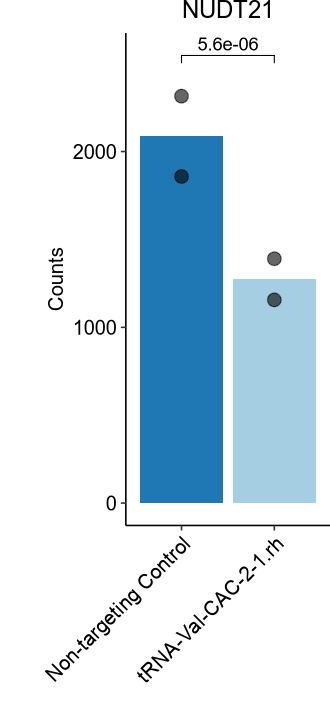

No summary function supplied, defaulting to `mean_se()`


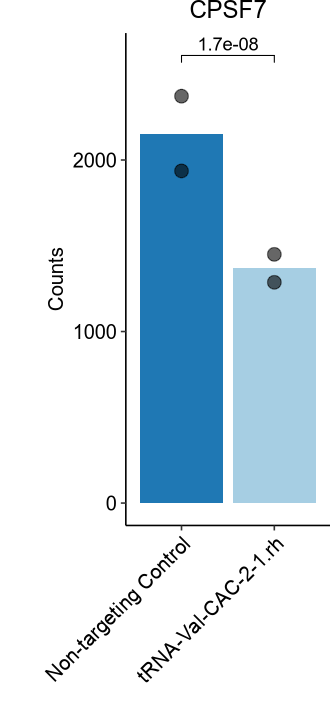

In [94]:
wfix = 2.75
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

genes = c('NUDT21', 'CPSF7')
pvals_df = readRDS(paste0(path, 'fig_output/data/fig4/tRF_Val_CAC_pvals_df.rds'))
select_genes_counts = readRDS(paste0(path, 'fig_output/data/fig4/tRF_Val_CAC_selected_genes_counts.rds'))
select_genes_counts$Sample[select_genes_counts$Sample == 'NC1'] = 'Non-targeting Control'
select_genes_counts$Sample = factor(select_genes_counts$Sample, levels = c('Non-targeting Control', 'tRNA-Val-CAC-2-1.rh'))
p.ad = pvals_df %>% arrange(factor(symbol, levels = genes)) %>% pull(padj) %>% signif(2)
y.pos = select_genes_counts %>% group_by(SYMBOL) %>% summarize(max = max(Counts)) %>% arrange(factor(SYMBOL, levels = genes)) %>% pull(max) * 1.1
stat.test = data.frame(.y. = 'len', group1 = rep('Non-targeting Control', length(genes)), group2 = rep('tRNA-Val-CAC-2-1.rh', length(genes)), p.adj = p.ad, y.position = y.pos)

barplots = list()
for (i in 1:length(genes)){
barplots[[i]] = select_genes_counts %>% dplyr::filter(SYMBOL %in% genes[i]) %>% ggplot(aes(Sample, Counts)) + geom_bar(aes(fill = Sample), stat = 'summary', fun.y = 'mean', show.legend = FALSE) +
    geom_point(color = 'black', alpha = 0.6, size = 3.5, show.legend = FALSE) + theme_pubr() + stat_pvalue_manual(stat.test[i,], label = 'p.adj') + ggtitle(genes[i]) +
    theme(plot.margin = unit(c(0, 0, 0, 0.4), 'in'), plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('Counts') + scale_fill_brewer(palette = 'Paired', direction = -1) + scale_color_brewer(palette = 'Paired', direction = -1) + 
    theme(axis.line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), line = element_line(linewidth = unit(lnwidth/scale_factor, 'pt')), axis.text.x = element_text(color = 'black', size = major_text_size*scale_factor, family = "Helvetica"),
    axis.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"), legend.text = element_text(size = minor_text_size/scale_factor, family = "Helvetica"), legend.title = element_text(size = major_text_size*scale_factor, family = "Helvetica"))
}

barplots[[1]]
ggsave(paste0(path, 'fig_output/data/fig4/tRF_Val_CAC_barplot_nudt21.pdf'), width = wfix, height = hfix)
barplots[[2]]
ggsave(paste0(path, 'fig_output/data/fig4/tRF_Val_CAC_barplot_cpsf7.pdf'), width = wfix, height = hfix)

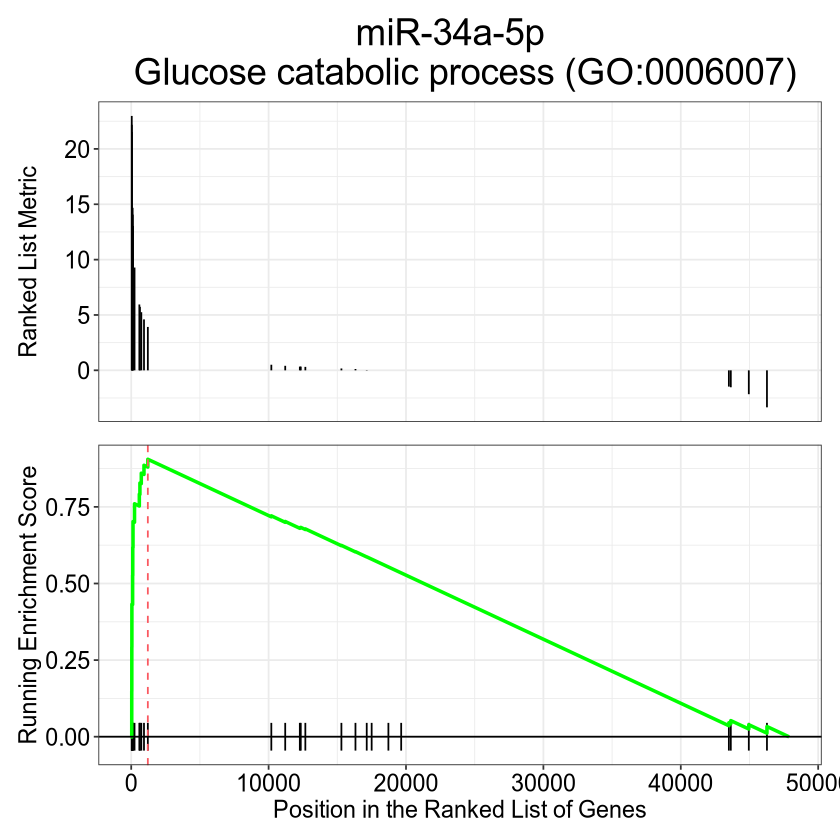

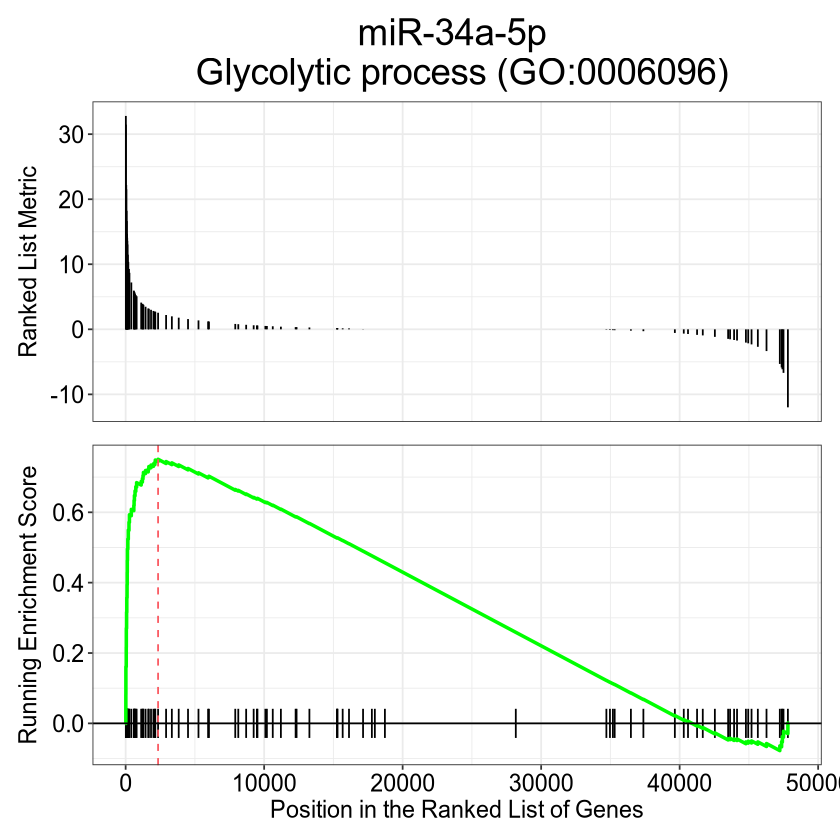

In [128]:
wfix = 7
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

gse = readRDS(paste0(path, 'fig_output/data/fig4/gse_list_miR-34-5p_449-5p.rds'))

clusterProfiler::gseaplot(gse[[1]], geneSetID = 'GO:0006007', title = 'miR-34a-5p  \n Glucose catabolic process (GO:0006007)', pvalueCutoff = 0.05, color = 'black')
## p.adjust = 0.0004190069
ggsave(paste0(path, 'fig_output/data/fig4/miR_34_gsea_1.eps'), width = wfix, height = hfix, device = 'eps')

clusterProfiler::gseaplot(gse[[1]], geneSetID = 'GO:0006096', title = 'miR-34a-5p \n Glycolytic process (GO:0006096)', pvalueCutoff = 0.05, color = 'black')
## p.adjust = 0.0005739487
ggsave(paste0(path, 'fig_output/data/fig4/miR_34_gsea_2.eps'), width = wfix, height = hfix, device = 'eps')

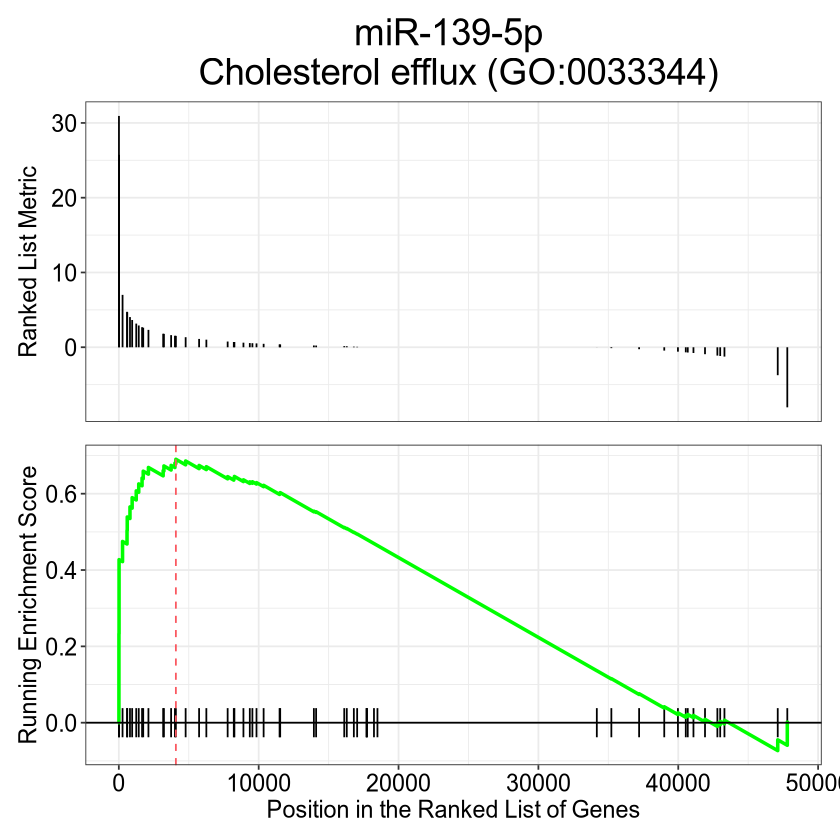

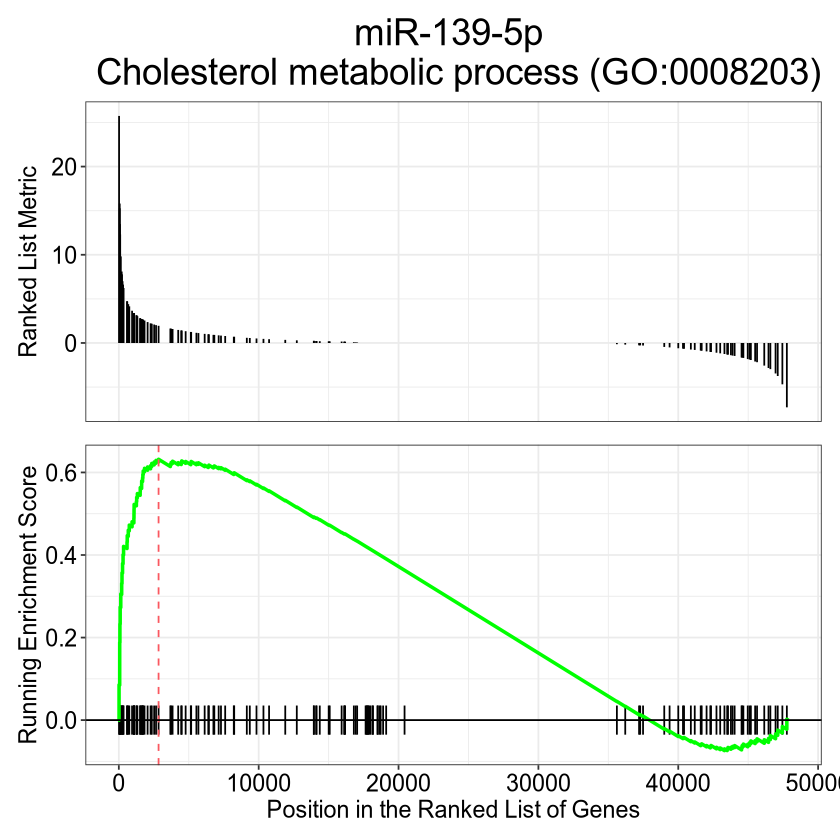

In [127]:
wfix = 7
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

gse = readRDS(paste0(path, 'fig_output/data/fig4/gse_list_miR-139-5p.rds'))


clusterProfiler::gseaplot(gse, geneSetID = 'GO:0033344', title = 'miR-139-5p \n Cholesterol efflux (GO:0033344)', pvalueCutoff = 0.05, color = 'black')
## p.adjust = 0.025422091
ggsave(paste0(path, 'fig_output/data/fig4/miR_139_gsea_1.eps'), width = wfix, height = hfix, device = 'eps')

#clusterProfiler::gseaplot(gse, geneSetID = 'GO:0032367', title = 'miR-139-5p \n Intracellular cholesterol transport (GO:0032367)', pvalueCutoff = 0.05, color = 'black')
## p.adjust = 0.018037268

clusterProfiler::gseaplot(gse, geneSetID = 'GO:0008203', title = 'miR-139-5p \n Cholesterol metabolic process (GO:0008203)', pvalueCutoff = 0.05, color = 'black')
## p.adjust = 0.005878276
ggsave(paste0(path, 'fig_output/data/fig4/miR_139_gsea_2.eps'), width = wfix, height = hfix, device = 'eps')


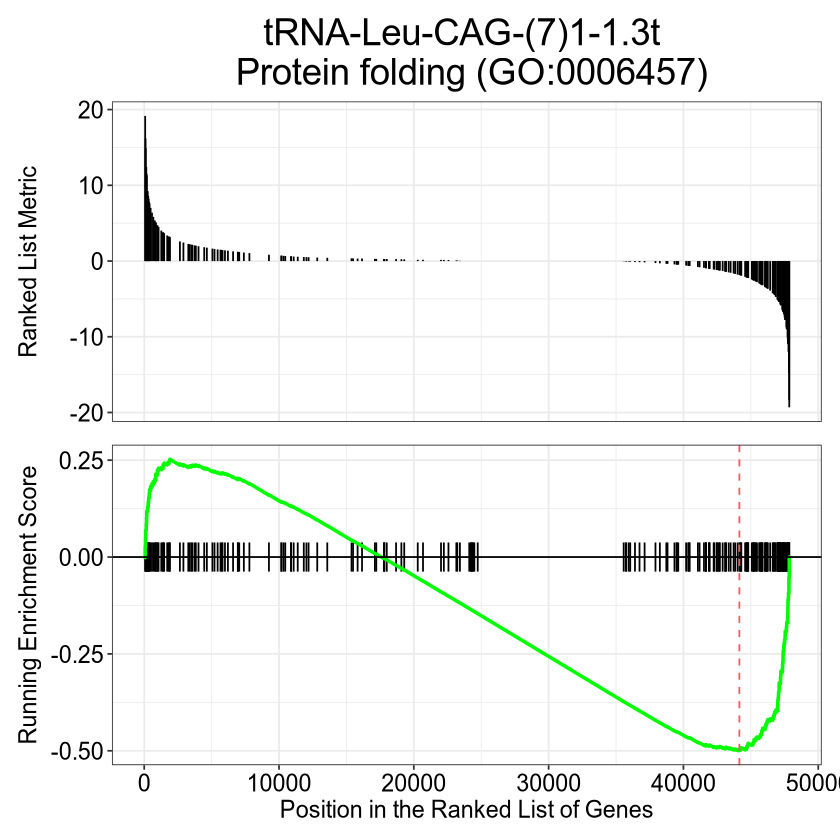

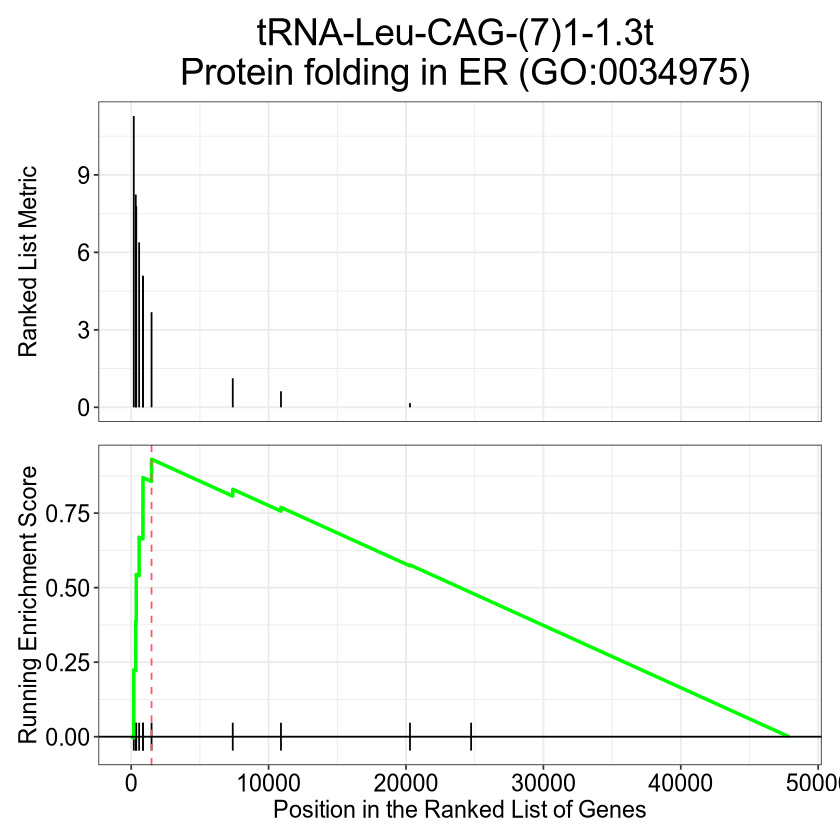

In [129]:
wfix = 7
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

gse = readRDS(paste0(path, 'fig_output/data/fig4/gse_list_tRF_Leu_CAG_2_supercluster.rds'))

#clusterProfiler::gseaplot(gse[[1]], geneSetID = 'GO:0006457', title = 'tRNA-Leu-CAG-(7)1-1.rh \n Protein folding (GO:0006457)', pvalueCutoff = 0.05, color = 'black')
## de-enriched
## p.adjust = 0.02331297

clusterProfiler::gseaplot(gse[[2]], geneSetID = 'GO:0006457', title = 'tRNA-Leu-CAG-(7)1-1.3t \n Protein folding (GO:0006457)', pvalueCutoff = 0.05, color = 'black')
## de-enriched
## p.adjust = 0.004993511
ggsave(paste0(path, 'fig_output/data/fig4/tRF_Leu_CAG_gsea_1.eps'), width = wfix, height = hfix, device = 'eps')

clusterProfiler::gseaplot(gse[[2]], geneSetID = 'GO:0034975', title = 'tRNA-Leu-CAG-(7)1-1.3t \n Protein folding in ER (GO:0034975)', pvalueCutoff = 0.05, color = 'black')
## p.adjust = 0.011117331
ggsave(paste0(path, 'fig_output/data/fig4/tRF_Leu_CAG_gsea_2.eps'), width = wfix, height = hfix, device = 'eps')

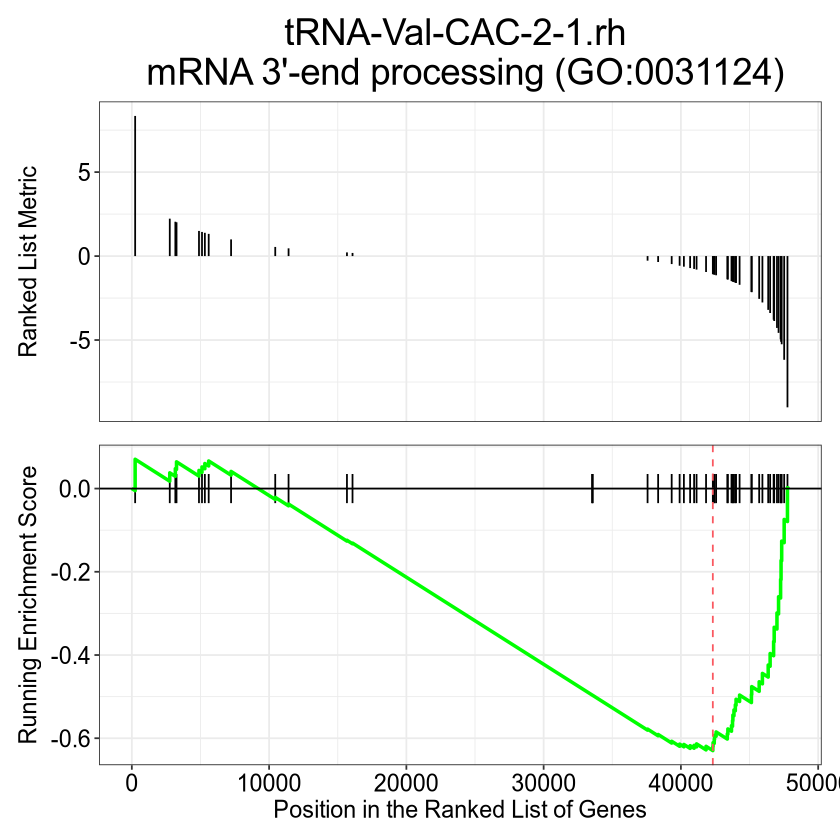

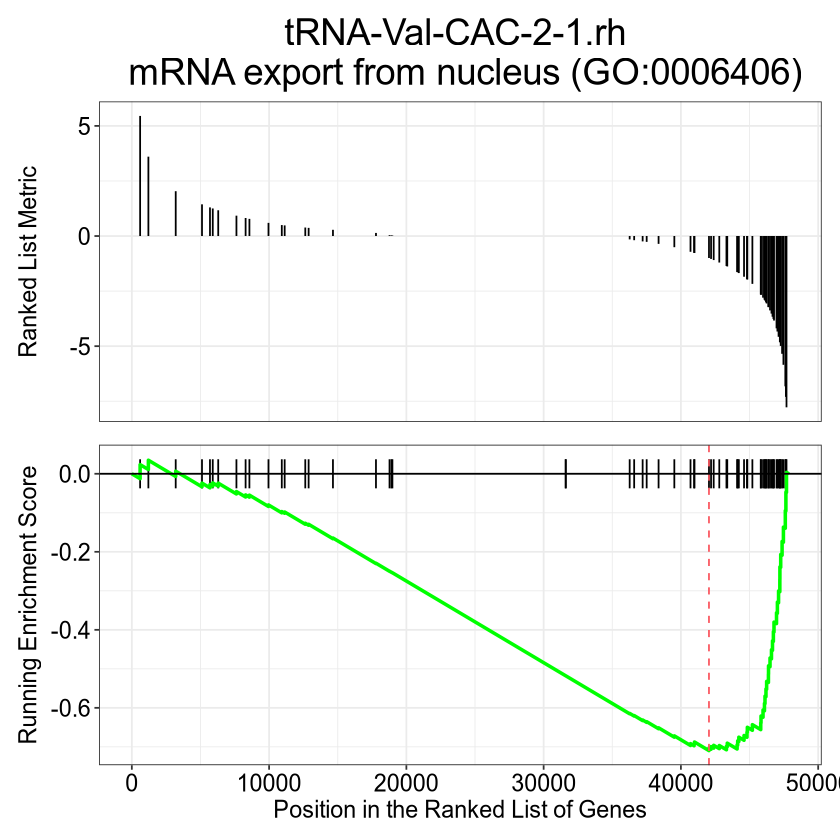

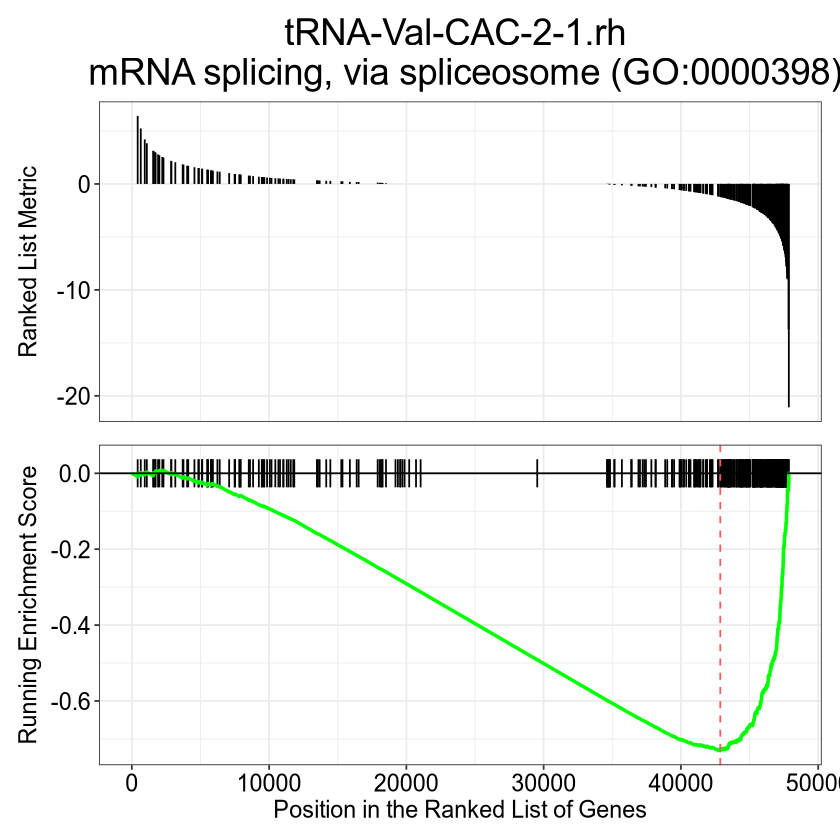

In [130]:
wfix = 7
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

gse = readRDS(paste0(path, 'fig_output/data/fig4/gse_list_tRNA-Val-CAC-2-1_rh.rds'))

clusterProfiler::gseaplot(gse, geneSetID = 'GO:0031124', title = 'tRNA-Val-CAC-2-1.rh \n mRNA 3\'-end processing (GO:0031124)', pvalueCutoff = 0.05, color = 'black')
## de-enriched
## p.adjust = 0.04161715
ggsave(paste0(path, 'fig_output/data/fig4/tRF_Val_CAC_gsea_1.eps'), width = wfix, height = hfix, device = 'eps')

clusterProfiler::gseaplot(gse, geneSetID = 'GO:0006406', title = 'tRNA-Val-CAC-2-1.rh \n mRNA export from nucleus (GO:0006406)', pvalueCutoff = 0.05, color = 'black')
## de-enriched
## p.adjust = 0.001556308
ggsave(paste0(path, 'fig_output/data/fig4/tRF_Val_CAC_gsea_2.eps'), width = wfix, height = hfix, device = 'eps')

clusterProfiler::gseaplot(gse, geneSetID = 'GO:0000398', title = 'tRNA-Val-CAC-2-1.rh \n mRNA splicing, via spliceosome (GO:0000398)', pvalueCutoff = 0.05, color = 'black')
## de-enriched
## p.adjust = 5.871925e-21
ggsave(paste0(path, 'fig_output/data/fig4/tRF_Val_CAC_gsea_3.eps'), width = wfix, height = hfix, device = 'eps')

### Single cell vs bulk expression correlation ###

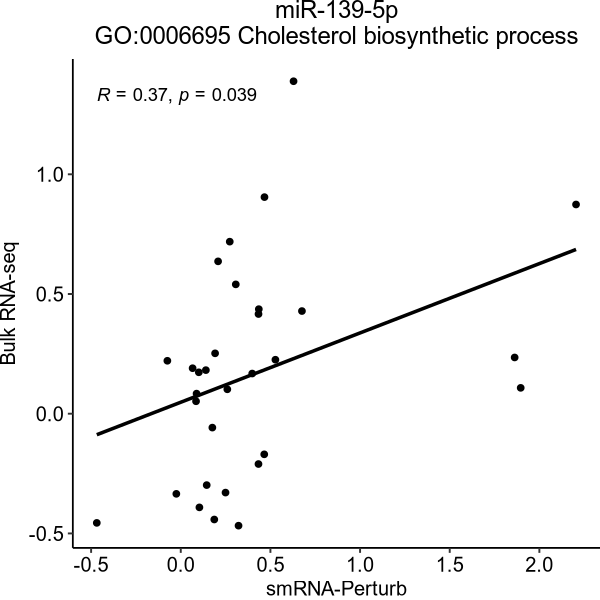

In [21]:
wfix = 5
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

miR_fold_change_dfs = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig4/miR_fold_change_dfs_sc_bulk_comparisons.rds')
ggplot(data = miR_fold_change_dfs[[1]], aes(x = sc_log2FC, y = bulk_log2FC)) +
    geom_smooth(method = "lm", formula = y ~ x, se = F, color = 'black') + geom_point() + xlab('smRNA-Perturb') + ylab('Bulk RNA-seq') +
    stat_cor(aes(), method = "pearson") + theme_pubr() + #geom_text_repel(aes(label = gene), segment.color = 'grey50') + 
    ggtitle('miR-139-5p\nGO:0006695 Cholesterol biosynthetic process') + #ylim(-0.32, 0.32) + xlim(-0.32, 0.32) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

#ggplot(data = miR_fold_change_dfs[[1]], aes(x = sc_log2FC, y = bulk_log2FC)) +
    #geom_smooth(method = "lm", formula = y ~ x, se = T, color = 'black') + geom_point() + xlab('smRNA-Perturb') + ylab('Bulk RNA-seq') +
    #stat_cor(aes(), method = "pearson") + theme_pubr() + #geom_text_repel(aes(label = gene), segment.color = 'grey50') + 
    #ggtitle('miR-139-5p\nGO:0006695 Cholesterol biosynthetic process') + #ylim(-0.32, 0.32) + xlim(-0.32, 0.32) +
    #theme(plot.title = element_text(hjust = 0.5)) +
    #theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig4/miR_sc_bulk_FC_comparison_cholesterol.pdf'), width = wfix, height = hfix)

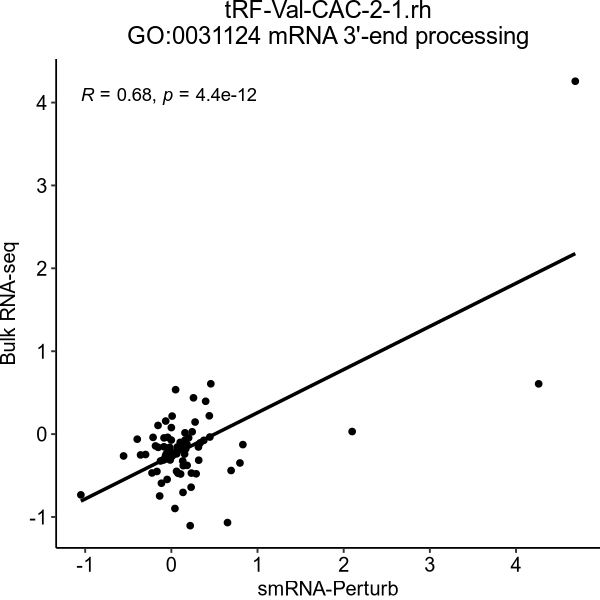

In [22]:
wfix = 5
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

tRF_fold_change_dfs = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig4/tRF_fold_change_dfs_sc_bulk_comparisons.rds')
ggplot(data = tRF_fold_change_dfs[[4]], aes(x = sc_log2FC, y = bulk_log2FC)) +
    geom_smooth(method = "lm", formula = y ~ x, se = F, color = 'black') + geom_point() + xlab('smRNA-Perturb') + ylab('Bulk RNA-seq') +
    stat_cor(aes(), method = "pearson") + theme_pubr() + #geom_text_repel(aes(label = gene), segment.color = 'grey50') + 
    ggtitle('tRF-Val-CAC-2-1.rh\nGO:0031124 mRNA 3\'-end processing') + #ylim(-0.32, 0.32) + xlim(-0.32, 0.32) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

#ggplot(data = tRF_fold_change_dfs[[4]], aes(x = sc_log2FC, y = bulk_log2FC)) +
    #geom_smooth(method = "lm", formula = y ~ x, se = T, color = 'black') + geom_point() + xlab('smRNA-Perturb') + ylab('Bulk RNA-seq') +
    #stat_cor(aes(), method = "pearson") + theme_pubr() + #geom_text_repel(aes(label = gene), segment.color = 'grey50') + 
    #ggtitle('GO:0031124 mRNA 3\'-end processing\ntRF-Val-CAC-2-1.rh') + #ylim(-0.32, 0.32) + xlim(-0.32, 0.32) +
    #theme(plot.title = element_text(hjust = 0.5)) +
    #theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig4/tRF_sc_bulk_FC_mrna_processing.pdf'), width = wfix, height = hfix)

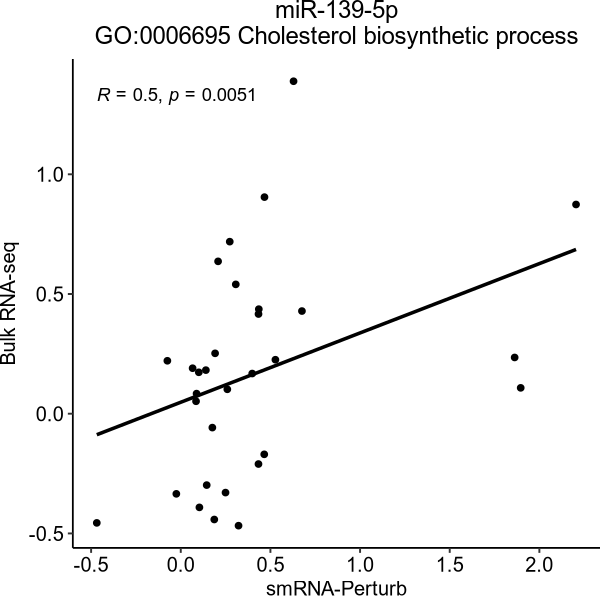

In [4]:
wfix = 5
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

miR_fold_change_dfs = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig4/miR_fold_change_dfs_sc_bulk_comparisons.rds')
ggplot(data = miR_fold_change_dfs[[1]], aes(x = sc_log2FC, y = bulk_log2FC)) +
    geom_smooth(method = "lm", formula = y ~ x, se = F, color = 'black') + geom_point() + xlab('smRNA-Perturb') + ylab('Bulk RNA-seq') +
    stat_cor(aes(), method = "spearman") + theme_pubr() + #geom_text_repel(aes(label = gene), segment.color = 'grey50') + 
    ggtitle('miR-139-5p\nGO:0006695 Cholesterol biosynthetic process') + #ylim(-0.32, 0.32) + xlim(-0.32, 0.32) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

#ggplot(data = miR_fold_change_dfs[[1]], aes(x = sc_log2FC, y = bulk_log2FC)) +
    #geom_smooth(method = "lm", formula = y ~ x, se = T, color = 'black') + geom_point() + xlab('smRNA-Perturb') + ylab('Bulk RNA-seq') +
    #stat_cor(aes(), method = "pearson") + theme_pubr() + #geom_text_repel(aes(label = gene), segment.color = 'grey50') + 
    #ggtitle('miR-139-5p\nGO:0006695 Cholesterol biosynthetic process') + #ylim(-0.32, 0.32) + xlim(-0.32, 0.32) +
    #theme(plot.title = element_text(hjust = 0.5)) +
    #theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

#ggsave(paste0(path, 'fig_output/data/fig4/miR_sc_bulk_FC_comparison_cholesterol.pdf'), width = wfix, height = hfix)

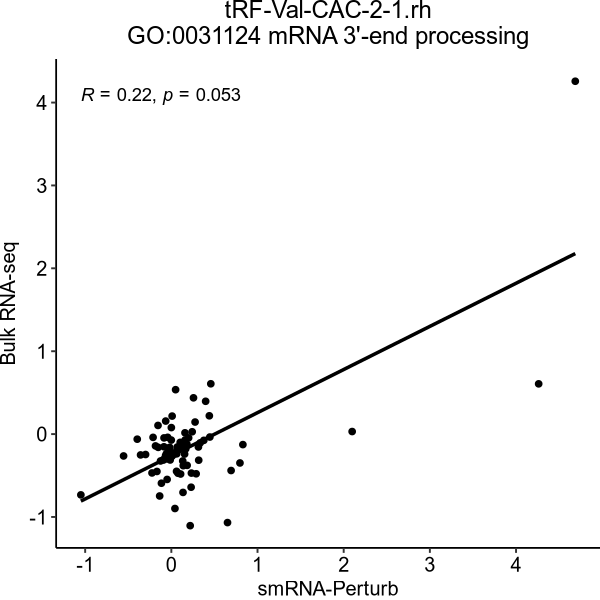

In [5]:
wfix = 5
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 3.94
scale_factor = hfix/3.94 ## always divide height by height -- much less likely to change to make figure look better

tRF_fold_change_dfs = readRDS('/home/ssobti/projects/mir_tud/fig_output/data/fig4/tRF_fold_change_dfs_sc_bulk_comparisons.rds')
ggplot(data = tRF_fold_change_dfs[[4]], aes(x = sc_log2FC, y = bulk_log2FC)) +
    geom_smooth(method = "lm", formula = y ~ x, se = F, color = 'black') + geom_point() + xlab('smRNA-Perturb') + ylab('Bulk RNA-seq') +
    stat_cor(aes(), method = "spearman") + theme_pubr() + #geom_text_repel(aes(label = gene), segment.color = 'grey50') + 
    ggtitle('tRF-Val-CAC-2-1.rh\nGO:0031124 mRNA 3\'-end processing') + #ylim(-0.32, 0.32) + xlim(-0.32, 0.32) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

#ggplot(data = tRF_fold_change_dfs[[4]], aes(x = sc_log2FC, y = bulk_log2FC)) +
    #geom_smooth(method = "lm", formula = y ~ x, se = T, color = 'black') + geom_point() + xlab('smRNA-Perturb') + ylab('Bulk RNA-seq') +
    #stat_cor(aes(), method = "pearson") + theme_pubr() + #geom_text_repel(aes(label = gene), segment.color = 'grey50') + 
    #ggtitle('GO:0031124 mRNA 3\'-end processing\ntRF-Val-CAC-2-1.rh') + #ylim(-0.32, 0.32) + xlim(-0.32, 0.32) +
    #theme(plot.title = element_text(hjust = 0.5)) +
    #theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

#ggsave(paste0(path, 'fig_output/data/fig4/tRF_sc_bulk_FC_mrna_processing.pdf'), width = wfix, height = hfix)